# مشروع بيان الرئيسي — جميع اللابات في ملف واحد
# Bayan Master Project — All Labs in One Colab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lolo67fa/bayan-nlp-ghalaalshreef-sdaia/blob/main/notebooks/Bayan_All_Labs_Master.ipynb)

**المتدربة:** غالا الشريف — Ghala Alshreef  
**المستودع:** https://github.com/lolo67fa/bayan-nlp-ghalaalshreef-sdaia  
**تاريخ التجميع:** 2026-08-31

هذا هو الملف الرئيسي للمشروع. يجمع اللابات `00` إلى `08` كاملةً بالترتيب، ويحافظ على كود المتدربة ونتائج التشغيل المحفوظة، ويضيف جسرًا بين كل مرحلتين يوضح المدخلات والمخرجات. في النهاية يوجد Capstone يربط المراحل في Pipeline واحد.

> **مهم:** لا تحذفي دفاتر اللابات المنفصلة من الريبو؛ تبقى أدلة مستقلة، بينما هذا الملف هو العرض الشامل للمشروع.


## طريقة الاستخدام في Google Colab

1. افتحي الملف من زر **Open in Colab** بعد رفعه إلى GitHub.
2. لتشغيل نسخة قابلة لإعادة الإنتاج بدون ملفات خاصة، اتركي `MASTER_PROJECT_MODE=False`.
3. لتشغيل نموذج المشروع الحقيقي في Lab 8، اربطي Google Drive وضعي المسارات في خلية الإعداد التالية ثم غيّري القيمة إلى `True`.
4. اختاري **Runtime → Run all**. بعض الخلايا تنزّل نماذج ومكتبات وقد تستغرق وقتًا.
5. ظهور علامات `DAY...=PASS` ثم `BAYAN_CAPSTONE_PIPELINE=PASS` هو دليل اكتمال التشغيل.

### كيف ترتبط اللابات؟

```text
Runtime → Preprocessing/Tokenisation → Attention → Classification + NER + QA
        → Arabic NLP → Semantic Search → Evaluation → Optimisation/Serving → Capstone
```


## لوحة حالة المشروع وقت إنشاء الملف

| Lab | الموضوع | حالة النسخة الموجودة في الريبو | الدليل/الملاحظة |
|---:|---|---|---|
| 00 | Runtime Doctor | ✅ 5/5 خلايا منفذة | `BAYAN_ENV_READY` |
| 01 | Text Processing & Tokenisation | ✅ 11/11 خلايا منفذة | `DAY1_NOTEBOOK1_CORE=PASS`؛ استُعيدت شروحات النسخة الأصلية في هذا الملف |
| 02 | Attention & Transformers | ✅ 12/12 خلايا منفذة | `DAY1_NOTEBOOK2_CORE=PASS`؛ أضيفت شروحات عربية وحُذفت خلية V المكررة من النسخة الموحّدة |
| 03 | Text Classification | ✅ 11/11 خلايا منفذة | `DAY2_NOTEBOOK3_CORE=PASS` |
| 04 | NER & Extractive QA | ✅ 17/17 خلايا منفذة | `DAY2_NOTEBOOK4_CORE=PASS` |
| 05 | Arabic NLP | ✅ 11/11 خلايا منفذة | `DAY3_NOTEBOOK5_CORE=PASS` |
| 06 | Semantic Search | ✅ 13/13 خلايا منفذة | `DAY3_NOTEBOOK6_CORE=PASS` |
| 07 | Evaluation & Error Analysis | ✅ 11/11 خلايا منفذة | `DAY3_NOTEBOOK7_CORE=PASS` |
| 08 | Optimisation & Serving | ✅ 18/18 خلايا منفذة | `DAY4_NOTEBOOK8_CORE=PASS`؛ إعادة PROJECT_ARTIFACT تحتاج ملفات Drive |

### ما لم يكتمل بعد خارج اللابات

- 🟨 ملف `bayan_capstone.ipynb` الموجود في الريبو لم يكن منفذًا؛ أُدرج كاملًا في نهاية هذا الملف ليُشغّل بعد اللابات.
- 🟨 Gate D وGate E ما زالا `NOT_STARTED` بحسب `PROGRESS.md` وقت التجميع.
- 🟨 ملفات التسليم في جذر الريبو ما زال فيها حقول `FILL_ME/TODO`، خصوصًا `README.md` و`MODEL_CARD.md` و`DATA_CARD.md` و`BENCHMARKS.md` و`STUDENT_PROFILE.md`.
- ⚠️ تشغيل Lab 8 بوضع `PROJECT_ARTIFACT` يحتاج نموذجًا وTokenizer وملف validation في Google Drive. الوضع الافتراضي هنا `SYSTEMS_SMOKE` حتى يظل الملف قابلًا للتشغيل.


In [1]:
# إعداد الملف الرئيسي — عدّلي فقط إذا أردتِ تشغيل نموذج المشروع الحقيقي في Lab 8
MASTER_PROJECT_MODE = False
MASTER_PROJECT_MODEL_SOURCE = "/content/drive/MyDrive/bayan/model-v1"
MASTER_PROJECT_TOKENIZER_SOURCE = "/content/drive/MyDrive/bayan/model-v1"
MASTER_PROJECT_VALIDATION_CSV = "/content/drive/MyDrive/bayan/validation.csv"

MASTER_RUN_STATUS = {}
print("Master mode:", "PROJECT_ARTIFACT" if MASTER_PROJECT_MODE else "SYSTEMS_SMOKE")


Master mode: SYSTEMS_SMOKE


---

# التهيئة — Runtime Doctor

**المصدر داخل الريبو:** [`notebooks/00_runtime_doctor.ipynb`](https://github.com/lolo67fa/bayan-nlp-ghalaalshreef-sdaia/blob/main/notebooks/00_runtime_doctor.ipynb)

| الربط | التفاصيل |
|---|---|
| المدخل من المرحلة السابقة | جلسة Google Colab جديدة |
| ناتج هذا اللاب | إصدارات مثبتة، فحص الجهاز، و`BAYAN_ENV_READY` |
| استخدام الناتج لاحقًا | تستخدم جميع اللابات البيئة التي تم التحقق منها |
| علامة النجاح | `BAYAN_ENV_READY` |

> الخلايا التالية من نسخة المتدربة في GitHub، مع الحفاظ على نتائج التشغيل المحفوظة. أي إضافات خاصة بالملف الرئيسي موضحة صراحة.


# فاحص بيئة بيان | Bayan Runtime Doctor

**إعداد وتقديم | Prepared and delivered by:** ميعاد المري · Meaad Al-Marri  
**المسار | Lane:** 🟢 Core · **الوقت | Time:** 10–15 minutes

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/almiyead-rgb/bayan-applied-nlp-course/blob/main/notebooks/00_runtime_doctor.ipynb)

شغّل الخلايا من الأعلى إلى الأسفل. نجاح CPU كافٍ؛ GPU ليس شرطًا.  
Run the cells top to bottom. CPU success is sufficient; a GPU is not required.


## ماذا سيفحص؟ | What it checks

- إصدار Python ونظام التشغيل.
- توفر المكتبات الأساسية الموجودة عادةً في Colab.
- سلامة UTF-8 والنص العربي.
- الجهاز الفعلي: CPU أو CUDA GPU.
- الذاكرة والمساحة المتاحة تقريبًا.
- الوصول إلى المواقع المطلوبة، بوصفه تحذيرًا لا شرط نجاح.
- إنشاء `runtime_report.json` بلا أسرار أو بيانات شخصية.


In [2]:
from __future__ import annotations

import importlib.util
import json
import os
import platform
import shutil
import sys
from datetime import datetime, timezone
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path

COURSE = "Bayan Applied NLP"
AUTHOR = "Meaad Al-Marri"

def package_version(name: str) -> str:
    try:
        return version(name)
    except PackageNotFoundError:
        return "not-installed"

def gib(value: int) -> float:
    return round(value / (1024 ** 3), 2)

try:
    in_colab = importlib.util.find_spec("google.colab") is not None
except ModuleNotFoundError:
    in_colab = False
torch_version = package_version("torch")
cuda_available = False
gpu_name = None

if torch_version != "not-installed":
    import torch
    cuda_available = bool(torch.cuda.is_available())
    if cuda_available:
        gpu_name = torch.cuda.get_device_name(0)

disk = shutil.disk_usage("/")
report = {
    "course": COURSE,
    "author": AUTHOR,
    "checked_at_utc": datetime.now(timezone.utc).isoformat(),
    "in_colab": in_colab,
    "python": platform.python_version(),
    "platform": platform.platform(),
    "device": "cuda" if cuda_available else "cpu",
    "gpu_name": gpu_name,
    "disk_free_gib": gib(disk.free),
    "packages": {
        "numpy": package_version("numpy"),
        "pandas": package_version("pandas"),
        "scikit-learn": package_version("scikit-learn"),
        "torch": torch_version,
    },
}

print(json.dumps(report, ensure_ascii=False, indent=2))


{
  "course": "Bayan Applied NLP",
  "author": "Meaad Al-Marri",
  "checked_at_utc": "2026-08-31T10:18:34.139153+00:00",
  "in_colab": true,
  "python": "3.13.15",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "device": "cuda",
  "gpu_name": "Tesla T4",
  "disk_free_gib": 64.85,
  "packages": {
    "numpy": "2.1.3",
    "pandas": "2.2.3",
    "scikit-learn": "1.9.0",
    "torch": "2.11.0+cu128"
  }
}


In [3]:
# Core checks: these determine readiness. Network and GPU do not.
arabic_sample = "مرحبًا بكم في مشروع بيان"
core_checks = {
    "python_3_10_or_newer": sys.version_info >= (3, 10),
    "utf8_round_trip": arabic_sample.encode("utf-8").decode("utf-8") == arabic_sample,
    "numpy_available": report["packages"]["numpy"] != "not-installed",
    "pandas_available": report["packages"]["pandas"] != "not-installed",
    "sklearn_available": report["packages"]["scikit-learn"] != "not-installed",
    "torch_available": report["packages"]["torch"] != "not-installed",
    "disk_has_1_gib_free": report["disk_free_gib"] >= 1.0,
}

for name, passed in core_checks.items():
    print(("✅" if passed else "❌"), name)

BAYAN_ENV_READY = all(core_checks.values())
print("\nBAYAN_ENV_READY =", BAYAN_ENV_READY)
if not BAYAN_ENV_READY:
    raise RuntimeError("Environment check failed. Copy the failed check names and use the setup troubleshooting guide.")


✅ python_3_10_or_newer
✅ utf8_round_trip
✅ numpy_available
✅ pandas_available
✅ sklearn_available
✅ torch_available
✅ disk_has_1_gib_free

BAYAN_ENV_READY = True


In [4]:
# Connectivity checks are warnings because classroom networks may filter sites.
# Test the exact services used by the notebooks, not only their home pages.
import requests

sites = {
    "github_raw": "https://raw.githubusercontent.com/almiyead-rgb/bayan-applied-nlp-course/main/README.md",
    "pypi": "https://pypi.org/simple/",
    "huggingface_models": "https://huggingface.co/api/models/google-bert/bert-base-multilingual-cased",
}
connectivity = {}
for name, url in sites.items():
    try:
        response = requests.get(
            url, headers={"User-Agent": "Bayan-Course-Runtime-Doctor/1.1"},
            timeout=15, stream=True,
        )
        connectivity[name] = 200 <= response.status_code < 400
        response.close()
    except requests.RequestException as exc:
        connectivity[name] = False
        print(f"⚠️ {name}: {type(exc).__name__}")

report["connectivity"] = connectivity
for name, passed in connectivity.items():
    print(("✅" if passed else "⚠️"), name)

print("\nA connectivity warning does not change BAYAN_ENV_READY.")


✅ github_raw
✅ pypi
✅ huggingface_models

A connectivity warning does not change BAYAN_ENV_READY.


In [5]:
# Save a small, safe report. It contains no password, token, email, or Drive path.
report["core_checks"] = core_checks
report["bayan_env_ready"] = BAYAN_ENV_READY
report_path = Path("runtime_report.json")
report_path.write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")
print("Saved:", report_path.name)
print("Size:", report_path.stat().st_size, "bytes")


Saved: runtime_report.json
Size: 776 bytes


## اختياري: Google Drive | Optional

لا تشغّل الخلية التالية إلا بعد قراءة صلاحية الوصول. تركيب Drive يسمح للكود بالوصول إلى ملفات Drive. لا تمنح الصلاحية لدفتر غير موثوق.


In [6]:
MOUNT_DRIVE = False  # Change to True only when you choose to mount Drive.

if MOUNT_DRIVE:
    if not in_colab:
        raise RuntimeError("Drive mounting is available in Google Colab, not this runtime.")
    from google.colab import drive
    drive.mount("/content/drive")
    recovery_dir = Path("/content/drive/MyDrive/bayan-nlp/recovery")
    recovery_dir.mkdir(parents=True, exist_ok=True)
    shutil.copy2(report_path, recovery_dir / report_path.name)
    print("Copied report to:", recovery_dir)
else:
    print("Drive not mounted. This is normal for the first readiness check.")


Drive not mounted. This is normal for the first readiness check.


## النتيجة التالية | Next step

إذا ظهر `BAYAN_ENV_READY = True`:

1. احفظ نسخة notebook في Drive.
2. احتفظ بملف `runtime_report.json`.
3. أكمل [إعداد GitHub](../docs/setup/github.md).
4. لا تقلق إن كان الجهاز CPU؛ هذا يحقق شرط الجاهزية.

If readiness is false, copy the failed check names and open the [troubleshooting guide](../docs/setup/troubleshooting.md).


In [7]:
MASTER_RUN_STATUS["00"] = True
print("MASTER_LAB_00=PASS")


MASTER_LAB_00=PASS


---

# اليوم الأول — Lab 1 — Text Processing & Tokenisation

**المصدر داخل الريبو:** [`notebooks/01_text_processing_tokenization.ipynb`](https://github.com/lolo67fa/bayan-nlp-ghalaalshreef-sdaia/blob/main/notebooks/01_text_processing_tokenization.ipynb)

| الربط | التفاصيل |
|---|---|
| المدخل من المرحلة السابقة | النص العربي والإنجليزي الخام |
| ناتج هذا اللاب | نسختا العرض/النموذج، إخفاء PII، Tokens، fertility وtruncation |
| استخدام الناتج لاحقًا | يمر النص المرمّز وAttention Mask إلى Lab 2 |
| علامة النجاح | `DAY1_NOTEBOOK1_CORE=PASS` |

> الخلايا التالية من نسخة المتدربة في GitHub، مع الحفاظ على نتائج التشغيل المحفوظة. أي إضافات خاصة بالملف الرئيسي موضحة صراحة.


# اليوم الأول — معالجة النصوص والترميز
## Day 1 — Text Processing & Tokenisation

**المدربة / Instructor:** ميعاد المري — Meaad Al-Marri  
**المسار / Track:** Core → Explore → Distinction

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/almiyead-rgb/bayan-applied-nlp-course/blob/main/notebooks/01_text_processing_tokenization.ipynb)

> السؤال المحوري: كيف يتحول نص عربي أو إنجليزي إلى تمثيل عددي صالح للنموذج دون إفساد معناه؟
>
> Driving question: How does Arabic or English text become a model-ready numeric representation without damaging its meaning?

**بنهاية المختبر ستتمكن من / By the end, you can:**

1. فحص Unicode بدل التخمين — inspect Unicode rather than guess.
2. بناء نسختين: نص خام محفوظ ونص مهيأ للنموذج — keep raw and model-ready copies.
3. قياس **خصوبة الترميز Token Fertility** ومعدل القطع — measure fertility and truncation.
4. تحويل Token IDs إلى Embeddings بسيطة — map token IDs to simple embeddings.
5. حفظ دليل إنجاز قابل للتسليم عبر GitHub — save GitHub-ready evidence.

## 0) طريقة العمل / How to work

- نفّذ الخلايا بالترتيب: **Runtime → Core → Checkpoint**.
- نتيجة كل خلية موضحة بجملة تبدأ بـ **المتوقع / Expected**.
- إذا تعذر تنزيل نموذج Hugging Face، أكمل بالمرمّز المحلي؛ فهو جزء أساسي يعمل دون شبكة بعد تثبيت الحزم.
- لا تستخدم بيانات حقيقية أو أسماء أو أرقام أشخاص. البيانات أدناه اصطناعية.

**المتوقع / Expected:** في النهاية تظهر العبارة `DAY1_NOTEBOOK1_CORE=PASS`.

In [8]:
# إعداد بيئة قابلة لإعادة التشغيل / Reproducible setup
import importlib.util
import subprocess
import sys

PINNED = {"transformers": "5.15.1", "tokenizers": "0.22.2", "spacy": "3.8.7"}
missing = [name for name in PINNED if importlib.util.find_spec(name) is None]
if missing:
    packages = [f"{name}=={PINNED[name]}" for name in missing]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])

print("Python:", sys.version.split()[0])
print("Environment ready / البيئة جاهزة")

Python: 3.13.15
Environment ready / البيئة جاهزة


### لماذا نثبت نسخًا محددة؟ / Why pin versions?

لتقليل اختلاف النتائج بين أجهزة المتدربين. التثبيت مجاني ولا يحتاج اشتراكًا؛ يحتاج اتصالًا بالإنترنت أول مرة فقط. Google Colab المجاني يكفي لهذا اليوم، ولا يضمن GPU أو مدة جلسة ثابتة.

**المتوقع / Expected:** إصدار Python ثم رسالة نجاح البيئة.

In [9]:
import html
import re
import unicodedata
from dataclasses import dataclass
from typing import Iterable

import numpy as np
from tokenizers import Tokenizer
from tokenizers.models import WordPiece
from tokenizers.pre_tokenizers import BertPreTokenizer
from tokenizers.processors import TemplateProcessing

SEED = 42
rng = np.random.default_rng(SEED)
samples = [
    "أهلاً وسهلاً بكم في برنامج بيان!",
    "مرحبــاً\u00a0بكم",
    "Contact us at learner@example.org",
    "للتجربة فقط: 0551234567",
    "Natural language processing connects text and models.",
]
print("Synthetic samples:", len(samples))

Synthetic samples: 5


## 1) Unicode قبل التنظيف / Unicode before cleaning

الحرف الظاهر قد يتكون من نقطة ترميز واحدة أو أكثر. لا تخلط بين:

- **Unicode code point:** رقم معياري للحرف.
- **UTF-8:** تحويل نقاط الترميز إلى bytes للتخزين والنقل.
- **Token ID:** رقم داخل قاموس مرمّز محدد، وليس رقم Unicode.

نستخدم **NFC** لتوحيد التمثيلات المتكافئة غالبًا، لكن لا نحول العربية بقوة من دون سبب متعلق بالمهمة.

In [10]:
def inspect_unicode(text: str) -> list[dict[str, str]]:
    return [
        {"char": ch, "code_point": f"U+{ord(ch):04X}", "name": unicodedata.name(ch, "UNKNOWN")}
        for ch in text
    ]

unicode_rows = inspect_unicode("أé")
for row in unicode_rows:
    print(row)
assert unicode_rows[0]["code_point"] == "U+0623"
print("Unicode inspection=PASS")

{'char': 'أ', 'code_point': 'U+0623', 'name': 'ARABIC LETTER ALEF WITH HAMZA ABOVE'}
{'char': 'é', 'code_point': 'U+00E9', 'name': 'LATIN SMALL LETTER E WITH ACUTE'}
Unicode inspection=PASS


**المتوقع / Expected:** صف لكل حرف يحوي الشكل و`U+....` والاسم، ثم رسالة نجاح.

### قرار عربي محافظ / Conservative Arabic decision

ابدأ بأقل تعديل ممكن. إزالة التشكيل أو توحيد الألف قد يفيد البحث أو التصنيف، لكنه قد يضر مهامًا تعتمد الشكل الأصلي. لذلك نسجل الإعدادات ولا نطبقها بصمت.

In [11]:
ARABIC_DIACRITICS = re.compile(r"[\u0610-\u061A\u064B-\u065F\u0670\u06D6-\u06ED]")
TATWEEL = "\u0640"
WHITESPACE = re.compile(r"\s+")
HTML_TAG = re.compile(r"<[^>]+>")
EMAIL = re.compile(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b")
SAUDI_MOBILE = re.compile(r"(?<!\d)(?:\+?966|00966|0)?5\d{8}(?!\d)")

@dataclass(frozen=True)
class TextRecord:
    raw_text: str
    model_text: str


def mask_pii(text: str) -> str:
    return SAUDI_MOBILE.sub("<PHONE>", EMAIL.sub("<EMAIL>", text))


def prepare_text(text: str, *, remove_diacritics: bool = False, normalize_alef: bool = False) -> TextRecord:
    if not isinstance(text, str):
        raise TypeError("text must be a string")
    raw = text
    model = unicodedata.normalize("NFC", html.unescape(text))
    model = HTML_TAG.sub(" ", model).replace(TATWEEL, "")
    if remove_diacritics:
        model = ARABIC_DIACRITICS.sub("", model)
    if normalize_alef:
        model = re.sub(r"[إأآٱ]", "ا", model)
    model = WHITESPACE.sub(" ", mask_pii(model)).strip()
    return TextRecord(raw_text=raw, model_text=model)

records = [prepare_text(text) for text in samples]
for record in records:
    print({"raw": record.raw_text, "model": record.model_text})
assert records[1].raw_text != records[1].model_text
assert "learner@example.org" not in records[2].model_text
assert "0551234567" not in records[3].model_text
assert records[2].raw_text == samples[2]
print("Two-copy preprocessing contract=PASS")

{'raw': 'أهلاً وسهلاً بكم في برنامج بيان!', 'model': 'أهلاً وسهلاً بكم في برنامج بيان!'}
{'raw': 'مرحبــاً\xa0بكم', 'model': 'مرحباً بكم'}
{'raw': 'Contact us at learner@example.org', 'model': 'Contact us at <EMAIL>'}
{'raw': 'للتجربة فقط: 0551234567', 'model': 'للتجربة فقط: <PHONE>'}
{'raw': 'Natural language processing connects text and models.', 'model': 'Natural language processing connects text and models.'}
Two-copy preprocessing contract=PASS


**المتوقع / Expected:** تبقى `raw` كما دخلت، بينما تحذف الكشيدة وتوحد المسافات وتستبدل البريد والهاتف بعلامات عامة.

> **قاعدة البيانات:** النسخة الخام للتدقيق وإعادة المعالجة، والنسخة المهيأة لدخول النموذج. لا تُنشر النسخة الخام إن احتوت بيانات شخصية.

### جرّب / Try

غيّر `remove_diacritics` و`normalize_alef` على مثال اصطناعي، ثم اكتب هل التغيير يخدم مهمتك أم يخفي فرقًا مهمًا.

## 2) spaCy كمرحلة قابلة للاختبار / A testable spaCy stage

التقسيم إلى جمل لا يُنفذ بـ`split('.')`. نمرر **نسخة النموذج المحمية** إلى spaCy، ونوثق قيدًا معروفًا: الاختصارات مثل `د.` تحتاج استثناءً أو segmenter مدربًا قبل الإنتاج. هذا المثال يستخدم `sentencizer` القاعدي بلا تنزيل نموذج لغوي.

In [12]:
import spacy

sentence_nlp = spacy.blank("xx")
sentence_nlp.add_pipe("sentencizer")

def split_model_sentences(text: str) -> list[str]:
    protected = prepare_text(text).model_text
    return [sentence.text.strip() for sentence in sentence_nlp(protected).sents if sentence.text.strip()]

sentence_examples = {
    "ar": "الخدمة جيدة. لم يصل الرمز!",
    "en": "The portal stopped. Please retry.",
}
sentence_splits = {language: split_model_sentences(text) for language, text in sentence_examples.items()}
for language, sentences in sentence_splits.items():
    print(language, sentences)

abbreviation_probe = split_model_sentences("راجع د. أحمد. ثم أعد المحاولة.")
print("Known abbreviation probe / حالة تحتاج قاعدة إضافية:", abbreviation_probe)
assert sentence_splits["ar"] == ["الخدمة جيدة.", "لم يصل الرمز!"]
assert sentence_splits["en"] == ["The portal stopped.", "Please retry."]
print("SPACY_SENTENCE_PIPELINE=PASS")

ar ['الخدمة جيدة.', 'لم يصل الرمز!']
en ['The portal stopped.', 'Please retry.']
Known abbreviation probe / حالة تحتاج قاعدة إضافية: ['راجع د.', 'أحمد.', 'ثم أعد المحاولة.']
SPACY_SENTENCE_PIPELINE=PASS


## 2) الترميز إلى كلمات فرعية / Subword tokenisation

المرمّز المحلي التالي **تعليمي ومحدود**: يوضح الرموز الخاصة و`[UNK]` وToken IDs دون تنزيل نموذج. ليس بديلًا عن مرمّز النموذج النهائي. في Explore سنقارن اختياريًا مع mBERT.

In [13]:
special_tokens = ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]
known_tokens = [
    "أهلاً", "وسهلاً", "بكم", "في", "برنامج", "بيان", "!", "مرحبا",
    "Contact", "us", "at", "<", "EMAIL", ">", "Natural", "language",
    "processing", "connects", "text", "and", "models", ".",
]
vocab_tokens = special_tokens + known_tokens
vocab = {token: idx for idx, token in enumerate(vocab_tokens)}
local_tokenizer = Tokenizer(WordPiece(vocab=vocab, unk_token="[UNK]"))
local_tokenizer.pre_tokenizer = BertPreTokenizer()
local_tokenizer.post_processor = TemplateProcessing(
    single="[CLS] $A [SEP]",
    special_tokens=[("[CLS]", vocab["[CLS]"]), ("[SEP]", vocab["[SEP]"])],
)
for record in records:
    encoded = local_tokenizer.encode(record.model_text)
    print(record.model_text)
    print("tokens:", encoded.tokens)
    print("ids:   ", encoded.ids)
assert local_tokenizer.encode("مرحبا بكم").tokens == ["[CLS]", "مرحبا", "بكم", "[SEP]"]
print("Local WordPiece demonstration=PASS")

أهلاً وسهلاً بكم في برنامج بيان!
tokens: ['[CLS]', 'أهلاً', 'وسهلاً', 'بكم', 'في', 'برنامج', 'بيان', '!', '[SEP]']
ids:    [2, 5, 6, 7, 8, 9, 10, 11, 3]
مرحباً بكم
tokens: ['[CLS]', '[UNK]', 'بكم', '[SEP]']
ids:    [2, 1, 7, 3]
Contact us at <EMAIL>
tokens: ['[CLS]', 'Contact', 'us', 'at', '<', 'EMAIL', '>', '[SEP]']
ids:    [2, 13, 14, 15, 16, 17, 18, 3]
للتجربة فقط: <PHONE>
tokens: ['[CLS]', '[UNK]', '[UNK]', '[UNK]', '<', '[UNK]', '>', '[SEP]']
ids:    [2, 1, 1, 1, 16, 1, 18, 3]
Natural language processing connects text and models.
tokens: ['[CLS]', 'Natural', 'language', 'processing', 'connects', 'text', 'and', 'models', '.', '[SEP]']
ids:    [2, 19, 20, 21, 22, 23, 24, 25, 26, 3]
Local WordPiece demonstration=PASS


**المتوقع / Expected:** Tokens وIDs لكل نص. ظهور `[UNK]` يعني أن قاموس هذا المرمّز التعليمي لا يعرف الجزء؛ لا يعني أن النص خاطئ.

### مقياسان قبل اختيار المرمّز / Two pre-selection metrics

\[
\text{Token Fertility}=\frac{\text{عدد الرموز الفرعية}}{\text{عدد الكلمات التقريبية}}
\]

\[
\text{Truncation Rate}=\frac{\text{النصوص التي تتجاوز الحد}}{\text{كل النصوص}}
\]

خصوبة أعلى تعني عادة تسلسلاً أطول وكلفة أكبر، لكنها ليست وحدها حكمًا على جودة النموذج.

In [14]:
def word_count(text: str) -> int:
    return max(1, len(text.split()))


def token_fertility(tokenizer: Tokenizer, text: str) -> float:
    tokens = tokenizer.encode(text).tokens
    content = [t for t in tokens if t not in {"[CLS]", "[SEP]", "[PAD]"}]
    return len(content) / word_count(text)


def truncation_rate(tokenizer: Tokenizer, texts: Iterable[str], max_length: int) -> float:
    texts = list(texts)
    if not texts:
        raise ValueError("texts must not be empty")
    return sum(len(tokenizer.encode(t).ids) > max_length for t in texts) / len(texts)

model_texts = [record.model_text for record in records]
fertilities = [token_fertility(local_tokenizer, text) for text in model_texts]
rate_at_10 = truncation_rate(local_tokenizer, model_texts, max_length=10)
print("fertility per sample:", [round(x, 2) for x in fertilities])
print("mean fertility:", round(float(np.mean(fertilities)), 2))
print("truncation rate @10:", f"{rate_at_10:.0%}")
assert all(x > 0 for x in fertilities)
assert 0.0 <= rate_at_10 <= 1.0
print("Tokenisation metrics=PASS")

fertility per sample: [1.17, 1.0, 1.5, 2.0, 1.14]
mean fertility: 1.36
truncation rate @10: 0%
Tokenisation metrics=PASS


### قياس إضافي محفوظ من عمل المتدربة

تعيد الخلية التالية القياس بعد تعطيل Padding وTruncation حتى لا تدخل الرموز المضافة في حساب fertility.


In [15]:
local_tokenizer.no_truncation()
local_tokenizer.no_padding()

ar_texts = [model_texts[i] for i in (0, 1, 3)]
en_texts = [model_texts[i] for i in (2, 4)]

ar_fert = float(np.mean([token_fertility(local_tokenizer, t) for t in ar_texts]))
en_fert = float(np.mean([token_fertility(local_tokenizer, t) for t in en_texts]))

print(f"Arabic mean fertility [MEASURED]: {ar_fert:.2f}")
print(f"English mean fertility [MEASURED]: {en_fert:.2f}")

for L in (8, 10, 16):
    r = truncation_rate(local_tokenizer, model_texts, L)
    print(f"truncation rate @{L} [MEASURED]: {r:.0%}")

print("Per-language metrics=PASS")

Arabic mean fertility [MEASURED]: 1.39
English mean fertility [MEASURED]: 1.32
truncation rate @8 [MEASURED]: 40%
truncation rate @10 [MEASURED]: 0%
truncation rate @16 [MEASURED]: 0%
Per-language metrics=PASS


## 3) Padding وTruncation ثم Embeddings

- **Padding:** إضافة `[PAD]` لتوحيد طول الدفعة؛ قناع الانتباه يضع 0 عند الحشو.
- **Truncation:** قص النص عند حد؛ قد يحذف المعلومة الحاسمة.
- **Token ID:** فهرس صحيح.
- **Embedding:** متجه أعداد حقيقية يُتعلم أثناء التدريب.

المتجهات التالية عشوائية للشرح فقط وليست تضمينات لغوية مدربة.

In [16]:
MAX_LENGTH = 12
local_tokenizer.enable_truncation(max_length=MAX_LENGTH)
local_tokenizer.enable_padding(length=MAX_LENGTH, pad_id=vocab["[PAD]"], pad_token="[PAD]")
batch = [local_tokenizer.encode(text) for text in model_texts[:2]]
input_ids = np.array([item.ids for item in batch], dtype=np.int64)
attention_mask = np.array([item.attention_mask for item in batch], dtype=np.int64)
embedding_table = rng.normal(0.0, 0.02, size=(len(vocab), 8))
embeddings = embedding_table[input_ids]
print("input_ids shape:", input_ids.shape)
print("attention_mask shape:", attention_mask.shape)
print("embeddings shape:", embeddings.shape)
print("first attention mask:", attention_mask[0].tolist())
assert input_ids.shape == (2, MAX_LENGTH)
assert attention_mask.shape == input_ids.shape
assert embeddings.shape == (2, MAX_LENGTH, 8)
print("IDs-to-embeddings pipeline=PASS")

input_ids shape: (2, 12)
attention_mask shape: (2, 12)
embeddings shape: (2, 12, 8)
first attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0]
IDs-to-embeddings pipeline=PASS


**المتوقع / Expected:** الأشكال `(2, 12)` و`(2, 12, 8)` ثم رسالة نجاح. الحشو لا يحمل معنى؛ قناع الانتباه يمنع النموذج من معاملته كنص.

## Explore — مقارنة اختيارية مع mBERT

هذه الخلية تحاول تنزيل مرمّز `google-bert/bert-base-multilingual-cased` من Hugging Face. الاستخدام مجاني، لكن التنزيل يحتاج شبكة وقد يتعذر مؤقتًا. فشلها **لا يمنع اجتياز Core**.

In [17]:
try:
    from transformers import AutoTokenizer
    hf_tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-multilingual-cased", use_fast=True)
    comparison_text = "معالجة اللغة الطبيعية مفيدة Natural language processing is useful"
    hf_tokens = hf_tokenizer.tokenize(comparison_text)
    print("mBERT tokens:", hf_tokens)
    print("mBERT token count:", len(hf_tokens))
    print("Fast tokenizer:", hf_tokenizer.is_fast)
except Exception as exc:
    print("Optional mBERT download unavailable; continue with Core.")
    print("Reason:", type(exc).__name__)

mBERT tokens: ['مع', '##الجة', 'اللغة', 'الطبيعية', 'م', '##فيد', '##ة', 'Natural', 'language', 'processing', 'is', 'useful']
mBERT token count: 12
Fast tokenizer: True


## 4) قرار موثق / Documented decision

| البند / Criterion | ملاحظتي / My evidence |
|---|---|
| Profile المطبق |  |
| مثال قبل/بعد |  |
| متوسط Token Fertility |  |
| Truncation Rate والحد |  |
| خطر محتمل على العربية |  |
| قراري والسبب |  |

### مستويات التحدي

- **Core:** شغّل Core واشرح مثالًا قبل/بعد.
- **Explore:** قارن المحلي مع mBERT على 5 جمل اصطناعية.
- **Distinction:** قارن مرمزين مناسبين وناقش الخصوبة والقطع والزمن دون اعتبار مقياس واحد إثباتًا للأفضلية.

In [18]:
core_checks = {
    "unicode": unicode_rows[0]["code_point"] == "U+0623",
    "spacy_sentence_pipeline": all(len(value) == 2 for value in sentence_splits.values()),
    "raw_copy_preserved": records[2].raw_text == samples[2],
    "pii_masked": "<EMAIL>" in records[2].model_text and "<PHONE>" in records[3].model_text,
    "token_metrics": all(x > 0 for x in fertilities) and 0 <= rate_at_10 <= 1,
    "embedding_shape": embeddings.shape == (2, MAX_LENGTH, 8),
}
for name, passed in core_checks.items():
    print(f"{name}: {'PASS' if passed else 'FAIL'}")
assert all(core_checks.values())
print("DAY1_NOTEBOOK1_CORE=PASS")

unicode: PASS
spacy_sentence_pipeline: PASS
raw_copy_preserved: PASS
pii_masked: PASS
token_metrics: PASS
embedding_shape: PASS
DAY1_NOTEBOOK1_CORE=PASS


## نقطة GitHub / GitHub checkpoint

1. من Colab: **File → Save a copy in GitHub**.
2. احفظ النسخة في مستودعك العام داخل `notebooks/`.
3. Commit: `feat(day1): complete preprocessing and tokenisation lab`.
4. أضف في `README.md`: Profile، الخصوبة، معدل القطع، وقرارك.
5. لا تحفظ مفاتيح أو بيانات حقيقية أو مخرجات تكشف معلومات شخصية.

**دليل الاكتمال:** `DAY1_NOTEBOOK1_CORE=PASS` + رابط Commit عام + جدول القرار.

In [19]:
MASTER_RUN_STATUS["01"] = True
print("MASTER_LAB_01=PASS")


MASTER_LAB_01=PASS


---

# اليوم الأول — Lab 2 — Attention & Transformers

**المصدر داخل الريبو:** [`notebooks/02_attention_transformers.ipynb`](https://github.com/lolo67fa/bayan-nlp-ghalaalshreef-sdaia/blob/main/notebooks/02_attention_transformers.ipynb)

| الربط | التفاصيل |
|---|---|
| المدخل من المرحلة السابقة | Tokens وAttention Mask من Lab 1 |
| ناتج هذا اللاب | Scaled Attention، Multi-Head shapes وتمثيلات سياقية |
| استخدام الناتج لاحقًا | تغذي التمثيلات رؤوس التصنيف وNER وQA |
| علامة النجاح | `DAY1_NOTEBOOK2_CORE=PASS` |

> الخلايا التالية من نسخة المتدربة في GitHub، مع الحفاظ على نتائج التشغيل المحفوظة. أي إضافات خاصة بالملف الرئيسي موضحة صراحة.


In [20]:
import importlib.metadata
import subprocess
import sys
import math
import numpy as np

PINNED = {"transformers": "5.15.1", "tokenizers": "0.22.2"}
to_install = []
for distribution, expected in PINNED.items():
    try:
        current = importlib.metadata.version(distribution)
    except importlib.metadata.PackageNotFoundError:
        current = None
    if current != expected:
        to_install.append(f"{distribution}=={expected}")
if to_install:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *to_install])

SEED = 42
rng = np.random.default_rng(SEED)
print("NumPy:", np.__version__)
print("Pinned:", {name: importlib.metadata.version(name) for name in PINNED})
print("Core runtime ready / بيئة Core جاهزة")

NumPy: 2.1.3
Pinned: {'transformers': '5.15.1', 'tokenizers': '0.22.2'}
Core runtime ready / بيئة Core جاهزة


### شرح الخلية

تجهز هذه الخلية بيئة العمل عن طريق استيراد المكتبات المطلوبة والتأكد من تثبيت الإصدارات المحددة من Transformers وTokenizers. كما تستخدم Seed ثابتًا حتى تكون النتائج قابلة للتكرار. ظهور رسالة Core runtime ready يعني أن البيئة أصبحت جاهزة لتشغيل اللاب.

In [21]:
def softmax(x: np.ndarray, axis: int = -1) -> np.ndarray:
    shifted = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(shifted)
    return exp_x / exp_x.sum(axis=axis, keepdims=True)


def scaled_dot_product_attention(
    q: np.ndarray,
    k: np.ndarray,
    v: np.ndarray,
    keep_mask: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    if q.shape[-1] != k.shape[-1]:
        raise ValueError("Q and K must share d_k")
    if k.shape[-2] != v.shape[-2]:
        raise ValueError("K and V must share sequence length")
    scores = q @ np.swapaxes(k, -1, -2) / math.sqrt(q.shape[-1])
    if keep_mask is not None:
        mask = np.asarray(keep_mask, dtype=bool)
        try:
            mask = np.broadcast_to(mask, scores.shape)
        except ValueError as exc:
            raise ValueError("keep_mask is not broadcastable to scores") from exc
        if np.any(mask.sum(axis=-1) == 0):
            raise ValueError("Every query row must keep at least one key")
        scores = np.where(mask, scores, -np.inf)
    weights = softmax(scores, axis=-1)
    output = weights @ v
    return output, weights, scores

q = np.array([[1.0, 0.0], [0.0, 1.0]])
k = np.array([[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]])
v = np.array([[10.0, 0.0], [0.0, 10.0], [5.0, 5.0]])
output, weights, scores = scaled_dot_product_attention(q, k, v)
print("scores shape:", scores.shape)
print("weights:\n", np.round(weights, 3))
print("row sums:", weights.sum(axis=-1))
print("output:\n", np.round(output, 3))
assert output.shape == (2, 2)
assert np.allclose(weights.sum(axis=-1), 1.0)
print("Scaled attention=PASS")

scores shape: (2, 3)
weights:
 [[0.401 0.198 0.401]
 [0.198 0.401 0.401]]
row sums: [1. 1.]
output:
 [[6.017 3.983]
 [3.983 6.017]]
Scaled attention=PASS



تطبق هذه الخلية Scaled Dot-Product Attention.
تتم مقارنة Q مع K للحصول على Scores، ثم تقسيمها على الجذر التربيعي لبعد Q، وتحويلها إلى أوزان باستخدام Softmax. بعد ذلك تُستخدم الأوزان لدمج قيم V وإنتاج Output. مجموع أوزان كل صف يساوي 1، وظهور PASS يعني أن التطبيق صحيح.

In [22]:
def entropy(probabilities: np.ndarray) -> float:
    p = np.clip(probabilities, 1e-12, 1.0)
    return float(-np.sum(p * np.log(p), axis=-1).mean())

q_big = rng.normal(size=(6, 64))
k_big = rng.normal(size=(6, 64))
raw_scores = q_big @ k_big.T
unscaled_weights = softmax(raw_scores)
scaled_weights = softmax(raw_scores / math.sqrt(q_big.shape[-1]))
print("mean entropy without scaling:", round(entropy(unscaled_weights), 3))
print("mean entropy with scaling:   ", round(entropy(scaled_weights), 3))
print("Scaling comparison complete")

mean entropy without scaling: 0.379
mean entropy with scaling:    1.624
Scaling comparison complete


### شرح الخلية


تقارن هذه الخلية أوزان Attention قبل وبعد تقسيم Scores على √dₖ. بدون Scaling تصبح الأوزان حادة جدًا، بينما يساعد Scaling على جعلها أكثر توازنًا واستقرارًا. ارتفاع قيمة Entropy بعد Scaling يوضح أن الأوزان أصبحت موزعة بصورة أفضل.

In [23]:
causal_keep_mask = np.tril(np.ones((2, 3), dtype=bool))
masked_output, masked_weights, _ = scaled_dot_product_attention(q, k, v, keep_mask=causal_keep_mask)
print("keep mask:\n", causal_keep_mask.astype(int))
print("masked weights:\n", np.round(masked_weights, 3))
assert masked_weights[0, 1] == 0.0
assert masked_weights[0, 2] == 0.0
print("Mask semantics=PASS")

keep mask:
 [[1 0 0]
 [1 1 0]]
masked weights:
 [[1.   0.   0.  ]
 [0.33 0.67 0.  ]]
Mask semantics=PASS


### شرح الخلية

تطبق هذه الخلية Causal Mask لمنع كل موضع من رؤية المواضع المستقبلية. القيمة True تعني أن الموضع مسموح له بالمشاركة، والقيمة False تعني أنه محجوب. لذلك أصبحت أوزان المواضع المحجوبة تساوي صفرًا، وظهور PASS يؤكد أن القناع يعمل بشكل صحيح.


In [24]:
def split_heads(x: np.ndarray, num_heads: int) -> np.ndarray:
    batch, seq_len, d_model = x.shape
    if d_model % num_heads != 0:
        raise ValueError("d_model must be divisible by num_heads")
    d_head = d_model // num_heads
    return x.reshape(batch, seq_len, num_heads, d_head).transpose(0, 2, 1, 3)


def combine_heads(x: np.ndarray) -> np.ndarray:
    batch, num_heads, seq_len, d_head = x.shape
    return x.transpose(0, 2, 1, 3).reshape(batch, seq_len, num_heads * d_head)

x = rng.normal(size=(2, 5, 12))
heads = split_heads(x, num_heads=3)
combined = combine_heads(heads)
print("input:", x.shape)
print("split:", heads.shape, "= (batch, heads, tokens, d_head)")
print("combined:", combined.shape)
assert heads.shape == (2, 3, 5, 4)
assert np.allclose(combined, x)
print("Multi-head shape journey=PASS")

input: (2, 5, 12)
split: (2, 3, 5, 4) = (batch, heads, tokens, d_head)
combined: (2, 5, 12)
Multi-head shape journey=PASS


### شرح الخلية

تقسم هذه الخلية التمثيل إلى ثلاثة Attention Heads. تغير الشكل من (2, 5, 12) إلى (2, 3, 5, 4)، حيث يمثل الرقم 3 عدد الرؤوس والرقم 4 حجم كل رأس. بعد ذلك تُدمج الرؤوس ويعود التمثيل إلى شكله الأصلي (2, 5, 12).


In [25]:
try:
    import torch
    torch.manual_seed(SEED)
    layer = torch.nn.TransformerEncoderLayer(
        d_model=12, nhead=3, dim_feedforward=24,
        dropout=0.0, batch_first=True, norm_first=False,
    )
    layer.eval()
    torch_x = torch.tensor(x, dtype=torch.float32)
    with torch.no_grad():
        encoder_output = layer(torch_x)
    print("PyTorch encoder output:", tuple(encoder_output.shape))
    assert tuple(encoder_output.shape) == (2, 5, 12)
    print("Optional encoder layer=PASS")
except ModuleNotFoundError:
    print("PyTorch is optional here; NumPy Core remains complete.")

PyTorch encoder output: (2, 5, 12)
Optional encoder layer=PASS


### شرح الخلية

تنشئ هذه الخلية طبقة Transformer Encoder باستخدام PyTorch، وتتكون من Multi-Head Attention وFeed-Forward Network وعمليات Normalization. تم تمرير البيانات عبر الطبقة وبقي شكل الناتج (2, 5, 12)، مما يؤكد أن الطبقة تعمل بشكل صحيح.


In [26]:
try:
    import torch
    import torch.nn.functional as F
    tq = torch.tensor(q, dtype=torch.float64)[None, None, :, :]
    tk = torch.tensor(k, dtype=torch.float64)[None, None, :, :]
    tv = torch.tensor(v, dtype=torch.float64)[None, None, :, :]
    torch_result = F.scaled_dot_product_attention(tq, tk, tv, dropout_p=0.0)
    np_result = output[None, None, :, :]
    max_difference = float(np.max(np.abs(torch_result.numpy() - np_result)))
    print("max NumPy/PyTorch difference:", f"{max_difference:.3e}")
    assert max_difference < 1e-9
    print("NumPy/PyTorch parity=PASS")
except ModuleNotFoundError:
    print("PyTorch unavailable; parity check skipped without affecting Core.")

max NumPy/PyTorch difference: 4.441e-16
NumPy/PyTorch parity=PASS


### شرح الخلية

تقارن هذه الخلية تنفيذ Attention باستخدام NumPy مع الدالة الرسمية في PyTorch. كان الفرق بين النتيجتين قريبًا جدًا من الصفر، وهذا يعني أن تنفيذ NumPy أعطى تقريبًا النتيجة نفسها التي أعطتها PyTorch.


In [27]:
from transformers import AutoConfig

AUDIT_CHECKPOINTS = [
    "google-bert/bert-base-multilingual-cased",
    "CAMeL-Lab/bert-base-arabic-camelbert-da",
]
EXPECTED_TOTALS = {
    "google-bert/bert-base-multilingual-cased": 177_853_440,
    "CAMeL-Lab/bert-base-arabic-camelbert-da": 109_081_344,
}

def bert_parameter_audit(model_id: str) -> dict:
    config = AutoConfig.from_pretrained(model_id)
    assert config.model_type == "bert"
    hidden = config.hidden_size
    intermediate = config.intermediate_size
    embeddings = (
        config.vocab_size * hidden
        + config.max_position_embeddings * hidden
        + config.type_vocab_size * hidden
        + 2 * hidden
    )
    per_layer = (
        3 * (hidden * hidden + hidden)
        + (hidden * hidden + hidden) + 2 * hidden
        + (hidden * intermediate + intermediate)
        + (intermediate * hidden + hidden) + 2 * hidden
    )
    pooler = hidden * hidden + hidden
    total = embeddings + config.num_hidden_layers * per_layer + pooler
    return {
        "model_id": model_id, "vocab_size": config.vocab_size,
        "total_parameters": total,
        "embedding_share": embeddings / total,
    }

parameter_audits = [bert_parameter_audit(model_id) for model_id in AUDIT_CHECKPOINTS]
for item in parameter_audits:
    print(
        f'{item["model_id"]} | vocab={item["vocab_size"]:,} | '
        f'total={item["total_parameters"]:,} | '
        f'embeddings={item["embedding_share"]:.1%}'
    )
assert all(item["total_parameters"] == EXPECTED_TOTALS[item["model_id"]] for item in parameter_audits)
print("TWO_CHECKPOINT_PARAMETER_AUDIT=PASS")

google-bert/bert-base-multilingual-cased | vocab=119,547 | total=177,853,440 | embeddings=51.8%
CAMeL-Lab/bert-base-arabic-camelbert-da | vocab=30,000 | total=109,081,344 | embeddings=21.5%
TWO_CHECKPOINT_PARAMETER_AUDIT=PASS


### شرح الخلية

تقارن هذه الخلية عدد المعاملات في mBERT وCAMeLBERT. يمتلك mBERT قاموسًا أكبر لأنه يدعم لغات متعددة، ولذلك يحتوي على عدد أكبر من المعاملات ونسبة أكبر في طبقة Embeddings. لكن عدد المعاملات وحده لا يثبت أن نموذجًا أفضل من الآخر؛ لأن الجودة تعتمد أيضًا على البيانات والمهمة.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Model: distilbert/distilbert-base-multilingual-cased
Parameters: 134,734,080
Hidden-state shape: (2, 10, 768)
Attention tensor [batch, heads, query, key]: (2, 12, 10, 10)
Arabic tokens: ['[CLS]', 'ال', '##خدمة', 'لم', 'ت', '##ت', '##أ', '##خر', '.', '[SEP]']
Row-sum range: 0.9999998807907104 1.0000001192092896


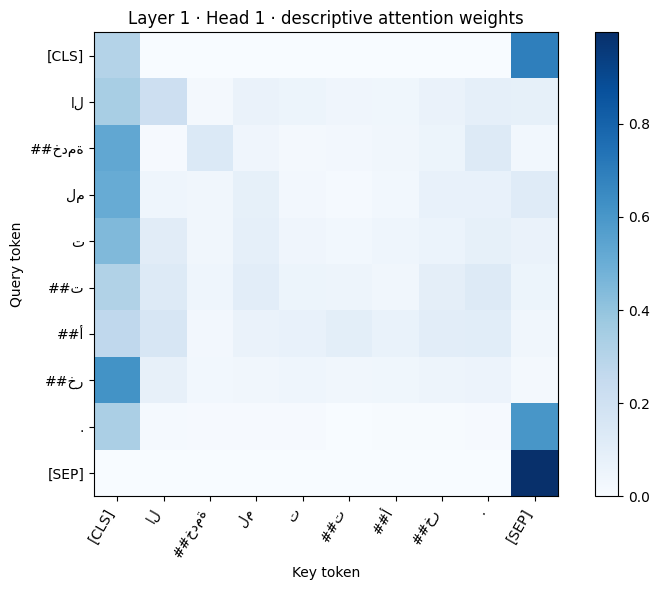

ACTUAL_TRANSFORMER_FORWARD=PASS


In [28]:
import torch
import matplotlib.pyplot as plt
from transformers import AutoModel, AutoTokenizer
from transformers.utils import logging as hf_logging

hf_logging.set_verbosity_error()
ACTUAL_MODEL_ID = "distilbert/distilbert-base-multilingual-cased"
actual_tokenizer = AutoTokenizer.from_pretrained(ACTUAL_MODEL_ID, use_fast=True)
actual_model = AutoModel.from_pretrained(ACTUAL_MODEL_ID, attn_implementation="eager")
actual_model.eval()

sentences = ["الخدمة لم تتأخر.", "The service was not delayed."]
encoded = actual_tokenizer(sentences, padding=True, truncation=True, max_length=32, return_tensors="pt")
with torch.no_grad():
    forward = actual_model(**encoded, output_attentions=True)

parameter_count = sum(parameter.numel() for parameter in actual_model.parameters())
attention_shape = tuple(forward.attentions[0].shape)
hidden_shape = tuple(forward.last_hidden_state.shape)
arabic_tokens = actual_tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])
valid_length = int(encoded["attention_mask"][0].sum())
head_weights = forward.attentions[0][0, 0, :valid_length, :valid_length].cpu().numpy()

print(f"Model: {ACTUAL_MODEL_ID}")
print(f"Parameters: {parameter_count:,}")
print("Hidden-state shape:", hidden_shape)
print("Attention tensor [batch, heads, query, key]:", attention_shape)
print("Arabic tokens:", arabic_tokens[:valid_length])
print("Row-sum range:", float(head_weights.sum(-1).min()), float(head_weights.sum(-1).max()))

figure, axis = plt.subplots(figsize=(8, 6))
image = axis.imshow(head_weights, cmap="Blues", vmin=0.0)
axis.set_xticks(range(valid_length), arabic_tokens[:valid_length], rotation=60, ha="right")
axis.set_yticks(range(valid_length), arabic_tokens[:valid_length])
axis.set_xlabel("Key token")
axis.set_ylabel("Query token")
axis.set_title("Layer 1 · Head 1 · descriptive attention weights")
figure.colorbar(image, ax=axis, fraction=0.046)
figure.tight_layout()
plt.show()

assert parameter_count > 100_000_000
assert hidden_shape[:2] == tuple(encoded["input_ids"].shape)
assert attention_shape[0] == 2 and attention_shape[2] == attention_shape[3]
assert np.allclose(head_weights.sum(-1), 1.0, atol=1e-5)
print("ACTUAL_TRANSFORMER_FORWARD=PASS")

### Reading the attention map — and its limits

The visualised head assigns higher weight to some token pairs than to
others. Each row sums to 1, so a row shows how one query position
distributes a fixed budget across the key positions.

This describes computed weights, not the model's reasoning. Attention
weights are not causal evidence: they are one component inside one layer
among many, they are mixed and rewritten by later layers and the residual
stream, and different heads produce different maps for the same
prediction. A high weight does not mean the model "used" that token to
decide, and a low weight does not mean the token was ignored.

### شرح الخلية

تحمّل هذه الخلية نموذج DistilBERT متعدد اللغات وتطبقه على جملة عربية وأخرى إنجليزية. يتم تحويل النصوص إلى Tokens، ثم تنفيذ Forward Pass واستخراج أوزان Attention من أحد الرؤوس وعرضها في Heatmap. توضح الخريطة توزيع الأوزان بين الكلمات، لكنها لا تعتبر تفسيرًا سببيًا كاملًا لقرار النموذج.

In [29]:
v_changed = v * 2

new_output, new_weights, _ = scaled_dot_product_attention(
    q, k, v_changed
)

print("Weights stayed the same:", np.allclose(weights, new_weights))
print("Output changed:", not np.allclose(output, new_output))
print("New output:\n", new_output)


Weights stayed the same: True
Output changed: True
New output:
 [[12.03336278  7.96663722]
 [ 7.96663722 12.03336278]]


### شرح تغيير V

عند تغيير V مع ثبات Q وK، تبقى أوزان Attention كما هي؛ لأنها تُحسب باستخدام Q وK. لكن Output يتغير لأنه يعتمد على قيم V. في هذا المثال ضاعفنا V، ولذلك تضاعفت قيم Output بينما بقيت الأوزان ثابتة.

In [30]:
core_checks = {
    "weights_sum_to_one": np.allclose(weights.sum(axis=-1), 1.0),
    "two_checkpoint_parameter_audit": len(parameter_audits) == 2 and all(
        item["total_parameters"] == EXPECTED_TOTALS[item["model_id"]]
        for item in parameter_audits
    ),
    "actual_forward": parameter_count > 100_000_000 and len(forward.attentions) > 0,
    "output_shape": output.shape == (2, 2),
    "masked_positions_zero": masked_weights[0, 1] == 0 and masked_weights[0, 2] == 0,
    "heads_round_trip": np.allclose(combined, x),
}
for name, passed in core_checks.items():
    print(f"{name}: {'PASS' if passed else 'FAIL'}")
assert all(core_checks.values())
print("DAY1_NOTEBOOK2_CORE=PASS")

weights_sum_to_one: PASS
two_checkpoint_parameter_audit: PASS
actual_forward: PASS
output_shape: PASS
masked_positions_zero: PASS
heads_round_trip: PASS
DAY1_NOTEBOOK2_CORE=PASS


### شرح الخلية

تجمع هذه الخلية الاختبارات الأساسية للاب، مثل التأكد من أن مجموع الأوزان يساوي 1، وأن المواضع المحجوبة تحصل على وزن صفر، وأن أشكال المخرجات صحيحة. ظهور DAY1_NOTEBOOK2_CORE=PASS يعني أن جميع متطلبات الجزء البرمجي الأساسي نجحت.

### إجابة سؤال القرار

في مشروعي أحتاج إلى Padding Mask حتى لا تؤثر رموز الحشو [PAD] في تمثيل النص. بعد تقسيم الرؤوس، يكون شكل Q وK وV هو [batch, heads, sequence_length, head_dim]. إذا انعكست دلالة القناع، سيحجب النموذج الكلمات الحقيقية ويسمح للحشو بالمشاركة، مما يؤدي إلى تمثيلات ونتائج غير صحيحة.


In [31]:
MASTER_RUN_STATUS["02"] = True
print("MASTER_LAB_02=PASS")


MASTER_LAB_02=PASS


---

# اليوم الثاني — Classification — Text Classification

**المصدر داخل الريبو:** [`notebooks/03_text_classification.ipynb`](https://github.com/lolo67fa/bayan-nlp-ghalaalshreef-sdaia/blob/main/notebooks/03_text_classification.ipynb)

| الربط | التفاصيل |
|---|---|
| المدخل من المرحلة السابقة | النص المعالَج وتقسيمات train/validation/test |
| ناتج هذا اللاب | Baseline وTransformer predictions وMacro-F1 |
| استخدام الناتج لاحقًا | تنتقل التنبؤات والـlabels إلى التقييم وتحليل الأخطاء |
| علامة النجاح | `DAY2_NOTEBOOK3_CORE=PASS` |

> الخلايا التالية من نسخة المتدربة في GitHub، مع الحفاظ على نتائج التشغيل المحفوظة. أي إضافات خاصة بالملف الرئيسي موضحة صراحة.


# اليوم الثاني — مختبر 3A: تصنيف النصوص
## Day 2 — Lab 3A: Text Classification

**المدربة / Instructor:** ميعاد المري — Meaad Al-Marri  
**المسار:** Core → Explore → Distinction

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/almiyead-rgb/bayan-applied-nlp-course/blob/main/notebooks/03_text_classification.ipynb)

> نبني Baseline أولًا، نثبت عدم تسرب المجموعات، ثم ننفذ خطوة ضبط فعلية لـDistilmBERT متعدد اللغات.
>
> Build a baseline, prove group isolation, then perform a real fine-tuning step on multilingual DistilBERT.

**علامة النجاح:** `DAY2_NOTEBOOK3_CORE=PASS`.

## قواعد المختبر

- البيانات اصطناعية ولا تحتوي حالات أو أشخاصًا حقيقيين.
- GPU في Colab Free غير مضمون؛ CPU fallback يجمد المشفر ويدرب task head.
- لا نرفع model weights أو cache إلى GitHub.
- نتائج هذه العينة الصغيرة تسمى `MEASURED_SMOKE`، وليست أداءً إنتاجيًا.
- نفذ **Runtime → Run all**. لا تتجاوز خلية فاشلة.

In [32]:
# تثبيت نسخ اليوم الثاني فقط عند الحاجة
import importlib.metadata
import importlib.util
import subprocess
import sys

REQUIRED = {
    "transformers": "5.15.1",
    "tokenizers": "0.22.2",
    "scikit-learn": "1.9.0",
}
needs_install = []
for distribution, expected in REQUIRED.items():
    try:
        current = importlib.metadata.version(distribution)
    except importlib.metadata.PackageNotFoundError:
        current = None
    if current != expected:
        needs_install.append(f"{distribution}=={expected}")

if needs_install:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *needs_install])

if importlib.util.find_spec("torch") is None:
    raise RuntimeError("PyTorch is required. Open this notebook in Google Colab.")

print("Python:", sys.version.split()[0])
print("Environment ready / البيئة جاهزة")

Python: 3.13.15
Environment ready / البيئة جاهزة


In [33]:
import csv
import io
import json
import math
import os
import random
import urllib.request
from collections import Counter
from pathlib import Path

import numpy as np
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC
from torch.optim import AdamW
from transformers import AutoModelForSequenceClassification, AutoTokenizer

os.environ["TOKENIZERS_PARALLELISM"] = "false"
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


## 1) تحميل البيانات وفحصها

يحاول الدفتر قراءة ملف الدورة من GitHub. إذا تعذر، يستخدم عينة اصطناعية مدمجة حتى لا يتوقف Core بسبب رابط البيانات. النموذج نفسه يحتاج تنزيلًا أول مرة.

In [34]:
DATA_URL = "https://raw.githubusercontent.com/almiyead-rgb/bayan-applied-nlp-course/main/data/sample/bayan_day2_classification.csv"
FALLBACK_ROWS = [{"example_id":"F-001","group_id":"DG-A","split":"train","language":"ar","text":"تعذر تسجيل الدخول إلى البوابة","topic":"digital_service","sentiment":"negative"},{"example_id":"F-002","group_id":"DG-A","split":"train","language":"en","text":"I cannot sign in to the portal","topic":"digital_service","sentiment":"negative"},{"example_id":"F-003","group_id":"DG-B","split":"train","language":"ar","text":"الخدمة الإلكترونية سريعة وواضحة","topic":"digital_service","sentiment":"positive"},{"example_id":"F-004","group_id":"DG-B","split":"train","language":"en","text":"The online service is clear and fast","topic":"digital_service","sentiment":"positive"},{"example_id":"F-005","group_id":"PG-A","split":"train","language":"ar","text":"أحتاج معرفة حالة طلب التصريح","topic":"permit","sentiment":"neutral"},{"example_id":"F-006","group_id":"PG-A","split":"train","language":"en","text":"I need the status of my permit request","topic":"permit","sentiment":"neutral"},{"example_id":"F-007","group_id":"PG-B","split":"train","language":"ar","text":"تمت الموافقة على التصريح اليوم","topic":"permit","sentiment":"positive"},{"example_id":"F-008","group_id":"PG-B","split":"train","language":"en","text":"The permit was approved today","topic":"permit","sentiment":"positive"},{"example_id":"F-009","group_id":"HG-A","split":"train","language":"ar","text":"تأخر موعد العيادة هذا الصباح","topic":"health","sentiment":"negative"},{"example_id":"F-010","group_id":"HG-A","split":"train","language":"en","text":"My clinic appointment was delayed","topic":"health","sentiment":"negative"},{"example_id":"F-011","group_id":"HG-B","split":"train","language":"ar","text":"كانت خدمة العيادة ممتازة","topic":"health","sentiment":"positive"},{"example_id":"F-012","group_id":"HG-B","split":"train","language":"en","text":"The clinic service was excellent","topic":"health","sentiment":"positive"},{"example_id":"F-013","group_id":"TG-A","split":"train","language":"ar","text":"الحافلة لم تصل في الوقت المحدد","topic":"transport","sentiment":"negative"},{"example_id":"F-014","group_id":"TG-A","split":"train","language":"en","text":"The bus did not arrive on time","topic":"transport","sentiment":"negative"},{"example_id":"F-015","group_id":"TG-B","split":"train","language":"ar","text":"كانت الرحلة مريحة ومنظمة","topic":"transport","sentiment":"positive"},{"example_id":"F-016","group_id":"TG-B","split":"train","language":"en","text":"The trip was comfortable and organised","topic":"transport","sentiment":"positive"},{"example_id":"F-017","group_id":"DG-V","split":"validation","language":"ar","text":"لم يصل رمز التحقق الرقمي","topic":"digital_service","sentiment":"negative"},{"example_id":"F-018","group_id":"PG-V","split":"validation","language":"en","text":"How can I renew the permit","topic":"permit","sentiment":"neutral"},{"example_id":"F-019","group_id":"HG-V","split":"validation","language":"ar","text":"أحتاج إعادة جدولة الموعد الصحي","topic":"health","sentiment":"neutral"},{"example_id":"F-020","group_id":"TG-V","split":"validation","language":"en","text":"The bus route has changed","topic":"transport","sentiment":"neutral"},{"example_id":"F-021","group_id":"DG-T","split":"test","language":"en","text":"The verification code did not arrive","topic":"digital_service","sentiment":"negative"},{"example_id":"F-022","group_id":"PG-T","split":"test","language":"ar","text":"تأخر إصدار التصريح المطلوب","topic":"permit","sentiment":"negative"},{"example_id":"F-023","group_id":"HG-T","split":"test","language":"en","text":"The clinic appointment was cancelled","topic":"health","sentiment":"negative"},{"example_id":"F-024","group_id":"TG-T","split":"test","language":"ar","text":"توقفت الحافلة قبل المحطة","topic":"transport","sentiment":"negative"}]

try:
    with urllib.request.urlopen(DATA_URL, timeout=20) as response:
        text = response.read().decode("utf-8")
    rows = list(csv.DictReader(io.StringIO(text)))
    DATA_SOURCE = "github_course_file"
except Exception as exc:
    rows = FALLBACK_ROWS
    DATA_SOURCE = f"embedded_fallback:{type(exc).__name__}"

print("Data source:", DATA_SOURCE)
print("Rows:", len(rows))
print("Topics:", Counter(row["topic"] for row in rows))
assert len(rows) >= 24
assert {"ar", "en"} <= {row["language"] for row in rows}

Data source: github_course_file
Rows: 40
Topics: Counter({'digital_service': 10, 'permit': 10, 'health': 10, 'transport': 10})


### عقد رأسي topic وsentiment / Two independent classification heads

يحتوي ملف البيانات على `topic` و`sentiment`. تشغيل المرجع المحفوظ يقيس رأس **topic** كي يبقى smoke محدودًا، لكنه لا يُعد دليلًا لرأس sentiment. في مشروع بيان أعد استخدام split المجمّد نفسه لتدريب رأس sentiment مستقل وlabel map مستقلة، ثم قيّم الرأسين كلًا بمقياسه. تحافظ نسخة fallback كذلك على العمودين حتى لا يتغير العقد عند تعطل GitHub Raw.

In [35]:
def validate_splits(rows):
    required = {"train", "validation", "test"}
    group_owner = {}
    labels_by_split = {name: set() for name in required}
    counts = Counter()
    for row in rows:
        split, group, label = row["split"], row["group_id"], row["topic"]
        if split not in required:
            raise ValueError(f"Unknown split: {split}")
        previous = group_owner.setdefault(group, split)
        if previous != split:
            raise ValueError(f"Group leakage: {group}")
        labels_by_split[split].add(label)
        counts[split] += 1
    all_labels = set().union(*labels_by_split.values())
    for split in required:
        if labels_by_split[split] != all_labels:
            raise ValueError(f"Missing label in {split}")
    return {
        "rows": dict(counts),
        "groups": len(group_owner),
        "labels": sorted(all_labels),
        "group_overlap": 0,
    }

split_report = validate_splits(rows)
print(json.dumps(split_report, ensure_ascii=False, indent=2))
assert split_report["group_overlap"] == 0
print("Split contract=PASS")

{
  "rows": {
    "train": 24,
    "validation": 8,
    "test": 8
  },
  "groups": 20,
  "labels": [
    "digital_service",
    "health",
    "permit",
    "transport"
  ],
  "group_overlap": 0
}
Split contract=PASS


**المتوقع:** كل split يحتوي الفئات الأربع، و`group_overlap` يساوي صفرًا.

## 2) TF-IDF Baseline

نضبط الـbaseline على Train ونقرأ Validation. لا نستخدم Test حتى خلية القياس النهائي بعد تثبيت المسار.

In [36]:
train_rows = [row for row in rows if row["split"] == "train"]
validation_rows = [row for row in rows if row["split"] == "validation"]
test_rows = [row for row in rows if row["split"] == "test"]
LABELS = sorted({row["topic"] for row in rows})
label2id = {label: index for index, label in enumerate(LABELS)}
id2label = {index: label for label, index in label2id.items()}

baseline = make_pipeline(
    TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=1),
    LinearSVC(random_state=SEED),
)
baseline.fit(
    [row["text"] for row in train_rows],
    [row["topic"] for row in train_rows],
)
baseline_val_pred = baseline.predict([row["text"] for row in validation_rows])
baseline_val_f1 = f1_score(
    [row["topic"] for row in validation_rows],
    baseline_val_pred,
    labels=LABELS,
    average="macro",
    zero_division=0,
)
print("Baseline validation macro-F1 (MEASURED_SMOKE):", round(baseline_val_f1, 4))
assert 0.0 <= baseline_val_f1 <= 1.0
print("Baseline=PASS")

Baseline validation macro-F1 (MEASURED_SMOKE): 0.6667
Baseline=PASS


## 3) تنزيل الـcheckpoint وتجهيز النموذج

النموذج عام ومجاني، ولا يحتاج Hugging Face token. عند ظهور warning بأن classification head جديدة فهذا متوقع: المشفر مدرب مسبقًا، أما رأس فئات بيان فيبدأ عشوائيًا.

- GPU: Full fine-tuning قصير.
- CPU: Partial fine-tuning؛ نجمّد معظم المشفر ونحدّث آخر Transformer block مع رأس المهمة.

كلاهما تدريب فعلي، لكن نوعه يسجل في النتائج.

In [37]:
MODEL_ID = "distilbert/distilbert-base-multilingual-cased"
MAX_LENGTH = 64
BATCH_SIZE = 4
NUM_EPOCHS = 2 if DEVICE.type == "cuda" else 12

try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_ID,
        num_labels=len(LABELS),
        label2id=label2id,
        id2label=id2label,
    )
except Exception as exc:
    raise RuntimeError(
        "Checkpoint download failed. Reconnect the runtime and run this cell once. "
        "No API key is required."
    ) from exc

TRAINING_MODE = "full_finetune" if DEVICE.type == "cuda" else "partial_finetune_cpu"
if TRAINING_MODE == "partial_finetune_cpu":
    for parameter in model.base_model.parameters():
        parameter.requires_grad = False
    for parameter in model.base_model.transformer.layer[-1].parameters():
        parameter.requires_grad = True

model.to(DEVICE)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print("Training mode:", TRAINING_MODE)
print("Epochs:", NUM_EPOCHS)
print(f"Trainable parameters: {trainable:,} / {total:,}")
assert trainable > 0

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Training mode: full_finetune
Epochs: 2
Trainable parameters: 135,327,748 / 135,327,748


In [38]:
def iter_batches(examples, batch_size, *, shuffle=False, seed=SEED):
    indexes = np.arange(len(examples))
    if shuffle:
        np.random.default_rng(seed).shuffle(indexes)
    for start in range(0, len(indexes), batch_size):
        yield [examples[index] for index in indexes[start:start + batch_size]]


def encode_batch(batch):
    encoded = tokenizer(
        [row["text"] for row in batch],
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )
    encoded["labels"] = torch.tensor(
        [label2id[row["topic"]] for row in batch], dtype=torch.long
    )
    return {key: value.to(DEVICE) for key, value in encoded.items()}


def predict(examples):
    model.eval()
    predictions = []
    with torch.no_grad():
        for batch in iter_batches(examples, BATCH_SIZE):
            encoded = encode_batch(batch)
            logits = model(**encoded).logits
            predictions.extend(logits.argmax(-1).cpu().tolist())
    return [id2label[index] for index in predictions]

print("Batch functions=PASS")

Batch functions=PASS


## 4) خطوة Fine-tuning فعلية

نحدّث أوزانًا داخل آخر Transformer block، ونستخدم validation لاختيار أفضل حقبة، ثم نفتح Test مرة واحدة بعد تثبيت الإعدادات. العينة صغيرة واصطناعية؛ لذا المقارنة دليل تعليمي على سلامة المسار وليست تقديرًا للإنتاج.

In [39]:
learning_rate = 2e-5 if TRAINING_MODE == "full_finetune" else 1e-4
trainable_parameters = [p for p in model.parameters() if p.requires_grad]
optimizer = AdamW(trainable_parameters, lr=learning_rate)
losses = []
train_steps = 0
epoch_history = []
best_validation_f1 = -1.0
best_epoch = 0
best_trainable_state = None

for epoch_index in range(NUM_EPOCHS):
    model.train()
    epoch_losses = []
    for batch in iter_batches(
        train_rows, BATCH_SIZE, shuffle=True, seed=SEED + epoch_index + 1
    ):
        optimizer.zero_grad(set_to_none=True)
        encoded = encode_batch(batch)
        output = model(**encoded)
        loss = output.loss
        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite training loss")
        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable_parameters, max_norm=1.0)
        optimizer.step()
        loss_value = float(loss.detach().cpu())
        losses.append(loss_value)
        epoch_losses.append(loss_value)
        train_steps += 1

    epoch_predictions = predict(validation_rows)
    epoch_f1 = f1_score(
        [row["topic"] for row in validation_rows], epoch_predictions,
        labels=LABELS, average="macro", zero_division=0,
    )
    epoch_history.append({
        "epoch": epoch_index + 1,
        "mean_loss": float(np.mean(epoch_losses)),
        "validation_macro_f1": float(epoch_f1),
    })
    if epoch_f1 > best_validation_f1:
        best_validation_f1 = float(epoch_f1)
        best_epoch = epoch_index + 1
        if TRAINING_MODE == "partial_finetune_cpu":
            best_trainable_state = {
                name: parameter.detach().cpu().clone()
                for name, parameter in model.named_parameters()
                if parameter.requires_grad
            }
    print(
        f"epoch={epoch_index + 1:02d} mean_loss={np.mean(epoch_losses):.4f} "
        f"validation_macro_f1={epoch_f1:.4f}"
    )

if best_trainable_state is not None:
    with torch.no_grad():
        for name, parameter in model.named_parameters():
            if name in best_trainable_state:
                parameter.copy_(best_trainable_state[name].to(parameter.device))
    selected_epoch = best_epoch
else:
    selected_epoch = NUM_EPOCHS

assert train_steps >= 1 and all(math.isfinite(value) for value in losses)
assert any(parameter.requires_grad for parameter in model.base_model.parameters())
print("Transformer optimizer steps=PASS", {"steps": train_steps, "selected_epoch": selected_epoch})

epoch=01 mean_loss=1.3823 validation_macro_f1=0.3631
epoch=02 mean_loss=1.3404 validation_macro_f1=0.5500
Transformer optimizer steps=PASS {'steps': 12, 'selected_epoch': 2}


In [40]:
transformer_val_pred = predict(validation_rows)
transformer_val_f1 = f1_score(
    [row["topic"] for row in validation_rows],
    transformer_val_pred,
    labels=LABELS,
    average="macro",
    zero_division=0,
)
validation_delta = transformer_val_f1 - baseline_val_f1
print("Selected epoch:", selected_epoch)
print("Transformer validation macro-F1 (MEASURED_SMOKE):", round(transformer_val_f1, 4))
print("Validation delta vs TF-IDF baseline:", round(validation_delta, 4))
print("Validation predictions:", list(zip(
    [row["topic"] for row in validation_rows], transformer_val_pred
)))
assert 0.0 <= transformer_val_f1 <= 1.0

Selected epoch: 2
Transformer validation macro-F1 (MEASURED_SMOKE): 0.55
Validation delta vs TF-IDF baseline: -0.1167
Validation predictions: [('digital_service', 'transport'), ('digital_service', 'digital_service'), ('permit', 'permit'), ('permit', 'permit'), ('health', 'digital_service'), ('health', 'digital_service'), ('transport', 'transport'), ('transport', 'transport')]


## 5) القياس النهائي المصغر

بعد تثبيت الإعدادات السابقة نقيس Test مرة واحدة. لا نغير الإعدادات بناء على هذه النتيجة ثم نعيد تسميتها Frozen Test.

In [41]:
test_truth = [row["topic"] for row in test_rows]
baseline_test_pred = baseline.predict([row["text"] for row in test_rows]).tolist()
transformer_test_pred = predict(test_rows)

results = {
    "result_type": "MEASURED_SMOKE",
    "data_source": DATA_SOURCE,
    "model_id": MODEL_ID,
    "device": str(DEVICE),
    "training_mode": TRAINING_MODE,
    "seed": SEED,
    "epochs_run": NUM_EPOCHS,
    "selected_epoch": selected_epoch,
    "train_steps": train_steps,
    "mean_train_loss": float(np.mean(losses)),
    "baseline_validation_macro_f1": float(baseline_val_f1),
    "transformer_validation_macro_f1": float(transformer_val_f1),
    "validation_delta_vs_baseline": float(validation_delta),
    "baseline_beaten_on_validation": bool(validation_delta > 0),
    "baseline_test_macro_f1": float(f1_score(
        test_truth, baseline_test_pred, labels=LABELS,
        average="macro", zero_division=0,
    )),
    "transformer_test_macro_f1": float(f1_score(
        test_truth, transformer_test_pred, labels=LABELS,
        average="macro", zero_division=0,
    )),
    "transformer_test_accuracy": float(accuracy_score(test_truth, transformer_test_pred)),
    "limitations": [
        "synthetic tiny dataset",
        "small validation set used for epoch selection",
        "not an estimate of production quality",
    ],
}
print(json.dumps(results, ensure_ascii=False, indent=2))
Path("day2_classification_metrics.json").write_text(
    json.dumps(results, ensure_ascii=False, indent=2), encoding="utf-8"
)

{
  "result_type": "MEASURED_SMOKE",
  "data_source": "github_course_file",
  "model_id": "distilbert/distilbert-base-multilingual-cased",
  "device": "cuda",
  "training_mode": "full_finetune",
  "seed": 42,
  "epochs_run": 2,
  "selected_epoch": 2,
  "train_steps": 12,
  "mean_train_loss": 1.3613132337729137,
  "baseline_validation_macro_f1": 0.6666666666666666,
  "transformer_validation_macro_f1": 0.55,
  "validation_delta_vs_baseline": -0.11666666666666659,
  "baseline_beaten_on_validation": false,
  "baseline_test_macro_f1": 0.7333333333333333,
  "transformer_test_macro_f1": 0.35,
  "transformer_test_accuracy": 0.375,
  "limitations": [
    "synthetic tiny dataset",
    "small validation set used for epoch selection",
    "not an estimate of production quality"
  ]
}


782

لا تستنتج أن Transformer «فشل» أو «نجح إنتاجيًا» من هذه العينة. سجل الفرق، ثم اكتب ما تحتاجه لتقدير موثوق: بيانات أكثر، عدة بذور، slices، وتقييم مجمد.

## مستويات التحدي

- **Core:** الخلايا السابقة فقط.
- **Explore:** على GPU قارن full fine-tuning بالمسار الجزئي، مع تثبيت البيانات والبذرة والـvalidation.
- **Distinction:** نفذ ثلاث بذور وسجل mean ± range؛ لا تستخدم Test لاختيار البذرة.

In [42]:
core_checks = {
    "split_isolation": split_report["group_overlap"] == 0,
    "baseline_valid": 0.0 <= baseline_val_f1 <= 1.0,
    "training_ran": train_steps >= 1,
    "transformer_weights_updated": any(
        parameter.requires_grad for parameter in model.base_model.parameters()
    ),
    "loss_is_finite": all(math.isfinite(value) for value in losses),
    "validation_valid": 0.0 <= transformer_val_f1 <= 1.0,
    "baseline_comparison_recorded": math.isfinite(validation_delta),
    "result_is_honest": results["result_type"] == "MEASURED_SMOKE",
    "bilingual_data": {"ar", "en"} <= {row["language"] for row in rows},
}
for name, passed in core_checks.items():
    print(f"{name}: {'PASS' if passed else 'FAIL'}")
assert all(core_checks.values())
print("DAY2_NOTEBOOK3_CORE=PASS")

split_isolation: PASS
baseline_valid: PASS
training_ran: PASS
transformer_weights_updated: PASS
loss_is_finite: PASS
validation_valid: PASS
baseline_comparison_recorded: PASS
result_is_honest: PASS
bilingual_data: PASS
DAY2_NOTEBOOK3_CORE=PASS


## نقطة GitHub

1. احفظ نسخة notebook في مستودعك بالاسم نفسه.
2. لا ترفع Hugging Face cache أو model weights.
3. ارفع `day2_classification_metrics.json` ضمن `reports/` إذا لم يحتو بيانات شخصية.
4. حدّث `DECISIONS.md` بنوع التدريب والسبب وحدود العينة.
5. لا تعمل commit النهائي لليوم حتى تكمل دفتر NER وQA.

**التالي:** [مختبر NER وQA](04_ner_and_qa.ipynb).

In [43]:
MASTER_RUN_STATUS["03"] = True
print("MASTER_LAB_03=PASS")


MASTER_LAB_03=PASS


---

# اليوم الثاني — NER وQA — NER & Extractive QA

**المصدر داخل الريبو:** [`notebooks/04_ner_and_qa.ipynb`](https://github.com/lolo67fa/bayan-nlp-ghalaalshreef-sdaia/blob/main/notebooks/04_ner_and_qa.ipynb)

| الربط | التفاصيل |
|---|---|
| المدخل من المرحلة السابقة | Tokens، word IDs وoffsets |
| ناتج هذا اللاب | كيانات بمحاذاة صحيحة وإجابات نصية مع خيار no-answer |
| استخدام الناتج لاحقًا | تدخل النتائج ضمن التقييم الشامل وقيود المشروع |
| علامة النجاح | `DAY2_NOTEBOOK4_CORE=PASS` |

> الخلايا التالية من نسخة المتدربة في GitHub، مع الحفاظ على نتائج التشغيل المحفوظة. أي إضافات خاصة بالملف الرئيسي موضحة صراحة.


# اليوم الثاني — مختبر 3B: NER وQA
## Day 2 — Lab 3B: NER & Extractive QA

**المدربة / Instructor:** ميعاد المري — Meaad Al-Marri  
**المسار:** Core → Explore → Distinction

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/almiyead-rgb/bayan-applied-nlp-course/blob/main/notebooks/04_ner_and_qa.ipynb)

سننفذ تدريبًا فعليًا قصيرًا لـNER ثم QA على المشفر متعدد اللغات نفسه؛ ويحدّث مسار CPU آخر Transformer block مع رأس المهمة، مع اختبارات محاذاة وحدود كيان وحالة no-answer.

**علامة النجاح:** `DAY2_NOTEBOOK4_CORE=PASS`.

## قبل التشغيل

- يفضل فتح هذا الدفتر في runtime نفسه بعد دفتر التصنيف ليستفيد من model cache.
- GPU مجاني غير مضمون؛ على CPU نجمّد معظم المشفر ونحدّث آخر block مع الرأس.
- لا تحفظ weights في GitHub.
- المقاييس `MEASURED_SMOKE` على عينة مصطنعة صغيرة.

In [44]:
import importlib.metadata
import importlib.util
import subprocess
import sys

REQUIRED = {
    "transformers": "5.15.1",
    "tokenizers": "0.22.2",
    "scikit-learn": "1.9.0",
}
needs_install = []
for distribution, expected in REQUIRED.items():
    try:
        current = importlib.metadata.version(distribution)
    except importlib.metadata.PackageNotFoundError:
        current = None
    if current != expected:
        needs_install.append(f"{distribution}=={expected}")
if needs_install:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *needs_install])
if importlib.util.find_spec("torch") is None:
    raise RuntimeError("PyTorch is required. Open this notebook in Google Colab.")
print("Environment ready / البيئة جاهزة")

Environment ready / البيئة جاهزة


In [45]:
import gc
import json
import math
import os
import random
import urllib.request
from pathlib import Path

import numpy as np
import torch
from torch.optim import AdamW
from torch.utils.data import DataLoader
from transformers import (
    AutoModelForQuestionAnswering,
    AutoModelForTokenClassification,
    AutoTokenizer,
    DataCollatorForTokenClassification,
)

os.environ["TOKENIZERS_PARALLELISM"] = "false"
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_ID = "distilbert/distilbert-base-multilingual-cased"
TRAINING_MODE = "full_finetune" if DEVICE.type == "cuda" else "partial_finetune_cpu"
print("Device:", DEVICE)
print("Training mode:", TRAINING_MODE)

Device: cuda
Training mode: full_finetune


# الجزء A — NER

## 1) البيانات ومحاذاة Word → Subword

العقد: أول subword يحمل label، أما special tokens والاستمرارات فتحمل `-100`.

In [46]:
NER_URL = "https://raw.githubusercontent.com/almiyead-rgb/bayan-applied-nlp-course/main/data/sample/bayan_day2_ner.jsonl"
NER_FALLBACK = [{"split":"train","language":"ar","tokens":["تعطلت","بوابة","التصاريح","في","الرياض"],"ner_tags":["O","B-SERVICE","I-SERVICE","O","B-LOCATION"]},{"split":"train","language":"en","tokens":["The","permit","portal","failed","in","Riyadh"],"ner_tags":["O","B-SERVICE","I-SERVICE","O","O","B-LOCATION"]},{"split":"train","language":"ar","tokens":["المرجع","BAYAN-204","بتاريخ","2026-08-20"],"ner_tags":["O","B-REF_NUM","O","B-DATE"]},{"split":"train","language":"en","tokens":["Reference","BAYAN-205","was","created","today"],"ner_tags":["O","B-REF_NUM","O","O","B-DATE"]},{"split":"train","language":"ar","tokens":["راجعت","وزارة","الصحة","أمس"],"ner_tags":["O","B-ORG","I-ORG","B-DATE"]},{"split":"train","language":"en","tokens":["The","Ministry","of","Health","replied","yesterday"],"ner_tags":["O","B-ORG","I-ORG","I-ORG","O","B-DATE"]},{"split":"train","language":"ar","tokens":["تعطل","تطبيق","المواعيد","في","جدة"],"ner_tags":["O","B-SERVICE","I-SERVICE","O","B-LOCATION"]},{"split":"train","language":"en","tokens":["The","appointments","app","failed","in","Jeddah"],"ner_tags":["O","B-SERVICE","I-SERVICE","O","O","B-LOCATION"]},{"split":"validation","language":"ar","tokens":["رقم","الطلب","BAYAN-301","في","الدمام"],"ner_tags":["O","O","B-REF_NUM","O","B-LOCATION"]},{"split":"validation","language":"en","tokens":["Case","BAYAN-302","belongs","to","the","transport","service"],"ner_tags":["O","B-REF_NUM","O","O","O","B-SERVICE","I-SERVICE"]},{"split":"test","language":"ar","tokens":["أرسلت","البلدية","الرد","يوم","الأحد"],"ner_tags":["O","B-ORG","O","O","B-DATE"]},{"split":"test","language":"en","tokens":["The","digital","service","is","available","in","Makkah"],"ner_tags":["O","B-SERVICE","I-SERVICE","O","O","O","B-LOCATION"]}]
try:
    with urllib.request.urlopen(NER_URL, timeout=20) as response:
        ner_rows = [
            json.loads(line) for line in response.read().decode("utf-8").splitlines()
            if line.strip()
        ]
    NER_DATA_SOURCE = "github_course_file"
except Exception as exc:
    ner_rows = NER_FALLBACK
    NER_DATA_SOURCE = f"embedded_fallback:{type(exc).__name__}"

LABELS = [
    "O", "B-SERVICE", "I-SERVICE", "B-LOCATION", "I-LOCATION",
    "B-DATE", "I-DATE", "B-REF_NUM", "I-REF_NUM", "B-ORG", "I-ORG",
]
label2id = {label: index for index, label in enumerate(LABELS)}
id2label = {index: label for label, index in label2id.items()}
for row in ner_rows:
    assert len(row["tokens"]) == len(row["ner_tags"])
    assert set(row["ner_tags"]) <= set(LABELS)
print("NER source:", NER_DATA_SOURCE, "rows:", len(ner_rows))

NER source: github_course_file rows: 12


In [47]:
def align_word_labels(word_ids, word_labels, ignore_index=-100):
    aligned = []
    previous = None
    for word_id in word_ids:
        if word_id is None:
            aligned.append(ignore_index)
        else:
            if word_id < 0 or word_id >= len(word_labels):
                raise ValueError(f"word id out of range: {word_id}")
            aligned.append(word_labels[word_id] if word_id != previous else ignore_index)
        previous = word_id
    return aligned

alignment_example = align_word_labels(
    [None, 0, 1, 1, 2, None], [0, 3, 0]
)
print(alignment_example)
assert alignment_example == [-100, 0, 3, -100, 0, -100]
print("NER alignment contract=PASS")

[-100, 0, 3, -100, 0, -100]
NER alignment contract=PASS


In [48]:
def bio_entities(tags):
    entities, current_type, start = set(), None, -1
    for index, tag in enumerate(list(tags) + ["O"]):
        if tag == "O":
            if current_type is not None:
                entities.add((current_type, start, index))
            current_type, start = None, -1
            continue
        prefix, entity_type = tag.split("-", 1)
        if prefix == "B" or current_type != entity_type:
            if current_type is not None:
                entities.add((current_type, start, index))
            current_type, start = entity_type, index
    return entities


def entity_report(true_sequences, predicted_sequences):
    gold, predicted = set(), set()
    for sequence_id, (truth, guess) in enumerate(zip(true_sequences, predicted_sequences)):
        gold |= {(sequence_id, *span) for span in bio_entities(truth)}
        predicted |= {(sequence_id, *span) for span in bio_entities(guess)}
    tp, fp, fn = len(gold & predicted), len(predicted - gold), len(gold - predicted)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"precision": precision, "recall": recall, "f1": f1,
            "true_entities": len(gold), "predicted_entities": len(predicted)}

boundary_test = entity_report(
    [["B-ORG", "I-ORG", "O"]],
    [["B-ORG", "O", "O"]],
)
assert boundary_test["f1"] == 0.0
print("Strict entity-boundary test=PASS")

Strict entity-boundary test=PASS


## 2) Tokenizer وNER task head

تحذير الرأس الجديد متوقع. لا نختبر «الجودة النهائية»؛ نثبت أن المحاذاة والـloss والـoptimizer تعمل.

In [49]:
try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
    ner_model = AutoModelForTokenClassification.from_pretrained(
        MODEL_ID,
        num_labels=len(LABELS),
        label2id=label2id,
        id2label=id2label,
    )
except Exception as exc:
    raise RuntimeError(
        "Checkpoint download failed. No API key is required; reconnect and retry once."
    ) from exc

if TRAINING_MODE == "partial_finetune_cpu":
    for parameter in ner_model.base_model.parameters():
        parameter.requires_grad = False
    for parameter in ner_model.base_model.transformer.layer[-1].parameters():
        parameter.requires_grad = True
ner_model.to(DEVICE)
print("NER model ready")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

NER model ready


In [50]:
def encode_ner(row):
    encoded = tokenizer(
        row["tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=64,
    )
    word_labels = [label2id[tag] for tag in row["ner_tags"]]
    encoded["labels"] = align_word_labels(encoded.word_ids(), word_labels)
    return dict(encoded)

ner_train = [encode_ner(row) for row in ner_rows if row["split"] == "train"]
ner_test_rows = [row for row in ner_rows if row["split"] == "test"]
collator = DataCollatorForTokenClassification(tokenizer=tokenizer)
generator = torch.Generator().manual_seed(SEED)
ner_loader = DataLoader(
    ner_train, batch_size=2, shuffle=True,
    collate_fn=collator, generator=generator,
)

first = next(iter(ner_loader))
assert (first["labels"] == -100).any()
print("NER features and padding=PASS")

NER features and padding=PASS


In [51]:
NER_EPOCHS = 2 if TRAINING_MODE == "full_finetune" else 12
ner_lr = 2e-5 if TRAINING_MODE == "full_finetune" else 1e-4
ner_optimizer = AdamW(
    [p for p in ner_model.parameters() if p.requires_grad], lr=ner_lr
)
ner_losses = []
ner_steps = 0
for epoch_index in range(NER_EPOCHS):
    epoch_loader = DataLoader(
        ner_train, batch_size=2, shuffle=True, collate_fn=collator,
        generator=torch.Generator().manual_seed(SEED + epoch_index + 1),
    )
    ner_model.train()
    epoch_losses = []
    for batch in epoch_loader:
        batch = {key: value.to(DEVICE) for key, value in batch.items()}
        ner_optimizer.zero_grad(set_to_none=True)
        output = ner_model(**batch)
        loss = output.loss
        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite NER loss")
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            [p for p in ner_model.parameters() if p.requires_grad], 1.0
        )
        ner_optimizer.step()
        loss_value = float(loss.detach().cpu())
        ner_losses.append(loss_value)
        epoch_losses.append(loss_value)
        ner_steps += 1
    print(f"NER epoch={epoch_index + 1:02d} mean_loss={np.mean(epoch_losses):.4f}")
assert ner_steps >= 1
assert any(parameter.requires_grad for parameter in ner_model.base_model.parameters())
print("NER optimizer steps=PASS", {"epochs": NER_EPOCHS, "steps": ner_steps})

NER epoch=01 mean_loss=2.3076
NER epoch=02 mean_loss=1.9365
NER optimizer steps=PASS {'epochs': 2, 'steps': 8}


In [52]:
def predict_ner(rows):
    truths, predictions = [], []
    ner_model.eval()
    with torch.no_grad():
        for row in rows:
            feature = encode_ner(row)
            batch = collator([feature])
            labels = batch["labels"][0].tolist()
            model_inputs = {
                key: value.to(DEVICE) for key, value in batch.items()
                if key != "labels"
            }
            pred_ids = ner_model(**model_inputs).logits.argmax(-1)[0].cpu().tolist()
            keep = [index for index, label in enumerate(labels) if label != -100]
            truths.append([id2label[labels[index]] for index in keep])
            predictions.append([id2label[pred_ids[index]] for index in keep])
    return truths, predictions

ner_truth, ner_predictions = predict_ner(ner_test_rows)
ner_metrics = entity_report(ner_truth, ner_predictions)
print("NER entity metrics (MEASURED_SMOKE):")
print(json.dumps(ner_metrics, indent=2))
assert 0.0 <= ner_metrics["f1"] <= 1.0

NER entity metrics (MEASURED_SMOKE):
{
  "precision": 0.0,
  "recall": 0.0,
  "f1": 0.0,
  "true_entities": 4,
  "predicted_entities": 0
}


# الجزء B — Extractive QA

نحرر ذاكرة نموذج NER، ثم نحمل QA head على المشفر نفسه. هذا يمنع تراكم نموذجين كبيرين في الذاكرة.

In [53]:
del ner_optimizer
ner_model.to("cpu")
del ner_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("NER model released / تم تحرير نموذج NER")

NER model released / تم تحرير نموذج NER


In [54]:
QA_URL = "https://raw.githubusercontent.com/almiyead-rgb/bayan-applied-nlp-course/main/data/sample/bayan_day2_qa.json"
QA_FALLBACK = [{"split":"train","language":"ar","context":"يمكن تجديد التصريح إلكترونيا من بوابة الخدمات بعد تسجيل الدخول.","question":"من أين يمكن تجديد التصريح؟","answer_text":"بوابة الخدمات","id":"Q-001","answer_start":32},{"split":"train","language":"en","context":"A clinic appointment can be rescheduled through the appointments service.","question":"Where can the clinic appointment be rescheduled?","answer_text":"the appointments service","id":"Q-002","answer_start":48},{"split":"train","language":"ar","context":"يعمل مركز الدعم من الساعة الثامنة صباحا حتى الرابعة مساء.","question":"متى يبدأ عمل مركز الدعم؟","answer_text":"الساعة الثامنة صباحا","id":"Q-003","answer_start":19},{"split":"train","language":"en","context":"Bus route updates are published every Monday on the transport portal.","question":"When are bus route updates published?","answer_text":"every Monday","id":"Q-004","answer_start":32},{"split":"train","language":"ar","context":"تظهر حالة الطلب في صفحة طلباتي بعد إدخال رقم المرجع.","question":"أين تظهر حالة الطلب؟","answer_text":"صفحة طلباتي","id":"Q-005","answer_start":19},{"split":"train","language":"en","context":"The verification code remains valid for five minutes.","question":"How long is the verification code valid?","answer_text":"five minutes","id":"Q-006","answer_start":40},{"split":"validation","language":"ar","context":"يمكن تقديم بلاغ النقل عبر التطبيق أو مركز الاتصال.","question":"كيف يمكن تقديم بلاغ النقل؟","answer_text":"عبر التطبيق أو مركز الاتصال","id":"Q-007","answer_start":22},{"split":"validation","language":"en","context":"Permit documents must be uploaded as PDF files.","question":"Which file format is required?","answer_text":"PDF","id":"Q-008","answer_start":37},{"split":"test","language":"ar","context":"تعمل العيادة من الأحد إلى الخميس.","question":"ما رقم هاتف العيادة؟","answer_text":None,"id":"Q-009","answer_start":None},{"split":"test","language":"en","context":"The digital portal supports Arabic and English.","question":"What is the annual fee?","answer_text":None,"id":"Q-010","answer_start":None}]
try:
    with urllib.request.urlopen(QA_URL, timeout=20) as response:
        qa_rows = json.loads(response.read().decode("utf-8"))["examples"]
    QA_DATA_SOURCE = "github_course_file"
except Exception as exc:
    qa_rows = QA_FALLBACK
    QA_DATA_SOURCE = f"embedded_fallback:{type(exc).__name__}"

for row in qa_rows:
    if row["answer_text"] is not None:
        start = row["answer_start"]
        assert row["context"][start:start + len(row["answer_text"])] == row["answer_text"]
print("QA source:", QA_DATA_SOURCE, "rows:", len(qa_rows))
print("No-answer examples:", sum(row["answer_text"] is None for row in qa_rows))

QA source: github_course_file rows: 10
No-answer examples: 2


In [55]:
def prepare_qa_batch(examples):
    encoded = tokenizer(
        [row["question"].strip() for row in examples],
        [row["context"] for row in examples],
        padding=True,
        truncation="only_second",
        max_length=96,
        return_offsets_mapping=True,
        return_tensors="pt",
    )
    offset_mapping = encoded.pop("offset_mapping")
    starts, ends = [], []
    for index, row in enumerate(examples):
        sequence_ids = encoded.sequence_ids(index)
        offsets = offset_mapping[index].tolist()
        cls_candidates = (encoded["input_ids"][index] == tokenizer.cls_token_id).nonzero()
        cls_index = int(cls_candidates[0].item()) if len(cls_candidates) else 0
        if row["answer_text"] is None:
            starts.append(cls_index)
            ends.append(cls_index)
            continue

        answer_start = int(row["answer_start"])
        answer_end = answer_start + len(row["answer_text"])
        context_indexes = [i for i, sid in enumerate(sequence_ids) if sid == 1]
        context_start, context_end = context_indexes[0], context_indexes[-1]
        if offsets[context_start][0] > answer_start or offsets[context_end][1] < answer_end:
            starts.append(cls_index)
            ends.append(cls_index)
            continue
        while context_start <= context_end and offsets[context_start][0] <= answer_start:
            context_start += 1
        while context_end >= 0 and offsets[context_end][1] >= answer_end:
            context_end -= 1
        starts.append(context_start - 1)
        ends.append(context_end + 1)

    encoded["start_positions"] = torch.tensor(starts, dtype=torch.long)
    encoded["end_positions"] = torch.tensor(ends, dtype=torch.long)
    return encoded

qa_train_rows = [row for row in qa_rows if row["split"] == "train"]
qa_features = prepare_qa_batch(qa_train_rows)
assert qa_features["start_positions"].shape[0] == len(qa_train_rows)
print("QA offsets-to-token positions=PASS")

QA offsets-to-token positions=PASS


In [56]:
try:
    qa_model = AutoModelForQuestionAnswering.from_pretrained(MODEL_ID)
except Exception as exc:
    raise RuntimeError("QA model head could not be loaded.") from exc
if TRAINING_MODE == "partial_finetune_cpu":
    for parameter in qa_model.base_model.parameters():
        parameter.requires_grad = False
    for parameter in qa_model.base_model.transformer.layer[-1].parameters():
        parameter.requires_grad = True
qa_model.to(DEVICE)
QA_STEPS = 1 if TRAINING_MODE == "full_finetune" else 3
qa_lr = 2e-5 if TRAINING_MODE == "full_finetune" else 1e-4
qa_optimizer = AdamW(
    [p for p in qa_model.parameters() if p.requires_grad], lr=qa_lr
)
qa_batch = {key: value.to(DEVICE) for key, value in qa_features.items()}
qa_losses = []
for step_index in range(QA_STEPS):
    qa_model.train()
    qa_optimizer.zero_grad(set_to_none=True)
    qa_output = qa_model(**qa_batch)
    qa_loss = qa_output.loss
    assert torch.isfinite(qa_loss)
    qa_loss.backward()
    torch.nn.utils.clip_grad_norm_(
        [p for p in qa_model.parameters() if p.requires_grad], 1.0
    )
    qa_optimizer.step()
    qa_losses.append(float(qa_loss.detach().cpu()))
    print(f"QA step={step_index + 1} loss={qa_losses[-1]:.4f}")
qa_loss_value = float(np.mean(qa_losses))
qa_steps = len(qa_losses)
assert any(parameter.requires_grad for parameter in qa_model.base_model.parameters())
print("QA optimizer steps=PASS", {"steps": qa_steps})

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

QA step=1 loss=3.7788
QA optimizer steps=PASS {'steps': 1}


## 3) Constrained span وNo-answer

الاختبار التالي مستقل عن جودة الرأس بعد خطوة واحدة؛ إنه يثبت صحة post-processing بصورة حتمية.

In [57]:
def best_span(start_logits, end_logits, offsets, context,
              null_threshold=0.0, max_answer_length=48, top_k=20):
    if not start_logits or len(start_logits) != len(end_logits) or len(offsets) != len(start_logits):
        raise ValueError("logits and offsets must have the same non-zero length")
    null_score = float(start_logits[0]) + float(end_logits[0])
    starts = sorted(range(len(start_logits)), key=lambda i: start_logits[i], reverse=True)[:top_k]
    ends = sorted(range(len(end_logits)), key=lambda i: end_logits[i], reverse=True)[:top_k]
    best = None
    for start in starts:
        for end in ends:
            if start == 0 or end == 0 or end < start or end - start + 1 > max_answer_length:
                continue
            if offsets[start] is None or offsets[end] is None:
                continue
            char_start, char_end = offsets[start][0], offsets[end][1]
            if char_end <= char_start or char_end > len(context):
                continue
            score = float(start_logits[start]) + float(end_logits[end])
            if best is None or score > best["score"]:
                best = {"answer": context[char_start:char_end], "score": score,
                        "start": char_start, "end": char_end}
    if best is None:
        return {"answer": None, "reason": "no_valid_span", "margin": float("inf")}
    margin = null_score - best["score"]
    if margin > null_threshold:
        return {"answer": None, "reason": "no_answer_in_context", "margin": margin}
    return {**best, "null_margin": margin}

context = "الخدمة متاحة في الرياض"
offsets = [None, (0, 6), (7, 12), (13, 15), (16, 22)]
span_result = best_span(
    [0.0, 0.1, 0.1, 0.2, 4.0],
    [0.0, 0.1, 0.1, 0.2, 4.5],
    offsets,
    context,
)
null_result = best_span(
    [5.0, 1.0, 2.0], [5.0, 1.0, 2.0],
    [None, (0, 6), (7, 12)], "الخدمة متاحة",
)
print("Valid span:", span_result)
print("No answer:", null_result)
assert span_result["answer"] == "الرياض"
assert null_result["answer"] is None
assert null_result["reason"] == "no_answer_in_context"
print("QA post-processing tests=PASS")

Valid span: {'answer': 'الرياض', 'score': 8.5, 'start': 16, 'end': 22, 'null_margin': -8.5}
No answer: {'answer': None, 'reason': 'no_answer_in_context', 'margin': 6.0}
QA post-processing tests=PASS


## 4) Inference Smoke غير مقيّم

نشغّل رأس QA على مثال Validation لتأكيد اكتمال المسار فقط. بعد خطوة تدريب واحدة لا نتوقع إجابة ذات معنى، لذلك لا نحسبها Accuracy ولا نضع لها شرط نجاح.

In [58]:
qa_validation = next(row for row in qa_rows if row["split"] == "validation")
qa_model.eval()
inference = tokenizer(
    qa_validation["question"], qa_validation["context"],
    truncation="only_second", max_length=96,
    return_offsets_mapping=True, return_tensors="pt",
)
sequence_ids = inference.sequence_ids(0)
raw_offsets = inference.pop("offset_mapping")[0].tolist()
context_offsets = [tuple(offset) if sequence_ids[i] == 1 else None
                   for i, offset in enumerate(raw_offsets)]
with torch.no_grad():
    model_inputs = {key: value.to(DEVICE) for key, value in inference.items()}
    logits = qa_model(**model_inputs)
model_span = best_span(
    logits.start_logits[0].cpu().tolist(),
    logits.end_logits[0].cpu().tolist(),
    context_offsets,
    qa_validation["context"],
)
print("Unscored model span (SMOKE ONLY):", model_span)

Unscored model span (SMOKE ONLY): {'answer': 'يمكن تقديم بلاغ النقل عبر التطبيق أو مركز الات', 'score': 0.5511607825756073, 'start': 0, 'end': 46, 'null_margin': -0.014008654281497002}


In [59]:
results = {
    "result_type": "MEASURED_SMOKE",
    "model_id": MODEL_ID,
    "device": str(DEVICE),
    "training_mode": TRAINING_MODE,
    "seed": SEED,
    "ner_data_source": NER_DATA_SOURCE,
    "ner_steps": ner_steps,
    "ner_epochs": NER_EPOCHS,
    "ner_mean_loss": float(np.mean(ner_losses)),
    "ner_entity_metrics": ner_metrics,
    "qa_data_source": QA_DATA_SOURCE,
    "qa_steps": qa_steps,
    "qa_loss": qa_loss_value,
    "qa_span_test": span_result,
    "qa_null_test": null_result,
    "limitations": [
        "synthetic tiny datasets",
        "short training smoke",
        "NER and QA quality are not production estimates",
    ],
}
Path("day2_ner_qa_metrics.json").write_text(
    json.dumps(results, ensure_ascii=False, indent=2), encoding="utf-8"
)
print(json.dumps(results, ensure_ascii=False, indent=2))

{
  "result_type": "MEASURED_SMOKE",
  "model_id": "distilbert/distilbert-base-multilingual-cased",
  "device": "cuda",
  "training_mode": "full_finetune",
  "seed": 42,
  "ner_data_source": "github_course_file",
  "ner_steps": 8,
  "ner_epochs": 2,
  "ner_mean_loss": 2.122042715549469,
  "ner_entity_metrics": {
    "precision": 0.0,
    "recall": 0.0,
    "f1": 0.0,
    "true_entities": 4,
    "predicted_entities": 0
  },
  "qa_data_source": "github_course_file",
  "qa_steps": 1,
  "qa_loss": 3.77880859375,
  "qa_span_test": {
    "answer": "الرياض",
    "score": 8.5,
    "start": 16,
    "end": 22,
    "null_margin": -8.5
  },
  "qa_null_test": {
    "answer": null,
    "reason": "no_answer_in_context",
    "margin": 6.0
  },
  "limitations": [
    "synthetic tiny datasets",
    "short training smoke",
    "NER and QA quality are not production estimates"
  ]
}


## مستويات التحدي

- **Core:** كل ما سبق.
- **Explore:** قارن frozen encoder مع full fine-tuning عند توفر GPU، مع تسجيل الزمن.
- **Distinction:** أضف per-entity-type report أو QA windowing مع stride، دون قراءة Test لضبط threshold.

In [60]:
core_checks = {
    "alignment": alignment_example == [-100, 0, 3, -100, 0, -100],
    "strict_boundaries": boundary_test["f1"] == 0.0,
    "ner_training_ran": ner_steps >= 1,
    "transformer_finetune_mode": TRAINING_MODE in {
        "full_finetune", "partial_finetune_cpu"
    },
    "ner_loss_finite": all(math.isfinite(value) for value in ner_losses),
    "ner_metric_valid": 0.0 <= ner_metrics["f1"] <= 1.0,
    "qa_training_ran": qa_steps >= 1,
    "qa_loss_finite": math.isfinite(qa_loss_value),
    "valid_span": span_result["answer"] == "الرياض",
    "honest_null": null_result["answer"] is None,
    "honest_label": results["result_type"] == "MEASURED_SMOKE",
}
for name, passed in core_checks.items():
    print(f"{name}: {'PASS' if passed else 'FAIL'}")
assert all(core_checks.values())
print("DAY2_NOTEBOOK4_CORE=PASS")

alignment: PASS
strict_boundaries: PASS
ner_training_ran: PASS
transformer_finetune_mode: PASS
ner_loss_finite: PASS
ner_metric_valid: PASS
qa_training_ran: PASS
qa_loss_finite: PASS
valid_span: PASS
honest_null: PASS
honest_label: PASS
DAY2_NOTEBOOK4_CORE=PASS


## Gate B وGitHub

1. احفظ notebook بالاسم `04_ner_and_qa.ipynb`.
2. انقل ملف metrics الصغير إلى `reports/`، ولا ترفع weights.
3. حدّث `DECISIONS.md`: alignment policy وnull policy ونوع التدريب.
4. نفذ Commit:

`feat: add classification ner and qa pipelines`

5. أكمل [قائمة Gate B](../day-02/05-labs-checkpoint.md).

لا تعتبر اليوم مكتملًا قبل ظهور علامتي PASS في الدفترين ورابط Commit عام.

In [61]:
MASTER_RUN_STATUS["04"] = True
print("MASTER_LAB_04=PASS")


MASTER_LAB_04=PASS


---

# اليوم الثالث — Arabic NLP — Arabic NLP

**المصدر داخل الريبو:** [`notebooks/05_arabic_nlp.ipynb`](https://github.com/lolo67fa/bayan-nlp-ghalaalshreef-sdaia/blob/main/notebooks/05_arabic_nlp.ipynb)

| الربط | التفاصيل |
|---|---|
| المدخل من المرحلة السابقة | النص العربي الخام ونسخة العرض |
| ناتج هذا اللاب | Profiles عربية معلنة ومقارنة اللهجات/النماذج |
| استخدام الناتج لاحقًا | تُستخدم نسخة search في البحث الدلالي وتقييم الشرائح |
| علامة النجاح | `DAY3_NOTEBOOK5_CORE=PASS` |

> الخلايا التالية من نسخة المتدربة في GitHub، مع الحفاظ على نتائج التشغيل المحفوظة. أي إضافات خاصة بالملف الرئيسي موضحة صراحة.


# اليوم الثالث — مختبر 4: معالجة العربية | Day 3 — Lab 4: Arabic NLP

**المدربة / Instructor:** ميعاد المري — Meaad Al-Marri  
**المسار:** 🟢 Core → 🔵 Explore → 🟣 Distinction

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/almiyead-rgb/bayan-applied-nlp-course/blob/main/notebooks/05_arabic_nlp.ipynb)

**الهدف:** بناء عقد معالجة عربي يحفظ النص الأصلي للعرض، وينشئ نسخة مستقلة للنموذج باستخدام CAMeL Tools وprofile مسماة ومثبتة الإصدار.

**Goal:** preserve an authoritative display copy and derive a versioned model/search copy with an explicit Arabic normalisation profile.


## قبل التشغيل | Before you run

- استخدم بيانات الدورة فقط؛ لا تلصق بيانات مستفيدين حقيقية.
- نفّذ `Runtime → Run all`، ولا تتجاوز خلية فاشلة.
- لا نعتبر `variant` في البيانات تنبؤ لهجة؛ هو وسم تعليمي أنشئ مع العينة.
- Arabizi في هذا الدفتر **heuristic flag** شفاف، وليس مصنفًا مدربًا.
- Core يعمل على CPU ولا يحتاج GPU أو اشتراكًا.

**Evidence labels:** all counts in this notebook are `COURSE_FIXTURE`; they describe the supplied synthetic sample, not population statistics.


In [62]:
# خلية التجهيز — تثبت الحزمة المطلوبة فقط إذا اختلف الإصدار.
import importlib.metadata
import subprocess
import sys

REQUIRED = {
    "camel-tools": "1.6.0",
    "transformers": "5.15.1",
    "tokenizers": "0.22.2",
    "scikit-learn": "1.9.0",
}
to_install = []
for distribution, expected in REQUIRED.items():
    try:
        current = importlib.metadata.version(distribution)
    except importlib.metadata.PackageNotFoundError:
        current = None
    if current != expected:
        to_install.append(f"{distribution}=={expected}")

if to_install:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet", *to_install]
    )

assert importlib.metadata.version("camel-tools") == "1.6.0"
print("SETUP=PASS", {name: importlib.metadata.version(name) for name in REQUIRED})


SETUP=PASS {'camel-tools': '1.6.0', 'transformers': '5.15.1', 'tokenizers': '0.22.2', 'scikit-learn': '1.9.0'}


In [63]:
import csv
import io
import json
import re
import unicodedata
import urllib.request
from collections import Counter
from pathlib import Path

from camel_tools.utils.dediac import dediac_ar
from camel_tools.utils.normalize import (
    normalize_alef_ar,
    normalize_alef_maksura_ar,
    normalize_unicode,
)

PROFILE_VERSION = "1.0.0"
DATA_KIND = "COURSE_FIXTURE"
print("IMPORTS=PASS")


IMPORTS=PASS


## 1) البيانات وعقدها | Data contract

يحاول الدفتر قراءة CSV العام من GitHub. إذا انقطع الوصول إلى الملف، يستخدم نسخة مطابقة مدمجة حتى يستمر المختبر. كل صف له `variant` تعليمي: `MSA` أو `Gulf` أو `Arabizi`.

The fallback protects the lesson from a raw-file outage; it does not replace the CAMeL Tools dependency.


In [64]:
DATA_URL = "https://raw.githubusercontent.com/almiyead-rgb/bayan-applied-nlp-course/main/data/sample/bayan_day3_arabic.csv"
FALLBACK_ROWS = [{'record_id': 'A-001', 'language': 'ar', 'variant': 'Gulf', 'channel': 'chat', 'topic': 'digital_service', 'text': 'وش سبب تعليق البوابة كل ما أرفع الملف؟'}, {'record_id': 'A-002', 'language': 'ar', 'variant': 'Gulf', 'channel': 'chat', 'topic': 'digital_service', 'text': 'ما وصلني رمز التحقق للحين'}, {'record_id': 'A-003', 'language': 'ar', 'variant': 'Gulf', 'channel': 'chat', 'topic': 'transport', 'text': 'الباص تأخر علينا والموعد راح'}, {'record_id': 'A-004', 'language': 'ar', 'variant': 'Gulf', 'channel': 'chat', 'topic': 'transport', 'text': 'وين ألقى مسار الحافلة الجديد؟'}, {'record_id': 'A-005', 'language': 'ar', 'variant': 'Gulf', 'channel': 'chat', 'topic': 'health', 'text': 'أبي أغير موعد العيادة لبكرة'}, {'record_id': 'A-006', 'language': 'ar', 'variant': 'Gulf', 'channel': 'chat', 'topic': 'permit', 'text': 'طلبي واقف من أسبوع وش المطلوب؟'}, {'record_id': 'A-007', 'language': 'ar', 'variant': 'Gulf', 'channel': 'web', 'topic': 'permit', 'text': 'انرفض المرفق مع إنه واضح'}, {'record_id': 'A-008', 'language': 'ar', 'variant': 'Gulf', 'channel': 'chat', 'topic': 'health', 'text': 'النتيجة للحين ما نزلت في التطبيق'}, {'record_id': 'A-009', 'language': 'ar', 'variant': 'MSA', 'channel': 'web', 'topic': 'digital_service', 'text': 'تعذر تسجيل الدخول إلى البوابة الإلكترونية'}, {'record_id': 'A-010', 'language': 'ar', 'variant': 'MSA', 'channel': 'web', 'topic': 'digital_service', 'text': 'يظهر خطأ عند رفع المستند المطلوب'}, {'record_id': 'A-011', 'language': 'ar', 'variant': 'MSA', 'channel': 'web', 'topic': 'transport', 'text': 'تأخرت الحافلة عن الموعد المحدد'}, {'record_id': 'A-012', 'language': 'ar', 'variant': 'MSA', 'channel': 'web', 'topic': 'transport', 'text': 'أرغب في معرفة أقرب محطة للحافلات'}, {'record_id': 'A-013', 'language': 'ar', 'variant': 'MSA', 'channel': 'web', 'topic': 'health', 'text': 'أرجو إعادة جدولة موعد العيادة'}, {'record_id': 'A-014', 'language': 'ar', 'variant': 'MSA', 'channel': 'web', 'topic': 'health', 'text': 'لم تظهر نتيجة الفحص في الملف الصحي'}, {'record_id': 'A-015', 'language': 'ar', 'variant': 'MSA', 'channel': 'web', 'topic': 'permit', 'text': 'ما زالت حالة التصريح قيد المراجعة'}, {'record_id': 'A-016', 'language': 'ar', 'variant': 'MSA', 'channel': 'web', 'topic': 'permit', 'text': 'تم رفض الوثيقة المرفقة دون توضيح'}, {'record_id': 'A-017', 'language': 'ar', 'variant': 'MSA', 'channel': 'web', 'topic': 'digital_service', 'text': 'إِدَارَةُ الحِساب لا تعمل بعد التحديث'}, {'record_id': 'A-018', 'language': 'ar', 'variant': 'Gulf', 'channel': 'chat', 'topic': 'transport', 'text': 'الخـدمة متأخرة مرررة اليوم'}, {'record_id': 'A-019', 'language': 'ar', 'variant': 'Arabizi', 'channel': 'chat', 'topic': 'digital_service', 'text': 'ma wasalni code 3al jawal'}, {'record_id': 'A-020', 'language': 'ar', 'variant': 'Arabizi', 'channel': 'chat', 'topic': 'transport', 'text': 'al bus ta5ar 2 hours'}]

try:
    with urllib.request.urlopen(DATA_URL, timeout=15) as response:
        rows = list(csv.DictReader(io.StringIO(response.read().decode("utf-8"))))
    data_source = "github"
except Exception as exc:
    rows = FALLBACK_ROWS
    data_source = f"embedded_fallback:{type(exc).__name__}"

required_columns = {"record_id", "language", "variant", "channel", "topic", "text"}
assert len(rows) == 20
assert required_columns <= set(rows[0])
assert len({row["record_id"] for row in rows}) == len(rows)
assert {row["variant"] for row in rows} == {"MSA", "Gulf", "Arabizi"}
print({"data_kind": DATA_KIND, "source": data_source, "rows": len(rows)})


{'data_kind': 'COURSE_FIXTURE', 'source': 'github', 'rows': 20}


## 2) نسختان للنص، لا نسخة واحدة | Two-copy contract

| النسخة | الغرض | هل نكتب فوقها؟ |
|---|---|---|
| `display_text` | العرض، المراجعة، وتحليل الخطأ | لا؛ تبقى كما وصلت |
| `model_text` | التدريب/البحث وفق profile معلنة | مشتقة ويمكن إعادة بنائها |

**Conservative** يحافظ على التشكيل وأشكال الألف، مع Unicode cleanup والتطويل وPII masking والمسافات.  
**Search** يضيف إزالة التشكيل وتوحيد أشكال الألف والياء المقصورة، لكنه لا يحول التاء المربوطة إلى هاء.

لا توجد profile صحيحة لكل المهام. تغييرها بعد بناء الفهرس يعني أن corpus وquery لم يعودا يتبعان العقد نفسه.


In [65]:
EMAIL_RE = re.compile(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b")
PHONE_RE = re.compile(r"(?<!\d)(?:\+?966|0)?5\d{8}(?!\d)")

def mask_pii(text):
    """Mask only the PII patterns defined in this course contract."""
    text = EMAIL_RE.sub("[EMAIL]", text)
    return PHONE_RE.sub("[PHONE]", text)


def normalise_arabic_record(text, profile="search"):
    """Return display/model copies using CAMeL Tools 1.6.0."""
    if not isinstance(text, str):
        raise TypeError("text must be str")
    if profile not in {"conservative", "search"}:
        raise ValueError("profile must be conservative or search")

    display_text = text
    model_text = mask_pii(text)
    model_text = normalize_unicode(model_text, compatibility=False)
    model_text = model_text.replace("ـ", "")
    if profile == "search":
        model_text = dediac_ar(model_text)
        model_text = normalize_alef_ar(model_text)
        model_text = normalize_alef_maksura_ar(model_text)
    model_text = " ".join(model_text.split())
    return {
        "display_text": display_text,
        "model_text": model_text,
        "profile": profile,
        "backend": "camel-tools==1.6.0",
        "profile_version": PROFILE_VERSION,
    }


In [66]:
examples = [
    normalise_arabic_record("إِدَارَةُ الحِساب", "conservative"),
    normalise_arabic_record("إِدَارَةُ الحِساب", "search"),
    normalise_arabic_record("الخـدمة   متأخرة", "search"),
]
for item in examples:
    print(item)


{'display_text': 'إِدَارَةُ الحِساب', 'model_text': 'إِدَارَةُ الحِساب', 'profile': 'conservative', 'backend': 'camel-tools==1.6.0', 'profile_version': '1.0.0'}
{'display_text': 'إِدَارَةُ الحِساب', 'model_text': 'ادارة الحساب', 'profile': 'search', 'backend': 'camel-tools==1.6.0', 'profile_version': '1.0.0'}
{'display_text': 'الخـدمة   متأخرة', 'model_text': 'الخدمة متاخرة', 'profile': 'search', 'backend': 'camel-tools==1.6.0', 'profile_version': '1.0.0'}


### توقف وفسّر | Stop and explain

1. لماذا اختلف السطران الأول والثاني؟
2. ما المعلومة التي قد نفقدها عند إزالة التشكيل؟
3. لماذا بقيت `ة` كما هي؟
4. أين يجب تخزين اسم profile وإصدارها؟


## 3) Golden tests قبل معالجة corpus

الاختبار الذهبي مثال صغير له خرج متوقع يدويًا. إذا تغيّر CAMeL Tools أو الكود، يكشف الاختبار تغير العقد قبل أن يتغير الفهرس بصمت.


In [67]:
GOLDEN_CASES = [
    {"text": "إِدَارَةُ الحِساب", "profile": "search", "expected": "ادارة الحساب"},
    {"text": "على  الطـريق", "profile": "search", "expected": "علي الطريق"},
    {"text": "إدارةُ الحساب", "profile": "conservative", "expected": "إدارةُ الحساب"},
    {"text": "راسل test@example.com", "profile": "search", "expected": "راسل [EMAIL]"},
]

golden_results = []
for case in GOLDEN_CASES:
    actual = normalise_arabic_record(case["text"], case["profile"])["model_text"]
    passed = actual == case["expected"]
    golden_results.append({**case, "actual": actual, "passed": passed})
    print("PASS" if passed else "FAIL", case["text"], "→", actual)

assert all(item["passed"] for item in golden_results)
print("GOLDEN_TESTS=PASS")


PASS إِدَارَةُ الحِساب → ادارة الحساب
PASS على  الطـريق → علي الطريق
PASS إدارةُ الحساب → إدارةُ الحساب
PASS راسل test@example.com → راسل [EMAIL]
GOLDEN_TESTS=PASS


## 4) تطبيق profile وتدقيق التنوع | Apply and audit

نطبق `search` على النصوص العربية المكتوبة بالحرف العربي. Arabizi يبقى في lane مستقل لأن تحويله يحتاج transliteration/evaluation موثقين؛ لا نحوله تلقائيًا بقواعد تخمينية.


In [68]:
processed_rows = []
for row in rows:
    if row["variant"] == "Arabizi":
        record = {
            "display_text": row["text"],
            "model_text": row["text"].strip(),
            "profile": "arabizi_passthrough",
            "backend": "none",
            "profile_version": PROFILE_VERSION,
        }
    else:
        record = normalise_arabic_record(row["text"], profile="search")
    processed_rows.append({**row, **record})

counts = Counter(row["variant"] for row in processed_rows)
print("COURSE_FIXTURE variant counts:", dict(counts))
for row in processed_rows[:5]:
    print(row["record_id"], row["display_text"], "→", row["model_text"])

assert all(row["display_text"] == original["text"] for row, original in zip(processed_rows, rows))


COURSE_FIXTURE variant counts: {'Gulf': 9, 'MSA': 9, 'Arabizi': 2}
A-001 وش سبب تعليق البوابة كل ما أرفع الملف؟ → وش سبب تعليق البوابة كل ما ارفع الملف؟
A-002 ما وصلني رمز التحقق للحين → ما وصلني رمز التحقق للحين
A-003 الباص تأخر علينا والموعد راح → الباص تاخر علينا والموعد راح
A-004 وين ألقى مسار الحافلة الجديد؟ → وين القي مسار الحافلة الجديد؟
A-005 أبي أغير موعد العيادة لبكرة → ابي اغير موعد العيادة لبكرة


In [69]:
def arabizi_candidate(text):
    # Transparent routing heuristic; this is not dialect identification.
    latin = sum(character.isascii() and character.isalpha() for character in text)
    arabizi_digits = sum(character in "2356789" for character in text)
    arabic = sum("\u0600" <= character <= "\u06ff" for character in text)
    return latin >= 3 and arabizi_digits >= 1 and arabic == 0

routed = [(row["record_id"], arabizi_candidate(row["text"])) for row in rows]
print("Arabizi heuristic candidates:", [item for item in routed if item[1]])
assert {record_id for record_id, flag in routed if flag} == {"A-019", "A-020"}


Arabizi heuristic candidates: [('A-019', True), ('A-020', True)]


## 5) قرار النموذج العربي | Arabic model decision

املأ هذه البطاقة في `DECISIONS.md` قبل الانتقال إلى البحث:

- **Task:** classification / NER / QA / retrieval
- **Checkpoint/model card:** الاسم والرابط والإصدار
- **Coverage:** MSA؟ لهجة؟ متعدد اللغات؟
- **Tokenizer evidence:** fertility وtruncation على عينتك
- **Preprocessing contract:** profile + version
- **License and limits:** من model card، لا من الذاكرة

🔵 **Explore:** قارن tokenizer لـCAMeLBERT/AraBERT أو شغّل CAMeL DialectIdentifier بعد تنزيل بياناته الرسمية. هذه الإضافة لا تستبدل Core ولا تجعل وسم `variant` تنبؤًا.


In [70]:
# حفظ دليل صغير قابل للمراجعة؛ لا يحتوي النصوص الخام الكاملة.
artifact = {
    "artifact": "bayan_arabic_profile",
    "data_kind": DATA_KIND,
    "profile": "search",
    "profile_version": PROFILE_VERSION,
    "backend": "camel-tools==1.6.0",
    "rules": [
        "preserve_display_copy",
        "mask_course_pii_patterns",
        "unicode_normalize_no_compatibility",
        "remove_tatweel_and_diacritics",
        "fold_alef_and_alef_maksura",
        "preserve_teh_marbuta",
    ],
    "golden_cases_passed": sum(item["passed"] for item in golden_results),
    "fixture_rows": len(processed_rows),
    "variant_counts_are_predictions": False,
}
Path("bayan_arabic_profile.json").write_text(
    json.dumps(artifact, ensure_ascii=False, indent=2), encoding="utf-8"
)
print(json.dumps(artifact, ensure_ascii=False, indent=2))


{
  "artifact": "bayan_arabic_profile",
  "data_kind": "COURSE_FIXTURE",
  "profile": "search",
  "profile_version": "1.0.0",
  "backend": "camel-tools==1.6.0",
  "rules": [
    "preserve_display_copy",
    "mask_course_pii_patterns",
    "unicode_normalize_no_compatibility",
    "remove_tatweel_and_diacritics",
    "fold_alef_and_alef_maksura",
    "preserve_teh_marbuta"
  ],
  "golden_cases_passed": 4,
  "fixture_rows": 20,
  "variant_counts_are_predictions": false
}


## 6) مقارنة لهجية مصغرة / Dialect-aware fine-tuning smoke

هذه المقارنة تنفذ تدريبًا حقيقيًا: تجمّد معظم encoder وتدرّب آخر block ورأس التصنيف في نموذج متعدد اللغات و`CAMeLBERT-DA`. نختار epoch على أربع حالات MSA validation، ثم نفتح أربع حالات Gulf test مجمدة مرة واحدة. **أربع حالات لا تثبت تفوقًا عامًا**؛ النتيجة `MEASURED_SMOKE` لتدقيق المنهج والمسار البرمجي فقط.

In [71]:
import gc
import random
import time

import numpy as np
import torch
from sklearn.metrics import f1_score
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from transformers.utils import logging as hf_logging

hf_logging.set_verbosity_error()
MODEL_CANDIDATES = [
    "distilbert/distilbert-base-multilingual-cased",
    "CAMeL-Lab/bert-base-arabic-camelbert-da",
]
SPLIT_IDS = {
    "train": ["A-001", "A-009", "A-003", "A-011", "A-005", "A-013", "A-006", "A-015"],
    "validation": ["A-010", "A-012", "A-014", "A-016"],
    "frozen_gulf_test": ["A-002", "A-004", "A-008", "A-007"],
}
rows_by_id = {row["record_id"]: row for row in processed_rows}
split_rows = {name: [rows_by_id[item] for item in identifiers] for name, identifiers in SPLIT_IDS.items()}
assert not (set(SPLIT_IDS["train"]) & set(SPLIT_IDS["validation"]) | set(SPLIT_IDS["train"]) & set(SPLIT_IDS["frozen_gulf_test"]) | set(SPLIT_IDS["validation"]) & set(SPLIT_IDS["frozen_gulf_test"]))
assert {row["variant"] for row in split_rows["frozen_gulf_test"]} == {"Gulf"}

LABELS = sorted({row["topic"] for row in split_rows["train"]})
label2id = {label: index for index, label in enumerate(LABELS)}
id2label = {index: label for label, index in label2id.items()}

def train_small_comparison(model_id: str) -> dict:
    seed = 42
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.set_num_threads(min(2, torch.get_num_threads()))
    tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_id, num_labels=len(LABELS), label2id=label2id, id2label=id2label
    )
    for parameter in model.base_model.parameters():
        parameter.requires_grad = False
    layers = model.base_model.encoder.layer if hasattr(model.base_model, "encoder") else model.base_model.transformer.layer
    for parameter in layers[-1].parameters():
        parameter.requires_grad = True
    trainable = [parameter for parameter in model.parameters() if parameter.requires_grad]
    optimizer = torch.optim.AdamW(trainable, lr=2e-4)

    def encode(examples, include_labels=True):
        batch = tokenizer(
            [row["model_text"] for row in examples], padding=True, truncation=True,
            max_length=64, return_tensors="pt"
        )
        if include_labels:
            batch["labels"] = torch.tensor([label2id[row["topic"]] for row in examples])
        return batch

    def predict(examples):
        model.eval()
        with torch.no_grad():
            predictions = model(**encode(examples, include_labels=False)).logits.argmax(-1).tolist()
        return [id2label[index] for index in predictions]

    started = time.perf_counter()
    best_validation_f1 = -1.0
    best_epoch = 0
    best_state = None
    steps = 0
    for epoch in range(20):
        model.train()
        order = list(range(len(split_rows["train"])))
        random.Random(seed + epoch).shuffle(order)
        for start in range(0, len(order), 4):
            batch = [split_rows["train"][index] for index in order[start:start + 4]]
            optimizer.zero_grad(set_to_none=True)
            loss = model(**encode(batch)).loss
            assert torch.isfinite(loss)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable, 1.0)
            optimizer.step()
            steps += 1
        validation_predictions = predict(split_rows["validation"])
        validation_f1 = f1_score(
            [row["topic"] for row in split_rows["validation"]], validation_predictions,
            labels=LABELS, average="macro", zero_division=0,
        )
        if validation_f1 > best_validation_f1:
            best_validation_f1 = float(validation_f1)
            best_epoch = epoch + 1
            best_state = {
                name: parameter.detach().cpu().clone()
                for name, parameter in model.named_parameters() if parameter.requires_grad
            }
    with torch.no_grad():
        for name, parameter in model.named_parameters():
            if name in best_state:
                parameter.copy_(best_state[name].to(parameter.device))
    test_predictions = predict(split_rows["frozen_gulf_test"])
    test_truth = [row["topic"] for row in split_rows["frozen_gulf_test"]]
    result = {
        "model_id": model_id,
        "seed": seed,
        "training_mode": "last_encoder_block_plus_head",
        "optimizer_steps": steps,
        "selected_epoch": best_epoch,
        "validation_macro_f1": best_validation_f1,
        "gulf_test_macro_f1": float(f1_score(test_truth, test_predictions, labels=LABELS, average="macro", zero_division=0)),
        "gulf_test_predictions": test_predictions,
        "elapsed_seconds": round(time.perf_counter() - started, 2),
    }
    del model, tokenizer, optimizer, best_state
    gc.collect()
    return result

comparison_results = [train_small_comparison(model_id) for model_id in MODEL_CANDIDATES]
arabic_model_comparison = {
    "result_type": "MEASURED_SMOKE",
    "split_contract": SPLIT_IDS,
    "validation_n": len(split_rows["validation"]),
    "frozen_gulf_test_n": len(split_rows["frozen_gulf_test"]),
    "one_seed_only": True,
    "results": comparison_results,
    "limitations": [
        "tiny synthetic dataset",
        "four-example validation and Gulf test slices",
        "one seed; descriptive only; no production or population claim",
    ],
}
reports_dir = Path("reports")
reports_dir.mkdir(exist_ok=True)
(reports_dir / "arabic_model_comparison.json").write_text(
    json.dumps(arabic_model_comparison, ensure_ascii=False, indent=2), encoding="utf-8"
)
for result in comparison_results:
    print({
        "model_id": result["model_id"],
        "optimizer_steps": result["optimizer_steps"],
        "validation_n": len(split_rows["validation"]),
        "frozen_gulf_test_n": len(split_rows["frozen_gulf_test"]),
        "gulf_test_macro_f1": round(result["gulf_test_macro_f1"], 4),
        "result_type": "MEASURED_SMOKE",
    })
print("ARABIC_MODEL_COMPARISON=MEASURED_SMOKE")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/305k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  439MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  439MB            

model.safetensors: downloading bytes:           |  0.00B            

{'model_id': 'distilbert/distilbert-base-multilingual-cased', 'optimizer_steps': 40, 'validation_n': 4, 'frozen_gulf_test_n': 4, 'gulf_test_macro_f1': 0.0, 'result_type': 'MEASURED_SMOKE'}
{'model_id': 'CAMeL-Lab/bert-base-arabic-camelbert-da', 'optimizer_steps': 40, 'validation_n': 4, 'frozen_gulf_test_n': 4, 'gulf_test_macro_f1': 0.6667, 'result_type': 'MEASURED_SMOKE'}
ARABIC_MODEL_COMPARISON=MEASURED_SMOKE


## بوابة Core | Core gate

لا تعدّل علامة النجاح يدويًا. يجب أن تنتجها الخلية بعد تحقق الشروط. بعد ظهورها احفظ الدفتر، وأضف profile واختباراتها إلى مستودعك.


In [72]:
core_checks = {
    "camel_tools_pinned": importlib.metadata.version("camel-tools") == "1.6.0",
    "dialect_comparison_ran": len(comparison_results) == 2 and all(item["optimizer_steps"] > 0 for item in comparison_results),
    "display_copy_preserved": all(
        item["display_text"] == row["text"]
        for item, row in zip(processed_rows, rows)
    ),
    "golden_tests": all(item["passed"] for item in golden_results),
    "named_profile": artifact["profile"] == "search",
    "arabizi_not_called_classifier": artifact["variant_counts_are_predictions"] is False,
    "artifact_written": Path("bayan_arabic_profile.json").exists(),
}
assert all(core_checks.values()), core_checks
print(core_checks)
print("DAY3_NOTEBOOK5_CORE=PASS")


{'camel_tools_pinned': True, 'dialect_comparison_ran': True, 'display_copy_preserved': True, 'golden_tests': True, 'named_profile': True, 'arabizi_not_called_classifier': True, 'artifact_written': True}
DAY3_NOTEBOOK5_CORE=PASS


## بعد المختبر | After the lab

1. انسخ الكود الناضج إلى `src/bayan/arabic_profiles.py`.
2. أضف golden tests إلى `tests/`.
3. وثق القرار في `DECISIONS.md`.
4. استخدم commit: `feat: add Arabic NLP profiles and tests`.
5. انتقل إلى [Notebook 06 — Semantic Search](06_semantic_search.ipynb).


In [73]:
MASTER_RUN_STATUS["05"] = True
print("MASTER_LAB_05=PASS")


MASTER_LAB_05=PASS


---

# اليوم الثالث — Semantic Search — Semantic Search

**المصدر داخل الريبو:** [`notebooks/06_semantic_search.ipynb`](https://github.com/lolo67fa/bayan-nlp-ghalaalshreef-sdaia/blob/main/notebooks/06_semantic_search.ipynb)

| الربط | التفاصيل |
|---|---|
| المدخل من المرحلة السابقة | نصوص معالجة وEmbeddings مطبّعة |
| ناتج هذا اللاب | فهرس بحث، Recall@k، MRR وthreshold مجمّد |
| استخدام الناتج لاحقًا | ترسل المقاييس والاستعلامات الفاشلة إلى تحليل الأخطاء |
| علامة النجاح | `DAY3_NOTEBOOK6_CORE=PASS` |

> الخلايا التالية من نسخة المتدربة في GitHub، مع الحفاظ على نتائج التشغيل المحفوظة. أي إضافات خاصة بالملف الرئيسي موضحة صراحة.


# اليوم الثالث — مختبر 5: البحث الدلالي | Day 3 — Lab 5: Semantic Search

**المدربة / Instructor:** ميعاد المري — Meaad Al-Marri  
**المسار:** 🟢 Core → 🔵 Explore → 🟣 Distinction

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/almiyead-rgb/bayan-applied-nlp-course/blob/main/notebooks/06_semantic_search.ipynb)

**الهدف:** بناء بحث عربي/إنجليزي فعلي: نص → sentence embeddings → L2 normalisation → `FAISS IndexFlatIP` → ترتيب → Recall@3 وMRR@3.

**Goal:** build and evaluate an actual bilingual semantic index. No planted vectors and no API key are used.


## عقد المختبر | Lab contract

- النموذج: `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`؛ راجع model card والترخيص قبل استخدام آخر.
- Core يعمل على CPU؛ GPU اختياري وغير مضمون في Colab Free.
- لا توجد vector database مدفوعة. الفهرس محلي في runtime.
- corpus وquery يجب أن يتبعا **نفس** preprocessing وL2 contract.
- نضبط no-answer threshold على `validation` فقط، ثم نجمّده قبل `test`.
- القياسات على عينة الدورة الصغيرة تسمى `MEASURED_SMOKE` وليست نتيجة إنتاجية.


In [74]:
import importlib.metadata
import subprocess
import sys

REQUIRED = {
    "camel-tools": "1.6.0",
    "sentence-transformers": "6.0.0",
    "faiss-cpu": "1.15.0",
    "transformers": "5.15.1",
    "tokenizers": "0.22.2",
}
to_install = []
for distribution, expected in REQUIRED.items():
    try:
        current = importlib.metadata.version(distribution)
    except importlib.metadata.PackageNotFoundError:
        current = None
    if current != expected:
        to_install.append(f"{distribution}=={expected}")
if to_install:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet", *to_install]
    )
for distribution, expected in REQUIRED.items():
    assert importlib.metadata.version(distribution) == expected
print("SETUP=PASS", {name: importlib.metadata.version(name) for name in REQUIRED})


SETUP=PASS {'camel-tools': '1.6.0', 'sentence-transformers': '6.0.0', 'faiss-cpu': '1.15.0', 'transformers': '5.15.1', 'tokenizers': '0.22.2'}


In [75]:
import csv
import hashlib
import io
import json
import urllib.request
import statistics
import time
from collections import defaultdict
from pathlib import Path

import faiss
import numpy as np
import torch
from camel_tools.utils.dediac import dediac_ar
from camel_tools.utils.normalize import (
    normalize_alef_ar,
    normalize_alef_maksura_ar,
    normalize_unicode,
)
from sentence_transformers import SentenceTransformer

DATA_KIND = "MEASURED_SMOKE"
MODEL_ID = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
K = 3
print("DEVICE", "cuda" if torch.cuda.is_available() else "cpu")


DEVICE cuda


## 1) corpus وqueries موثقة | Documented corpus and queries

الحالات والاستعلامات اصطناعية. يوجد `relevant_case_ids` معلوم لكل query قابلة للإجابة، وarray فارغة لحالات no-answer. النسخة المدمجة مطابقة للملفين العامين وتستخدم فقط عند تعذر الرابط.


In [76]:
CASES_URL = "https://raw.githubusercontent.com/almiyead-rgb/bayan-applied-nlp-course/main/data/sample/bayan_day3_cases.csv"
QUERIES_URL = "https://raw.githubusercontent.com/almiyead-rgb/bayan-applied-nlp-course/main/data/sample/bayan_day3_queries.jsonl"
CASES_FALLBACK = [{'case_id': 'AR-001', 'language': 'ar', 'variant': 'MSA', 'topic': 'digital_service', 'summary': 'تعذر تسجيل الدخول إلى البوابة بعد تحديث كلمة المرور', 'resolution': 'تمت إعادة مزامنة الحساب وإرسال رابط دخول جديد'}, {'case_id': 'AR-002', 'language': 'ar', 'variant': 'Gulf', 'topic': 'digital_service', 'summary': 'ما وصل رمز التحقق للجوال عند محاولة الدخول', 'resolution': 'تم تحديث رقم التواصل وإعادة إرسال الرمز'}, {'case_id': 'AR-003', 'language': 'ar', 'variant': 'MSA', 'topic': 'digital_service', 'summary': 'يفشل رفع ملف PDF في صفحة الطلب', 'resolution': 'تم ضغط الملف وتغيير اسمه ثم اكتمل الرفع'}, {'case_id': 'AR-004', 'language': 'ar', 'variant': 'Gulf', 'topic': 'transport', 'summary': 'الباص تأخر عن المحطة أكثر من نصف ساعة', 'resolution': 'تمت إضافة رحلة بديلة وإشعار المستفيدين'}, {'case_id': 'AR-005', 'language': 'ar', 'variant': 'MSA', 'topic': 'transport', 'summary': 'لا يظهر مسار الحافلة الجديد في التطبيق', 'resolution': 'تم تحديث بيانات المسار وإعادة تحميل الخريطة'}, {'case_id': 'AR-006', 'language': 'ar', 'variant': 'Gulf', 'topic': 'transport', 'summary': 'موقع موقف الحافلة غير واضح في الحي', 'resolution': 'تم إرسال رابط الموقع وإضافة لوحة إرشادية'}, {'case_id': 'AR-007', 'language': 'ar', 'variant': 'MSA', 'topic': 'health', 'summary': 'لا توجد مواعيد متاحة في العيادة المطلوبة', 'resolution': 'تم فتح قائمة انتظار واقتراح عيادة قريبة'}, {'case_id': 'AR-008', 'language': 'ar', 'variant': 'Gulf', 'topic': 'health', 'summary': 'نتيجة التحليل ما ظهرت في التطبيق الصحي', 'resolution': 'تمت مزامنة النتيجة مع الملف الصحي'}, {'case_id': 'AR-009', 'language': 'ar', 'variant': 'MSA', 'topic': 'health', 'summary': 'تعذر تجديد الوصفة من خلال التطبيق', 'resolution': 'تم التحقق من الأهلية وإعادة تفعيل طلب التجديد'}, {'case_id': 'AR-010', 'language': 'ar', 'variant': 'MSA', 'topic': 'permit', 'summary': 'رُفض المستند المرفق بطلب التصريح', 'resolution': 'تم توضيح صيغة المستند وإعادة فتح الطلب للرفع'}, {'case_id': 'AR-011', 'language': 'ar', 'variant': 'Gulf', 'topic': 'permit', 'summary': 'طلب التصريح واقف عند المراجعة من أسبوع', 'resolution': 'تم تصعيد الطلب وتحديث الحالة في اليوم التالي'}, {'case_id': 'AR-012', 'language': 'ar', 'variant': 'MSA', 'topic': 'permit', 'summary': 'تم احتساب رسوم التصريح مرتين', 'resolution': 'أعيد المبلغ المكرر وثُبتت عملية دفع واحدة'}, {'case_id': 'EN-001', 'language': 'en', 'variant': 'English', 'topic': 'digital_service', 'summary': 'Cannot sign in to the portal after changing the password', 'resolution': 'The account was resynchronised and a new sign-in link was sent'}, {'case_id': 'EN-002', 'language': 'en', 'variant': 'English', 'topic': 'digital_service', 'summary': 'The verification code never arrived on the registered phone', 'resolution': 'The contact number was verified and the code was resent'}, {'case_id': 'EN-003', 'language': 'en', 'variant': 'English', 'topic': 'digital_service', 'summary': 'The portal rejects a PDF attachment during upload', 'resolution': 'The file was compressed and renamed before a successful upload'}, {'case_id': 'EN-004', 'language': 'en', 'variant': 'English', 'topic': 'transport', 'summary': 'The bus arrived more than thirty minutes late', 'resolution': 'An additional trip was assigned and passengers were notified'}, {'case_id': 'EN-005', 'language': 'en', 'variant': 'English', 'topic': 'transport', 'summary': 'The new bus route is missing from the mobile map', 'resolution': 'The route dataset was refreshed and the map was reloaded'}, {'case_id': 'EN-006', 'language': 'en', 'variant': 'English', 'topic': 'transport', 'summary': 'The location of the neighbourhood bus stop is unclear', 'resolution': 'A location link was sent and a sign was added'}, {'case_id': 'EN-007', 'language': 'en', 'variant': 'English', 'topic': 'health', 'summary': 'No appointments are available at the requested clinic', 'resolution': 'A waiting list was opened and a nearby clinic was suggested'}, {'case_id': 'EN-008', 'language': 'en', 'variant': 'English', 'topic': 'health', 'summary': 'The laboratory result is missing from the health application', 'resolution': 'The result was synchronised with the health record'}, {'case_id': 'EN-009', 'language': 'en', 'variant': 'English', 'topic': 'health', 'summary': 'The prescription renewal action fails in the application', 'resolution': 'Eligibility was checked and the renewal request was reactivated'}, {'case_id': 'EN-010', 'language': 'en', 'variant': 'English', 'topic': 'permit', 'summary': 'The permit request rejected the uploaded document', 'resolution': 'The required format was explained and upload was reopened'}, {'case_id': 'EN-011', 'language': 'en', 'variant': 'English', 'topic': 'permit', 'summary': 'The permit status has remained under review for a week', 'resolution': 'The request was escalated and its status was updated the next day'}, {'case_id': 'EN-012', 'language': 'en', 'variant': 'English', 'topic': 'permit', 'summary': 'The permit fee was charged twice', 'resolution': 'The duplicate amount was refunded and one payment was retained'}]
QUERIES_FALLBACK = [{'query_id': 'QV-001', 'split': 'validation', 'query': 'ما وصلني كود الدخول على الجوال', 'language': 'ar', 'retrieval_mode': 'monolingual', 'relevant_case_ids': ['AR-002']}, {'query_id': 'QV-002', 'split': 'validation', 'query': 'The portal will not accept my PDF file', 'language': 'en', 'retrieval_mode': 'monolingual', 'relevant_case_ids': ['EN-003']}, {'query_id': 'QV-003', 'split': 'validation', 'query': 'The bus was over thirty minutes late', 'language': 'en', 'retrieval_mode': 'cross_lingual', 'relevant_case_ids': ['AR-004']}, {'query_id': 'QV-004', 'split': 'validation', 'query': 'انخصمت رسوم التصريح مرتين', 'language': 'ar', 'retrieval_mode': 'cross_lingual', 'relevant_case_ids': ['EN-012']}, {'query_id': 'QV-005', 'split': 'validation', 'query': 'أحتاج موعد عيادة ولا يوجد وقت متاح', 'language': 'ar', 'retrieval_mode': 'monolingual', 'relevant_case_ids': ['AR-007']}, {'query_id': 'QV-006', 'split': 'validation', 'query': 'My permit has been under review for a week', 'language': 'en', 'retrieval_mode': 'monolingual', 'relevant_case_ids': ['EN-011']}, {'query_id': 'QV-007', 'split': 'validation', 'query': 'ما ساعات عمل المكتبة؟', 'language': 'ar', 'retrieval_mode': 'no_answer', 'relevant_case_ids': []}, {'query_id': 'QV-008', 'split': 'validation', 'query': "What is tomorrow's weather?", 'language': 'en', 'retrieval_mode': 'no_answer', 'relevant_case_ids': []}, {'query_id': 'QV-009', 'split': 'validation', 'query': 'أرغب في التقديم على وظيفة', 'language': 'ar', 'retrieval_mode': 'no_answer', 'relevant_case_ids': []}, {'query_id': 'QV-010', 'split': 'validation', 'query': 'Where can I renew my passport?', 'language': 'en', 'retrieval_mode': 'no_answer', 'relevant_case_ids': []}, {'query_id': 'QT-001', 'split': 'test', 'query': 'رمز التحقق لا يصل لهاتفي', 'language': 'ar', 'retrieval_mode': 'cross_lingual', 'relevant_case_ids': ['EN-002']}, {'query_id': 'QT-002', 'split': 'test', 'query': 'The new route is absent from the map', 'language': 'en', 'retrieval_mode': 'monolingual', 'relevant_case_ids': ['EN-005']}, {'query_id': 'QT-003', 'split': 'test', 'query': 'نتيجة المختبر غير موجودة في الملف الصحي', 'language': 'ar', 'retrieval_mode': 'monolingual', 'relevant_case_ids': ['AR-008']}, {'query_id': 'QT-004', 'split': 'test', 'query': 'The uploaded permit document was refused', 'language': 'en', 'retrieval_mode': 'cross_lingual', 'relevant_case_ids': ['AR-010']}, {'query_id': 'QT-005', 'split': 'test', 'query': 'وين موقع موقف الباص في الحي؟', 'language': 'ar', 'retrieval_mode': 'monolingual', 'relevant_case_ids': ['AR-006']}, {'query_id': 'QT-006', 'split': 'test', 'query': 'I cannot renew my prescription in the app', 'language': 'en', 'retrieval_mode': 'monolingual', 'relevant_case_ids': ['EN-009']}, {'query_id': 'QT-007', 'split': 'test', 'query': 'أحتاج وصفة طبخ سريعة', 'language': 'ar', 'retrieval_mode': 'no_answer', 'relevant_case_ids': []}, {'query_id': 'QT-008', 'split': 'test', 'query': 'How do I reserve a football field?', 'language': 'en', 'retrieval_mode': 'no_answer', 'relevant_case_ids': []}]

def load_course_data():
    try:
        with urllib.request.urlopen(CASES_URL, timeout=15) as response:
            cases = list(csv.DictReader(io.StringIO(response.read().decode("utf-8"))))
        with urllib.request.urlopen(QUERIES_URL, timeout=15) as response:
            queries = [json.loads(line) for line in response.read().decode("utf-8").splitlines() if line.strip()]
        return cases, queries, "github"
    except Exception as exc:
        return CASES_FALLBACK, QUERIES_FALLBACK, f"embedded_fallback:{type(exc).__name__}"

cases, queries, data_source = load_course_data()
assert len(cases) == 24 and len(queries) == 18
assert len({row["case_id"] for row in cases}) == len(cases)
assert {row["split"] for row in queries} == {"validation", "test"}
assert all(isinstance(row["relevant_case_ids"], list) for row in queries)
print({"source": data_source, "cases": len(cases), "queries": len(queries)})


{'source': 'github', 'cases': 24, 'queries': 18}


## 2) preprocessing متطابق | Symmetric preprocessing

العربية تتبع `search profile 1.0.0` من Notebook 05. الإنجليزية تستخدم Unicode NFC والمسافات فقط. نطبق الدالة نفسها على corpus وquery؛ وإلا يصبح القياس بين فضاءين مختلفين.


In [77]:
def normalise_for_search(text, language):
    text = normalize_unicode(text, compatibility=False)
    text = " ".join(text.replace("ـ", "").split())
    if language == "ar":
        text = dediac_ar(text)
        text = normalize_alef_ar(text)
        text = normalize_alef_maksura_ar(text)
    return text

corpus_ids = [row["case_id"] for row in cases]
corpus_texts = [
    normalise_for_search(f'{row["summary"]} [SEP] {row["resolution"]}', row["language"])
    for row in cases
]
assert len(corpus_ids) == len(corpus_texts) == 24
print(corpus_ids[0], corpus_texts[0])


AR-001 تعذر تسجيل الدخول الي البوابة بعد تحديث كلمة المرور [SEP] تمت اعادة مزامنة الحساب وارسال رابط دخول جديد


## 3) Sentence embedding حقيقي | Actual model embeddings

الـbi-encoder يرمّز الوثائق مسبقًا ثم يرمّز كل query مرة. هذا يختلف عن token embeddings وعن logits المصنف. أول تشغيل ينزل weights من Hugging Face؛ إذا فشل التنزيل افحص الاتصال مرة واحدة، ثم انتقل إلى Notebook 07 ولا تنشئ vectors عشوائية.


In [78]:
try:
    model = SentenceTransformer(MODEL_ID)
except Exception as exc:
    raise RuntimeError(
        "تعذر تنزيل نموذج البحث. افحص اتصال Hugging Face ثم أعد هذه الخلية مرة واحدة؛ "
        "لا تستخدم vectors عشوائية كبديل لـCore."
    ) from exc

corpus_vectors = model.encode(
    corpus_texts,
    batch_size=16,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
).astype("float32")
vector_norms = np.linalg.norm(corpus_vectors, axis=1)
assert corpus_vectors.shape[0] == len(cases)
assert corpus_vectors.shape[1] > 0
assert np.allclose(vector_norms, 1.0, atol=1e-5)
print({"shape": corpus_vectors.shape, "norm_min": float(vector_norms.min()), "norm_max": float(vector_norms.max())})


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

{'shape': (24, 384), 'norm_min': 0.9999999403953552, 'norm_max': 1.0000001192092896}


## 4) FAISS IndexFlatIP

بعد L2 normalisation، inner product يرتب بالاتجاه نفسه الذي يرتب به cosine similarity. `IndexFlatIP` exact baseline: بسيط وقابل للتحقق ومناسب لـ24 حالة. ANN يصبح قرارًا له معنى عند حجم أكبر وبعد مقارنة الجودة والسرعة.


In [79]:
dimension = corpus_vectors.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(corpus_vectors)
assert index.ntotal == len(cases)
print({"index_type": type(index).__name__, "vectors": index.ntotal, "dimension": dimension})


{'index_type': 'IndexFlatIP', 'vectors': 24, 'dimension': 384}


In [80]:
def search(query, language, k=K):
    clean_query = normalise_for_search(query, language)
    query_vector = model.encode(
        [clean_query], convert_to_numpy=True, normalize_embeddings=True
    ).astype("float32")
    assert np.allclose(np.linalg.norm(query_vector, axis=1), 1.0, atol=1e-5)
    scores, positions = index.search(query_vector, min(k, len(cases)))
    return [
        {
            "rank": rank,
            "case_id": corpus_ids[position],
            "score": float(score),
            "summary": cases[position]["summary"],
            "language": cases[position]["language"],
        }
        for rank, (position, score) in enumerate(zip(positions[0], scores[0]), start=1)
    ]

for demo_query, language in [
    ("رمز الدخول لم يصل إلى جوالي", "ar"),
    ("The bus route is absent from the map", "en"),
    ("تم خصم رسوم التصريح مرتين", "ar"),
]:
    print("\nQUERY:", demo_query)
    for result in search(demo_query, language):
        print(result)



QUERY: رمز الدخول لم يصل إلى جوالي
{'rank': 1, 'case_id': 'AR-001', 'score': 0.5912884473800659, 'summary': 'تعذر تسجيل الدخول إلى البوابة بعد تحديث كلمة المرور', 'language': 'ar'}
{'rank': 2, 'case_id': 'EN-001', 'score': 0.5889512300491333, 'summary': 'Cannot sign in to the portal after changing the password', 'language': 'en'}
{'rank': 3, 'case_id': 'AR-002', 'score': 0.5306751728057861, 'summary': 'ما وصل رمز التحقق للجوال عند محاولة الدخول', 'language': 'ar'}

QUERY: The bus route is absent from the map
{'rank': 1, 'case_id': 'EN-005', 'score': 0.7517009973526001, 'summary': 'The new bus route is missing from the mobile map', 'language': 'en'}
{'rank': 2, 'case_id': 'AR-005', 'score': 0.6912578344345093, 'summary': 'لا يظهر مسار الحافلة الجديد في التطبيق', 'language': 'ar'}
{'rank': 3, 'case_id': 'AR-006', 'score': 0.6660595536231995, 'summary': 'موقع موقف الحافلة غير واضح في الحي', 'language': 'ar'}

QUERY: تم خصم رسوم التصريح مرتين
{'rank': 1, 'case_id': 'AR-012', 'score': 0.59

### تحقق يدوي | Manual check

اقرأ النصوص لا الأرقام فقط:

- هل أول نتيجة تجيب المعنى؟
- هل ظهر النظير باللغة الأخرى ضمن أول 3 عند الاستعلام cross-lingual؟
- هل درجتان متقاربتان تعنيان بالضرورة أن النتيجتين صحيحتان؟ لا.


## 5) قياس الاسترجاع | Retrieval evaluation

- `Recall@3`: نسبة queries القابلة للإجابة التي ظهر صحيح لها في أول 3.
- `MRR@3`: يعطي وزنًا أكبر عندما يظهر أول صحيح في رتبة مبكرة.
- no-answer يقاس منفصلًا؛ لا ندخل query بلا relevant case في Recall/MRR.


In [81]:
def retrieval_metrics(ranked_ids, relevant_ids, k=3):
    hits, reciprocal_ranks = [], []
    for ranking, relevant in zip(ranked_ids, relevant_ids):
        relevant = set(relevant)
        if not relevant:
            continue
        first = next((rank for rank, item in enumerate(ranking[:k], 1) if item in relevant), None)
        hits.append(float(first is not None))
        reciprocal_ranks.append(1.0 / first if first else 0.0)
    if not hits:
        raise ValueError("at least one answerable query is required")
    return {
        f"recall@{k}": float(np.mean(hits)),
        f"mrr@{k}": float(np.mean(reciprocal_ranks)),
        "answerable_queries": len(hits),
    }

def rank_queries(query_subset):
    rows = []
    for query in query_subset:
        ranking = search(query["query"], query["language"], k=K)
        rows.append({
            **query,
            "ranked_case_ids": [item["case_id"] for item in ranking],
            "best_score": ranking[0]["score"],
        })
    return rows

validation_rankings = rank_queries([row for row in queries if row["split"] == "validation"])
test_rankings = rank_queries([row for row in queries if row["split"] == "test"])
print("ranked", len(validation_rankings), "validation and", len(test_rankings), "test queries")


ranked 10 validation and 8 test queries


## 6) no-answer threshold: Validation ثم Test

نعطي نتيجة إذا كان `best_score >= threshold`. نختار threshold الذي يزيد دقة answer/no-answer على validation فقط. ثم لا نغيّره بعد رؤية test.


In [82]:
def tune_no_answer_threshold(best_scores, has_relevant):
    scores = np.asarray(best_scores, dtype=float)
    labels = np.asarray(has_relevant, dtype=bool)
    unique = sorted(set(float(score) for score in scores))
    candidates = [unique[0] - 1e-6]
    candidates += [(left + right) / 2 for left, right in zip(unique, unique[1:])]
    candidates += [unique[-1] + 1e-6]
    scored = []
    for threshold in candidates:
        accuracy = float(np.mean((scores >= threshold) == labels))
        scored.append((accuracy, threshold))
    accuracy, threshold = max(scored, key=lambda item: (item[0], item[1]))
    return {"threshold": float(threshold), "validation_accuracy": accuracy}

threshold_result = tune_no_answer_threshold(
    [row["best_score"] for row in validation_rankings],
    [bool(row["relevant_case_ids"]) for row in validation_rankings],
)
FROZEN_THRESHOLD = threshold_result["threshold"]
print("VALIDATION_ONLY", threshold_result)

test_no_answer_accuracy = float(np.mean([
    (row["best_score"] >= FROZEN_THRESHOLD) == bool(row["relevant_case_ids"])
    for row in test_rankings
]))
print("TEST_WITH_FROZEN_THRESHOLD", {"no_answer_accuracy": test_no_answer_accuracy})


VALIDATION_ONLY {'threshold': 0.4592095762491226, 'validation_accuracy': 1.0}
TEST_WITH_FROZEN_THRESHOLD {'no_answer_accuracy': 1.0}


In [83]:
answerable_test = [row for row in test_rankings if row["relevant_case_ids"]]
overall_metrics = retrieval_metrics(
    [row["ranked_case_ids"] for row in answerable_test],
    [row["relevant_case_ids"] for row in answerable_test],
    k=K,
)

slice_metrics = []
for key in ["language", "retrieval_mode"]:
    for value in sorted({row[key] for row in answerable_test}):
        group = [row for row in answerable_test if row[key] == value]
        metric = retrieval_metrics(
            [row["ranked_case_ids"] for row in group],
            [row["relevant_case_ids"] for row in group],
            k=K,
        )
        slice_metrics.append({"slice": f"{key}={value}", "n": len(group), "flag": "SMALL_SLICE" if len(group) < 10 else "", **metric})

print("MEASURED_SMOKE overall", overall_metrics)
for row in slice_metrics:
    print("MEASURED_SMOKE", row)


MEASURED_SMOKE overall {'recall@3': 1.0, 'mrr@3': 0.6666666666666666, 'answerable_queries': 6}
MEASURED_SMOKE {'slice': 'language=ar', 'n': 3, 'flag': 'SMALL_SLICE', 'recall@3': 1.0, 'mrr@3': 0.5, 'answerable_queries': 3}
MEASURED_SMOKE {'slice': 'language=en', 'n': 3, 'flag': 'SMALL_SLICE', 'recall@3': 1.0, 'mrr@3': 0.8333333333333334, 'answerable_queries': 3}
MEASURED_SMOKE {'slice': 'retrieval_mode=cross_lingual', 'n': 2, 'flag': 'SMALL_SLICE', 'recall@3': 1.0, 'mrr@3': 0.5, 'answerable_queries': 2}
MEASURED_SMOKE {'slice': 'retrieval_mode=monolingual', 'n': 4, 'flag': 'SMALL_SLICE', 'recall@3': 1.0, 'mrr@3': 0.75, 'answerable_queries': 4}


## 7) manifest: ما الذي بنى الفهرس؟ | Index provenance

حفظ `.index` وحده لا يكفي. الـmanifest يربط vectors بالنموذج وpreprocessing والبيانات والبعد. أي تغيير في هذه الحقول يستلزم إعادة البناء.


In [84]:
dataset_bytes = json.dumps(cases, ensure_ascii=False, sort_keys=True).encode("utf-8")
manifest = {
    "manifest_version": "1.0.0",
    "model_id": MODEL_ID,
    "embedding_dimension": int(dimension),
    "normalization": "l2",
    "preprocessing_profile": "arabic-search/1.0.0 + english-nfc-whitespace/1.0.0",
    "dataset_id": "bayan_day3_cases.csv",
    "dataset_sha256": hashlib.sha256(dataset_bytes).hexdigest(),
    "vector_count": int(index.ntotal),
    "index_type": "IndexFlatIP",
    "data_kind": DATA_KIND,
    "libraries": {name: importlib.metadata.version(name) for name in REQUIRED},
}
retrieval_report = {
    "data_kind": DATA_KIND,
    "k": K,
    "threshold_tuned_on": "validation",
    "frozen_no_answer_threshold": FROZEN_THRESHOLD,
    "validation_no_answer_accuracy": threshold_result["validation_accuracy"],
    "test_no_answer_accuracy": test_no_answer_accuracy,
    "test_retrieval": overall_metrics,
    "test_slices": slice_metrics,
}

reports_dir = Path("reports")
reports_dir.mkdir(exist_ok=True)
(reports_dir / "search_manifest.json").write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")
(reports_dir / "retrieval_metrics.json").write_text(json.dumps(retrieval_report, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(manifest, ensure_ascii=False, indent=2))


{
  "manifest_version": "1.0.0",
  "model_id": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
  "embedding_dimension": 384,
  "normalization": "l2",
  "preprocessing_profile": "arabic-search/1.0.0 + english-nfc-whitespace/1.0.0",
  "dataset_id": "bayan_day3_cases.csv",
  "dataset_sha256": "7708cbe884a3c268d24ed2cb87ad2f0a8b64b2e6fa6b37a32393b6ae3bd50e5b",
  "vector_count": 24,
  "index_type": "IndexFlatIP",
  "data_kind": "MEASURED_SMOKE",
  "libraries": {
    "camel-tools": "1.6.0",
    "sentence-transformers": "6.0.0",
    "faiss-cpu": "1.15.0",
    "transformers": "5.15.1",
    "tokenizers": "0.22.2"
  }
}


## 8) Core: retrieve ثم re-rank

الـCrossEncoder يقرأ `(query, candidate)` معًا؛ استخدمه على top-k صغير فقط. تنفذ الخلية التالية بعد الاسترجاع الأولي. لا تفترض أنه أفضل: قس Recall/MRR والlatency قبل القرار.


In [85]:
from sentence_transformers import CrossEncoder
from transformers.utils import logging as hf_logging

hf_logging.set_verbosity_error()
RERANKER_ID = "cross-encoder/mmarco-mMiniLMv2-L12-H384-v1"
RERANK_CANDIDATES = 6
reranker = CrossEncoder(RERANKER_ID)

def rerank_one(query_row, *, measure=True):
    candidates = search(query_row["query"], query_row["language"], k=RERANK_CANDIDATES)
    case_lookup = {row["case_id"]: row for row in cases}
    pairs = [
        (query_row["query"], f'{case_lookup[item["case_id"]]["summary"]} {case_lookup[item["case_id"]]["resolution"]}')
        for item in candidates
    ]
    started = time.perf_counter()
    scores = reranker.predict(pairs, show_progress_bar=False)
    elapsed_ms = (time.perf_counter() - started) * 1000.0
    reranked = sorted(
        zip([item["case_id"] for item in candidates], scores),
        key=lambda item: float(item[1]), reverse=True,
    )
    return {
        **query_row,
        "before_ids": [item["case_id"] for item in candidates],
        "after_ids": [case_id for case_id, _ in reranked],
        "rerank_ms": elapsed_ms if measure else None,
    }

# Warm-up is excluded from latency, then the frozen answerable test slice is measured.
_ = rerank_one(next(row for row in validation_rankings if row["relevant_case_ids"]), measure=False)
reranked_test = [rerank_one(row) for row in answerable_test]
before_rerank = retrieval_metrics(
    [row["before_ids"] for row in reranked_test],
    [row["relevant_case_ids"] for row in reranked_test], k=K,
)
after_rerank = retrieval_metrics(
    [row["after_ids"] for row in reranked_test],
    [row["relevant_case_ids"] for row in reranked_test], k=K,
)
rerank_latencies = [row["rerank_ms"] for row in reranked_test]
rerank_report = {
    "result_type": DATA_KIND,
    "reranker_id": RERANKER_ID,
    "candidate_count": RERANK_CANDIDATES,
    "answerable_test_queries": len(reranked_test),
    "mrr_at_3_before": before_rerank["mrr@3"],
    "mrr_at_3_after": after_rerank["mrr@3"],
    "mrr_at_3_delta": after_rerank["mrr@3"] - before_rerank["mrr@3"],
    "median_rerank_ms": float(statistics.median(rerank_latencies)),
    "p95_rerank_ms": float(np.percentile(rerank_latencies, 95)),
    "warmup_excluded": True,
    "decision": "ADOPT_FOR_EXPERIMENT" if after_rerank["mrr@3"] > before_rerank["mrr@3"] else "REJECT_NO_MEASURED_LIFT",
    "limitations": ["six answerable test queries", "CPU timing depends on runtime", "MEASURED_SMOKE only"],
}
retrieval_report["reranking"] = rerank_report
(reports_dir / "retrieval_metrics.json").write_text(
    json.dumps(retrieval_report, ensure_ascii=False, indent=2), encoding="utf-8"
)
rerank_display = {
    key: rerank_report[key]
    for key in [
        "result_type", "reranker_id", "candidate_count",
        "answerable_test_queries", "mrr_at_3_before",
        "mrr_at_3_after", "mrr_at_3_delta",
        "warmup_excluded", "decision",
    ]
}
rerank_display["latency_note"] = "measured on CPU; runtime-dependent"
print(json.dumps(rerank_display, ensure_ascii=False, indent=2))
print("RERANKING_TRADEOFF=MEASURED_SMOKE")

config.json:   0%|          | 0.00/891 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  471MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

{
  "result_type": "MEASURED_SMOKE",
  "reranker_id": "cross-encoder/mmarco-mMiniLMv2-L12-H384-v1",
  "candidate_count": 6,
  "answerable_test_queries": 6,
  "mrr_at_3_before": 0.6666666666666666,
  "mrr_at_3_after": 0.7222222222222223,
  "mrr_at_3_delta": 0.05555555555555569,
  "warmup_excluded": true,
  "decision": "ADOPT_FOR_EXPERIMENT",
  "latency_note": "measured on CPU; runtime-dependent"
}
RERANKING_TRADEOFF=MEASURED_SMOKE


## بوابة Core | Core gate

العلامة التالية تثبت أن embeddings جاءت من النموذج الفعلي، وأن الجهتين مطبعتان، وأن index/manifest/metrics متسقة. لا تعدّل نصها يدويًا.


In [86]:
core_checks = {
    "actual_sentence_model": getattr(model, "encode", None) is not None,
    "reranking_measured": len(reranked_test) > 0 and rerank_report["warmup_excluded"],
    "all_corpus_vectors_created": corpus_vectors.shape[0] == len(cases),
    "l2_normalised": bool(np.allclose(np.linalg.norm(corpus_vectors, axis=1), 1.0, atol=1e-5)),
    "faiss_count_matches": int(index.ntotal) == len(cases),
    "manifest_matches": manifest["vector_count"] == int(index.ntotal) and manifest["embedding_dimension"] == dimension,
    "validation_only_threshold": retrieval_report["threshold_tuned_on"] == "validation",
    "metrics_in_range": all(0.0 <= overall_metrics[key] <= 1.0 for key in ["recall@3", "mrr@3"]),
    "reports_written": all((reports_dir / name).exists() for name in ["search_manifest.json", "retrieval_metrics.json"]),
}
assert all(core_checks.values()), core_checks
print(core_checks)
print("DAY3_NOTEBOOK6_CORE=PASS")


{'actual_sentence_model': True, 'reranking_measured': True, 'all_corpus_vectors_created': True, 'l2_normalised': True, 'faiss_count_matches': True, 'manifest_matches': True, 'validation_only_threshold': True, 'metrics_in_range': True, 'reports_written': True}
DAY3_NOTEBOOK6_CORE=PASS


## بعد المختبر | After the lab

1. احفظ `reports/search_manifest.json` و`reports/retrieval_metrics.json`.
2. لا ترفع model cache أو weights أو `.faiss` كبيرًا للمستودع.
3. وثق النموذج والترخيص وk والthreshold في `DECISIONS.md`.
4. استخدم commit: `feat: build bilingual semantic search`.
5. انتقل إلى [Notebook 07 — Evaluation and Error Analysis](07_evaluation_error_analysis.ipynb).


In [87]:
MASTER_RUN_STATUS["06"] = True
print("MASTER_LAB_06=PASS")


MASTER_LAB_06=PASS


---

# اليوم الثالث — Evaluation — Evaluation & Error Analysis

**المصدر داخل الريبو:** [`notebooks/07_evaluation_error_analysis.ipynb`](https://github.com/lolo67fa/bayan-nlp-ghalaalshreef-sdaia/blob/main/notebooks/07_evaluation_error_analysis.ipynb)

| الربط | التفاصيل |
|---|---|
| المدخل من المرحلة السابقة | Gold labels وتنبؤات التصنيف/NER/QA/Search |
| ناتج هذا اللاب | Confidence intervals، slices، taxonomy وإصلاحات مرتبة |
| استخدام الناتج لاحقًا | تحدد النتائج النموذج والميزانية قبل التحسين والخدمة |
| علامة النجاح | `DAY3_NOTEBOOK7_CORE=PASS` |

> الخلايا التالية من نسخة المتدربة في GitHub، مع الحفاظ على نتائج التشغيل المحفوظة. أي إضافات خاصة بالملف الرئيسي موضحة صراحة.


# اليوم الثالث — مختبر 6: التقييم وتحليل الأخطاء
## Day 3 — Lab 6: Evaluation & Error Analysis

**المدربة / Instructor:** ميعاد المري — Meaad Al-Marri  
**المسار:** 🟢 Core → 🔵 Explore → 🟣 Distinction

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/almiyead-rgb/bayan-applied-nlp-course/blob/main/notebooks/07_evaluation_error_analysis.ipynb)

**الهدف:** الانتقال من رقم عام إلى دليل: Macro-F1 + bootstrap CI + paired comparison + slices + behavioural tests + taxonomy + إصلاحات مرتبة.

**Goal:** produce an honest evaluation report that shows uncertainty and actionable failure modes.


## مهم: ما مصدر التنبؤات؟ | Evidence provenance

ملف `bayan_day3_predictions.csv` هو `COURSE_FIXTURE`: تنبؤات تعليمية مكتوبة خصيصًا لتعلم القياس، وليست نتائج نموذج مخفي ولا benchmark. عند استخدام مشروعك، استبدلها بتنبؤات validation فعلية مع الحفاظ على الأعمدة.

لا نستخدم frozen test لصناعة taxonomy أو اختيار الإصلاح؛ نستخدم validation حتى يظل test تقييمًا نهائيًا.


In [88]:
import importlib.metadata
import subprocess
import sys

REQUIRED = {"scikit-learn": "1.9.0"}
try:
    current = importlib.metadata.version("scikit-learn")
except importlib.metadata.PackageNotFoundError:
    current = None
if current != REQUIRED["scikit-learn"]:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--quiet", "scikit-learn==1.9.0"
    ])
assert importlib.metadata.version("scikit-learn") == "1.9.0"
print("SETUP=PASS", importlib.metadata.version("scikit-learn"))


SETUP=PASS 1.9.0


In [89]:
import csv
import io
import json
import urllib.request
from collections import Counter
from pathlib import Path

import numpy as np
from sklearn.metrics import f1_score

DATA_KIND = "COURSE_FIXTURE"
print("IMPORTS=PASS")


IMPORTS=PASS


In [90]:
DATA_URL = "https://raw.githubusercontent.com/almiyead-rgb/bayan-applied-nlp-course/main/data/sample/bayan_day3_predictions.csv"
FALLBACK_ROWS = [{'example_id': 'EV-001', 'split': 'validation', 'language': 'ar', 'variant': 'Gulf', 'length_bucket': 'short', 'topic': 'digital_service', 'prediction_a': 'permit', 'prediction_b': 'digital_service', 'text': 'ما وصلني رمز التحقق'}, {'example_id': 'EV-002', 'split': 'validation', 'language': 'ar', 'variant': 'Gulf', 'length_bucket': 'long', 'topic': 'health', 'prediction_a': 'health', 'prediction_b': 'health', 'text': 'أبي أغير موعد العيادة لأن الوقت الحالي ما يناسبني'}, {'example_id': 'EV-003', 'split': 'validation', 'language': 'ar', 'variant': 'Gulf', 'length_bucket': 'short', 'topic': 'permit', 'prediction_a': 'permit', 'prediction_b': 'permit', 'text': 'طلبي واقف بالمراجعة'}, {'example_id': 'EV-004', 'split': 'validation', 'language': 'ar', 'variant': 'Gulf', 'length_bucket': 'long', 'topic': 'transport', 'prediction_a': 'transport', 'prediction_b': 'transport', 'text': 'الباص تأخر علينا أكثر من ساعة وما وصل إشعار'}, {'example_id': 'EV-005', 'split': 'validation', 'language': 'ar', 'variant': 'Gulf', 'length_bucket': 'short', 'topic': 'digital_service', 'prediction_a': 'digital_service', 'prediction_b': 'digital_service', 'text': 'التطبيق يعلق عند الدخول'}, {'example_id': 'EV-006', 'split': 'validation', 'language': 'ar', 'variant': 'Gulf', 'length_bucket': 'long', 'topic': 'health', 'prediction_a': 'transport', 'prediction_b': 'transport', 'text': 'النتيجة للحين ما ظهرت بالتطبيق رغم مرور يومين'}, {'example_id': 'EV-007', 'split': 'validation', 'language': 'ar', 'variant': 'Gulf', 'length_bucket': 'short', 'topic': 'permit', 'prediction_a': 'digital_service', 'prediction_b': 'digital_service', 'text': 'المرفق انرفض'}, {'example_id': 'EV-008', 'split': 'validation', 'language': 'ar', 'variant': 'Gulf', 'length_bucket': 'long', 'topic': 'transport', 'prediction_a': 'transport', 'prediction_b': 'transport', 'text': 'المسار الجديد مو موجود في الخريطة بعد التحديث'}, {'example_id': 'EV-009', 'split': 'validation', 'language': 'ar', 'variant': 'Gulf', 'length_bucket': 'short', 'topic': 'digital_service', 'prediction_a': 'digital_service', 'prediction_b': 'digital_service', 'text': 'الكود ما وصل'}, {'example_id': 'EV-010', 'split': 'validation', 'language': 'ar', 'variant': 'Gulf', 'length_bucket': 'long', 'topic': 'health', 'prediction_a': 'health', 'prediction_b': 'digital_service', 'text': 'أحتاج أجدد الوصفة من التطبيق لكن الزر ما يشتغل'}, {'example_id': 'EV-011', 'split': 'validation', 'language': 'ar', 'variant': 'Gulf', 'length_bucket': 'short', 'topic': 'permit', 'prediction_a': 'permit', 'prediction_b': 'permit', 'text': 'انخصمت الرسوم مرتين'}, {'example_id': 'EV-012', 'split': 'validation', 'language': 'ar', 'variant': 'Gulf', 'length_bucket': 'long', 'topic': 'transport', 'prediction_a': 'digital_service', 'prediction_b': 'digital_service', 'text': 'وين موقف الباص الجديد في الحي؟'}, {'example_id': 'EV-013', 'split': 'validation', 'language': 'ar', 'variant': 'MSA', 'length_bucket': 'short', 'topic': 'digital_service', 'prediction_a': 'digital_service', 'prediction_b': 'digital_service', 'text': 'تعذر الدخول إلى البوابة'}, {'example_id': 'EV-014', 'split': 'validation', 'language': 'ar', 'variant': 'MSA', 'length_bucket': 'long', 'topic': 'health', 'prediction_a': 'health', 'prediction_b': 'health', 'text': 'لا تتوفر مواعيد مناسبة في العيادة المطلوبة'}, {'example_id': 'EV-015', 'split': 'validation', 'language': 'ar', 'variant': 'MSA', 'length_bucket': 'short', 'topic': 'permit', 'prediction_a': 'permit', 'prediction_b': 'permit', 'text': 'رُفض المستند المرفق'}, {'example_id': 'EV-016', 'split': 'validation', 'language': 'ar', 'variant': 'MSA', 'length_bucket': 'long', 'topic': 'transport', 'prediction_a': 'transport', 'prediction_b': 'transport', 'text': 'تأخرت الحافلة عن الموعد المحدد بنصف ساعة'}, {'example_id': 'EV-017', 'split': 'validation', 'language': 'ar', 'variant': 'MSA', 'length_bucket': 'short', 'topic': 'digital_service', 'prediction_a': 'permit', 'prediction_b': 'digital_service', 'text': 'يفشل رفع الملف'}, {'example_id': 'EV-018', 'split': 'validation', 'language': 'ar', 'variant': 'MSA', 'length_bucket': 'long', 'topic': 'health', 'prediction_a': 'health', 'prediction_b': 'health', 'text': 'لم تظهر نتيجة الفحص في الملف الصحي الإلكتروني'}, {'example_id': 'EV-019', 'split': 'validation', 'language': 'ar', 'variant': 'MSA', 'length_bucket': 'short', 'topic': 'permit', 'prediction_a': 'digital_service', 'prediction_b': 'digital_service', 'text': 'حالة التصريح معلقة'}, {'example_id': 'EV-020', 'split': 'validation', 'language': 'ar', 'variant': 'MSA', 'length_bucket': 'long', 'topic': 'transport', 'prediction_a': 'transport', 'prediction_b': 'digital_service', 'text': 'لا يظهر مسار الحافلة في التطبيق'}, {'example_id': 'EV-021', 'split': 'validation', 'language': 'ar', 'variant': 'MSA', 'length_bucket': 'short', 'topic': 'digital_service', 'prediction_a': 'digital_service', 'prediction_b': 'digital_service', 'text': 'لم يصل رمز التحقق'}, {'example_id': 'EV-022', 'split': 'validation', 'language': 'ar', 'variant': 'MSA', 'length_bucket': 'long', 'topic': 'health', 'prediction_a': 'health', 'prediction_b': 'health', 'text': 'تعذر تجديد الوصفة الطبية عبر الخدمة الإلكترونية'}, {'example_id': 'EV-023', 'split': 'validation', 'language': 'ar', 'variant': 'MSA', 'length_bucket': 'short', 'topic': 'permit', 'prediction_a': 'permit', 'prediction_b': 'permit', 'text': 'تم خصم الرسم مرتين'}, {'example_id': 'EV-024', 'split': 'validation', 'language': 'ar', 'variant': 'MSA', 'length_bucket': 'long', 'topic': 'transport', 'prediction_a': 'transport', 'prediction_b': 'transport', 'text': 'أرغب في معرفة موقع أقرب محطة للحافلات'}, {'example_id': 'EV-025', 'split': 'validation', 'language': 'en', 'variant': 'English', 'length_bucket': 'short', 'topic': 'digital_service', 'prediction_a': 'digital_service', 'prediction_b': 'digital_service', 'text': 'The sign in code did not arrive'}, {'example_id': 'EV-026', 'split': 'validation', 'language': 'en', 'variant': 'English', 'length_bucket': 'long', 'topic': 'health', 'prediction_a': 'health', 'prediction_b': 'health', 'text': 'I need to move my clinic appointment to another day'}, {'example_id': 'EV-027', 'split': 'validation', 'language': 'en', 'variant': 'English', 'length_bucket': 'short', 'topic': 'permit', 'prediction_a': 'permit', 'prediction_b': 'permit', 'text': 'My permit document was rejected'}, {'example_id': 'EV-028', 'split': 'validation', 'language': 'en', 'variant': 'English', 'length_bucket': 'long', 'topic': 'transport', 'prediction_a': 'transport', 'prediction_b': 'transport', 'text': 'The bus arrived forty minutes after the scheduled time'}, {'example_id': 'EV-029', 'split': 'validation', 'language': 'en', 'variant': 'English', 'length_bucket': 'short', 'topic': 'digital_service', 'prediction_a': 'digital_service', 'prediction_b': 'digital_service', 'text': 'The portal freezes'}, {'example_id': 'EV-030', 'split': 'validation', 'language': 'en', 'variant': 'English', 'length_bucket': 'long', 'topic': 'health', 'prediction_a': 'transport', 'prediction_b': 'transport', 'text': 'My laboratory result is still missing from the health record'}, {'example_id': 'EV-031', 'split': 'validation', 'language': 'en', 'variant': 'English', 'length_bucket': 'short', 'topic': 'permit', 'prediction_a': 'digital_service', 'prediction_b': 'digital_service', 'text': 'The request is stuck'}, {'example_id': 'EV-032', 'split': 'validation', 'language': 'en', 'variant': 'English', 'length_bucket': 'long', 'topic': 'transport', 'prediction_a': 'transport', 'prediction_b': 'transport', 'text': 'The new bus route is missing from the mobile map'}, {'example_id': 'EV-033', 'split': 'validation', 'language': 'en', 'variant': 'English', 'length_bucket': 'short', 'topic': 'digital_service', 'prediction_a': 'digital_service', 'prediction_b': 'digital_service', 'text': 'PDF upload failed'}, {'example_id': 'EV-034', 'split': 'validation', 'language': 'en', 'variant': 'English', 'length_bucket': 'long', 'topic': 'health', 'prediction_a': 'health', 'prediction_b': 'health', 'text': 'The prescription renewal button does not work in the application'}, {'example_id': 'EV-035', 'split': 'validation', 'language': 'en', 'variant': 'English', 'length_bucket': 'short', 'topic': 'permit', 'prediction_a': 'permit', 'prediction_b': 'permit', 'text': 'I was charged twice'}, {'example_id': 'EV-036', 'split': 'validation', 'language': 'en', 'variant': 'English', 'length_bucket': 'long', 'topic': 'transport', 'prediction_a': 'transport', 'prediction_b': 'transport', 'text': 'I cannot find the neighbourhood bus stop'}]

try:
    with urllib.request.urlopen(DATA_URL, timeout=15) as response:
        rows = list(csv.DictReader(io.StringIO(response.read().decode("utf-8"))))
    data_source = "github"
except Exception as exc:
    rows = FALLBACK_ROWS
    data_source = f"embedded_fallback:{type(exc).__name__}"

required = {"example_id", "split", "language", "variant", "length_bucket", "topic", "prediction_a", "prediction_b", "text"}
assert len(rows) == 36 and required <= set(rows[0])
assert {row["split"] for row in rows} == {"validation"}
print({"data_kind": DATA_KIND, "source": data_source, "rows": len(rows)})


{'data_kind': 'COURSE_FIXTURE', 'source': 'github', 'rows': 36}


## 1) Macro-F1 و95% bootstrap CI

Macro-F1 يعطي كل فئة وزنًا متساويًا. الـbootstrap يعيد أخذ أمثلة **paired** مع الاستبدال ليظهر عدم اليقين في هذه العينة الصغيرة. CI ليست وعدًا بأداء الإنتاج، ولا يعالج رفع `n_boot` نقص البيانات.


In [91]:
def macro_f1(y_true, y_pred):
    return float(f1_score(y_true, y_pred, average="macro", zero_division=0))


def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=1000, alpha=0.05, seed=42):
    truth = np.asarray(y_true, dtype=object)
    prediction = np.asarray(y_pred, dtype=object)
    if len(truth) == 0 or len(truth) != len(prediction):
        raise ValueError("paired non-empty arrays are required")
    rng = np.random.default_rng(seed)
    values = []
    for _ in range(n_boot):
        indexes = rng.integers(0, len(truth), len(truth))
        values.append(metric_fn(truth[indexes], prediction[indexes]))
    low, high = np.percentile(values, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return {
        "estimate": metric_fn(truth, prediction),
        "ci_low": float(low),
        "ci_high": float(high),
        "n_boot": n_boot,
    }

y_true = [row["topic"] for row in rows]
interval_a = bootstrap_ci(y_true, [row["prediction_a"] for row in rows], macro_f1)
interval_b = bootstrap_ci(y_true, [row["prediction_b"] for row in rows], macro_f1)
print("COURSE_FIXTURE A", interval_a)
print("COURSE_FIXTURE B", interval_b)


COURSE_FIXTURE A {'estimate': 0.7807469040247678, 'ci_low': 0.6212498015141271, 'ci_high': 0.8982313491237977, 'n_boot': 1000}
COURSE_FIXTURE B {'estimate': 0.7819444444444444, 'ci_low': 0.6169212785382484, 'ci_high': 0.9042122693118788, 'n_boot': 1000}


## 2) مقارنة زوجية عادلة | Paired bootstrap B − A

يجب أن يستخدم الإصداران الأمثلة نفسها في كل resample. إذا شملت CI الصفر، لا نقول إن B أفضل أو أسوأ اتجاهيًا؛ نقول إن العينة لا تدعم هذا الادعاء.


In [92]:
def paired_bootstrap_difference(y_true, prediction_a, prediction_b, metric_fn, n_boot=1000, alpha=0.05, seed=42):
    truth = np.asarray(y_true, dtype=object)
    first = np.asarray(prediction_a, dtype=object)
    second = np.asarray(prediction_b, dtype=object)
    if len(truth) == 0 or not (len(truth) == len(first) == len(second)):
        raise ValueError("three paired non-empty arrays are required")
    rng = np.random.default_rng(seed)
    differences = []
    for _ in range(n_boot):
        indexes = rng.integers(0, len(truth), len(truth))
        differences.append(metric_fn(truth[indexes], second[indexes]) - metric_fn(truth[indexes], first[indexes]))
    low, high = np.percentile(differences, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    observed = metric_fn(truth, second) - metric_fn(truth, first)
    return {
        "difference_b_minus_a": float(observed),
        "ci_low": float(low),
        "ci_high": float(high),
        "supports_directional_claim": bool(low > 0 or high < 0),
    }

paired_result = paired_bootstrap_difference(
    y_true,
    [row["prediction_a"] for row in rows],
    [row["prediction_b"] for row in rows],
    macro_f1,
)
verdict = (
    "The interval excludes zero; report the observed direction with scope and limitations."
    if paired_result["supports_directional_claim"]
    else "The interval includes zero; this fixture does not support a directional superiority claim."
)
print("COURSE_FIXTURE paired B-A", paired_result)
print("VERDICT:", verdict)


COURSE_FIXTURE paired B-A {'difference_b_minus_a': 0.0011975404196766792, 'ci_low': -0.10472316166062473, 'ci_high': 0.09963005211966207, 'supports_directional_claim': False}
VERDICT: The interval includes zero; this fixture does not support a directional superiority claim.


## 3) Sliced evaluation: المتوسط لا يكفي

نقرأ الأداء حسب `language` و`variant` و`length_bucket`. نستخدم حد مراجعة تعليميًا قدره 15 مثالًا؛ وكل شريحة أصغر تحمل `SMALL_SLICE`. لا نخفيها ولا نعمم منها، بل نستخدمها لإنتاج سؤال أو خطة جمع بيانات.


In [93]:
def sliced_report(rows, pred_key, slice_keys, min_slice_size=15, n_boot=500):
    groups = [("ALL", rows)]
    for key in slice_keys:
        for value in sorted({row[key] for row in rows}):
            groups.append((f"{key}={value}", [row for row in rows if row[key] == value]))
    report = []
    for offset, (name, group) in enumerate(groups):
        interval = bootstrap_ci(
            [row["topic"] for row in group],
            [row[pred_key] for row in group],
            macro_f1,
            n_boot=n_boot,
            seed=42 + offset,
        )
        report.append({
            "slice": name,
            "n": len(group),
            "flag": "SMALL_SLICE" if len(group) < min_slice_size else "",
            **interval,
        })
    return report

slice_report = sliced_report(rows, "prediction_b", ["language", "variant", "length_bucket"])
for item in slice_report:
    print(item)


{'slice': 'ALL', 'n': 36, 'flag': '', 'estimate': 0.7819444444444444, 'ci_low': 0.6111751181328388, 'ci_high': 0.8961752409994097, 'n_boot': 500}
{'slice': 'language=ar', 'n': 24, 'flag': '', 'estimate': 0.758288770053476, 'ci_low': 0.5606515151515151, 'ci_high': 0.9265451388888888, 'n_boot': 500}
{'slice': 'language=en', 'n': 12, 'flag': 'SMALL_SLICE', 'estimate': 0.8285714285714286, 'ci_low': 0.49999999999999994, 'ci_high': 1.0, 'n_boot': 500}
{'slice': 'variant=English', 'n': 12, 'flag': 'SMALL_SLICE', 'estimate': 0.8285714285714286, 'ci_low': 0.496540854978355, 'ci_high': 1.0, 'n_boot': 500}
{'slice': 'variant=Gulf', 'n': 12, 'flag': 'SMALL_SLICE', 'estimate': 0.6583333333333333, 'ci_low': 0.29405906593406594, 'ci_high': 0.8951767676767677, 'n_boot': 500}
{'slice': 'variant=MSA', 'n': 12, 'flag': 'SMALL_SLICE', 'estimate': 0.8374999999999999, 'ci_low': 0.5304166666666666, 'ci_high': 1.0, 'n_boot': 500}
{'slice': 'length_bucket=long', 'n': 18, 'flag': '', 'estimate': 0.5259259259259

## 4) Behavioural tests: هل يحترم العقد؟

الـmetric على dataset تجيب “كم؟”. الاختبار السلوكي يجيب “هل ينجح في سلوك محدد مهم؟”. هذه الحالات مأخوذة من `COURSE_FIXTURE`; أضف حالاتك أنت لكل إصلاح قبل اعتماده.


In [94]:
by_id = {row["example_id"]: row for row in rows}
BEHAVIOURAL_CASES = [
    {"case": "Gulf verification code → digital_service", "example_id": "EV-001", "expected": "digital_service"},
    {"case": "MSA upload failure → digital_service", "example_id": "EV-017", "expected": "digital_service"},
    {"case": "Gulf missing health result → health", "example_id": "EV-006", "expected": "health"},
    {"case": "English missing lab result → health", "example_id": "EV-030", "expected": "health"},
    {"case": "MSA bus route → transport", "example_id": "EV-020", "expected": "transport"},
    {"case": "English double charge → permit", "example_id": "EV-035", "expected": "permit"},
]
behavioural_results = []
for case in BEHAVIOURAL_CASES:
    actual = by_id[case["example_id"]]["prediction_b"]
    behavioural_results.append({**case, "actual": actual, "passed": actual == case["expected"]})
behavioural_summary = {
    "passed": sum(row["passed"] for row in behavioural_results),
    "total": len(behavioural_results),
}
behavioural_summary["pass_rate"] = behavioural_summary["passed"] / behavioural_summary["total"]
for row in behavioural_results:
    print(row)
print("COURSE_FIXTURE behavioural", behavioural_summary)


{'case': 'Gulf verification code → digital_service', 'example_id': 'EV-001', 'expected': 'digital_service', 'actual': 'digital_service', 'passed': True}
{'case': 'MSA upload failure → digital_service', 'example_id': 'EV-017', 'expected': 'digital_service', 'actual': 'digital_service', 'passed': True}
{'case': 'Gulf missing health result → health', 'example_id': 'EV-006', 'expected': 'health', 'actual': 'transport', 'passed': False}
{'case': 'English missing lab result → health', 'example_id': 'EV-030', 'expected': 'health', 'actual': 'transport', 'passed': False}
{'case': 'MSA bus route → transport', 'example_id': 'EV-020', 'expected': 'transport', 'actual': 'digital_service', 'passed': False}
{'case': 'English double charge → permit', 'example_id': 'EV-035', 'expected': 'permit', 'actual': 'permit', 'passed': True}
COURSE_FIXTURE behavioural {'passed': 3, 'total': 6, 'pass_rate': 0.5}


## 5) Taxonomy يدوية، لا أوتوماتيكية

اقرأ النص والتوقع والlabel والسياق. اختر tag واحدة أولية، واكتب rationale قصيرًا. القائمة التالية مثال تعليمي على أخطاء B؛ استبدلها بأخطاء validation في مشروعك.

Tags: `label_noise`, `class_confusion`, `dialect_gap`, `negation`, `truncation`, `preprocessing`, `entity_boundary`, `hard_or_ambiguous`.


In [95]:
ALLOWED_TAGS = {
    "label_noise", "class_confusion", "dialect_gap", "negation",
    "truncation", "preprocessing", "entity_boundary", "hard_or_ambiguous",
}
TAGGED_ERRORS = [
    {"example_id": "EV-006", "taxonomy_tag": "dialect_gap", "rationale": "Gulf phrasing for a missing health result confused with transport."},
    {"example_id": "EV-007", "taxonomy_tag": "hard_or_ambiguous", "rationale": "The attachment mention lacks an explicit permit cue."},
    {"example_id": "EV-010", "taxonomy_tag": "dialect_gap", "rationale": "Gulf app wording obscures the prescription-renewal intent."},
    {"example_id": "EV-012", "taxonomy_tag": "dialect_gap", "rationale": "Colloquial location question lacks the formal transport terms."},
    {"example_id": "EV-019", "taxonomy_tag": "class_confusion", "rationale": "Status language overlaps generic digital-service failures."},
    {"example_id": "EV-020", "taxonomy_tag": "class_confusion", "rationale": "Map/application cue dominates the route intent."},
    {"example_id": "EV-030", "taxonomy_tag": "hard_or_ambiguous", "rationale": "Missing-record wording overlaps multiple service domains."},
    {"example_id": "EV-031", "taxonomy_tag": "hard_or_ambiguous", "rationale": "The short request omits the permit noun."},
]

seen = set()
for item in TAGGED_ERRORS:
    assert item["taxonomy_tag"] in ALLOWED_TAGS
    assert item["example_id"] not in seen
    source_row = by_id[item["example_id"]]
    assert source_row["prediction_b"] != source_row["topic"]
    seen.add(item["example_id"])
taxonomy_counts = Counter(item["taxonomy_tag"] for item in TAGGED_ERRORS)
print("COURSE_FIXTURE taxonomy", dict(taxonomy_counts))


COURSE_FIXTURE taxonomy {'dialect_gap': 3, 'hard_or_ambiguous': 3, 'class_confusion': 2}


## 6) من الخطأ إلى خطة إصلاح | Evidence → action

صيغة الإصلاح الجيد: **المشكلة + الدليل + التغيير + اختبار القبول**.

| الأولوية | إصلاح fixture المقترح | دليل البداية | اختبار القبول |
|---:|---|---|---|
| 1 | زيادة وتنقيح أمثلة Gulf للصحة والنقل | `dialect_gap` متكرر | behavioural cases الجديدة + slice CI |
| 2 | إضافة أمثلة contrastive لطلب/تطبيق مقابل تصريح/مسار | `class_confusion` | انخفاض أخطاء الزوج دون إضرار macro-F1 |
| 3 | مراجعة الإرشادات وجمع سياق للأمثلة القصيرة الملتبسة | `hard_or_ambiguous` | agreement review ثم metric جديد |

هذه ليست وصفة إنتاج؛ هي قراءة قابلة للاختبار من fixture. في مشروعك يجب أن تأتي الأولويات من أخطائك أنت.


In [96]:
recommendations = [
    {
        "priority": 1,
        "issue": "Gulf coverage for health and transport",
        "evidence": "dialect_gap tags in validation fixture",
        "change": "collect/review targeted Gulf examples",
        "acceptance_test": "new behavioural cases plus sliced CI",
    },
    {
        "priority": 2,
        "issue": "class confusion around app/status wording",
        "evidence": "EV-019 and EV-020",
        "change": "add contrastive examples and review label guide",
        "acceptance_test": "paired comparison without regression in other slices",
    },
    {
        "priority": 3,
        "issue": "underspecified short requests",
        "evidence": "hard_or_ambiguous tags",
        "change": "request context or abstain when confidence is low",
        "acceptance_test": "ambiguity behavioural suite",
    },
]
print(json.dumps(recommendations, ensure_ascii=False, indent=2))


[
  {
    "priority": 1,
    "issue": "Gulf coverage for health and transport",
    "evidence": "dialect_gap tags in validation fixture",
    "change": "collect/review targeted Gulf examples",
    "acceptance_test": "new behavioural cases plus sliced CI"
  },
  {
    "priority": 2,
    "issue": "class confusion around app/status wording",
    "evidence": "EV-019 and EV-020",
    "change": "add contrastive examples and review label guide",
    "acceptance_test": "paired comparison without regression in other slices"
  },
  {
    "priority": 3,
    "issue": "underspecified short requests",
    "evidence": "hard_or_ambiguous tags",
    "change": "request context or abstain when confidence is low",
    "acceptance_test": "ambiguity behavioural suite"
  }
]


## 7) حفظ التقرير | Save inspectable evidence

ملفات JSON/CSV التالية أدلة وسيطة. انسخ النتائج المهمة إلى `EVALUATION_REPORT.md` و`MODEL_CARD.md` مع وصف البيانات والقيود والقرار.


In [97]:
reports_dir = Path("reports")
reports_dir.mkdir(exist_ok=True)
evaluation_report = {
    "data_kind": DATA_KIND,
    "split": "validation",
    "rows": len(rows),
    "macro_f1_a": interval_a,
    "macro_f1_b": interval_b,
    "paired_b_minus_a": paired_result,
    "paired_verdict": verdict,
    "behavioural": behavioural_summary,
    "taxonomy_counts": dict(taxonomy_counts),
    "top_fixes": recommendations,
}
(reports_dir / "day3_evaluation_fixture.json").write_text(
    json.dumps(evaluation_report, ensure_ascii=False, indent=2), encoding="utf-8"
)

with (reports_dir / "day3_slice_report.csv").open("w", encoding="utf-8", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(slice_report[0]))
    writer.writeheader()
    writer.writerows(slice_report)
with (reports_dir / "day3_error_taxonomy.csv").open("w", encoding="utf-8", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(TAGGED_ERRORS[0]))
    writer.writeheader()
    writer.writerows(TAGGED_ERRORS)
print("REPORTS_WRITTEN", sorted(path.name for path in reports_dir.glob("day3_*")))


REPORTS_WRITTEN ['day3_error_taxonomy.csv', 'day3_evaluation_fixture.json', 'day3_slice_report.csv']


## بوابة Core | Core gate

علامة النجاح تتحقق من provenance، CI، المقارنة الزوجية، الشرائح، taxonomy، والتقارير. النجاح البرمجي لا يعوض كتابة تفسيرك في تقرير المشروع.


In [98]:
core_checks = {
    "fixture_disclosed": evaluation_report["data_kind"] == "COURSE_FIXTURE",
    "validation_only": evaluation_report["split"] == "validation",
    "confidence_intervals": interval_a["ci_low"] <= interval_a["estimate"] <= interval_a["ci_high"],
    "paired_comparison": "supports_directional_claim" in paired_result,
    "slices_present": len(slice_report) >= 8,
    "small_slice_flags_present": any(row["flag"] == "SMALL_SLICE" for row in slice_report),
    "behavioural_tests": behavioural_summary["total"] >= 5,
    "manual_taxonomy": len(TAGGED_ERRORS) >= 5 and bool(taxonomy_counts),
    "three_ranked_fixes": [row["priority"] for row in recommendations] == [1, 2, 3],
    "reports_written": all((reports_dir / name).exists() for name in [
        "day3_evaluation_fixture.json", "day3_slice_report.csv", "day3_error_taxonomy.csv"
    ]),
}
assert all(core_checks.values()), core_checks
print(core_checks)
print("DAY3_NOTEBOOK7_CORE=PASS")


{'fixture_disclosed': True, 'validation_only': True, 'confidence_intervals': True, 'paired_comparison': True, 'slices_present': True, 'small_slice_flags_present': True, 'behavioural_tests': True, 'manual_taxonomy': True, 'three_ranked_fixes': True, 'reports_written': True}
DAY3_NOTEBOOK7_CORE=PASS


## بعد المختبر | After the lab

1. استبدل fixture بتنبؤات مشروعك على validation.
2. أكمل [قالب تقرير التقييم](../templates/EVALUATION_REPORT_TEMPLATE.md) و[بطاقة النموذج](../templates/MODEL_CARD_TEMPLATE.md).
3. اكتب تفسير CI والشرائح وثلاثة إصلاحات في `DECISIONS.md`.
4. استخدم commit: `docs: add evaluation and error analysis`.
5. ارجع إلى [Gate C](../day-03/04-labs-checkpoint.md) وأكمل checklist قبل مغادرة اليوم الثالث.


In [99]:
MASTER_RUN_STATUS["07"] = True
print("MASTER_LAB_07=PASS")


MASTER_LAB_07=PASS


---

# اليوم الرابع — Serving — Optimisation & Serving

**المصدر داخل الريبو:** [`notebooks/08_optimization_serving.ipynb`](https://github.com/lolo67fa/bayan-nlp-ghalaalshreef-sdaia/blob/main/notebooks/08_optimization_serving.ipynb)

| الربط | التفاصيل |
|---|---|
| المدخل من المرحلة السابقة | النموذج المختار، tokenizer وvalidation workload |
| ناتج هذا اللاب | ONNX/INT8 benchmarks، parity، FastAPI وcanaries |
| استخدام الناتج لاحقًا | تُجمع الأدلة في Capstone وملفات التسليم |
| علامة النجاح | `DAY4_NOTEBOOK8_CORE=PASS` |

> الخلايا التالية من نسخة المتدربة في GitHub، مع الحفاظ على نتائج التشغيل المحفوظة. أي إضافات خاصة بالملف الرئيسي موضحة صراحة.


<a href="https://colab.research.google.com/github/lolo67fa/bayan-nlp-ghalaalshreef-sdaia/blob/main/notebooks/08_optimization_serving.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# اليوم الرابع — مختبر 7: تحسين الاستدلال والخدمة
## Day 4 — Lab 7: Inference Optimisation & Serving

**المدربة / Instructor:** ميعاد المري — Meaad Al-Marri  
**المسار:** 🟢 Core → 🔵 Explore → 🟣 Distinction

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/almiyead-rgb/bayan-applied-nlp-course/blob/main/notebooks/08_optimization_serving.ipynb)

**الهدف:** تثبيت workload وbudget، قياس PyTorch FP32، تصدير ONNX، تجربة dynamic INT8، قياس quality tax، ثم اختبار خدمة FastAPI داخل Colab.

**Goal:** build an honest baseline/candidate benchmark and a versioned, canary-tested API without paid hosting.


## قبل التشغيل: حد الادعاء | Evidence boundary

يعمل الدفتر افتراضيًا على `google/bert_uncased_L-2_H-128_A-2` بوصفه `SYSTEMS_SMOKE`. النموذج صغير وEnglish-only ورأس التصنيف المنشأ هنا غير مضبوط لمهمة بيان؛ وجود نص عربي يختبر Unicode وعقد الخدمة فقط. **لا تستخدم أرقامه كجودة بيان ولا كتسليم Gate D.**

لإكمال Gate D غيّر إعدادات الخلية التالية إلى `PROJECT_MODE=True`، واربط checkpoint بيان المضبوط وملف validation ثنائي اللغة. عندئذ يصبح `artefact_role=PROJECT_ARTIFACT` وتستخدم labels الفعلية لحساب Macro-F1.

| Mode | What it proves | Final Gate D? |
|---|---|---|
| `SYSTEMS_SMOKE` | export, ORT, quantisation attempt, parity, API contract | No |
| `PROJECT_ARTIFACT` | measured behaviour of your trained Bayan artefact | Yes |

جميع artefacts الكبيرة تُنشأ في `/content/bayan_day4_artifacts` ولا تُرفع إلى GitHub. نحفظ التقارير الصغيرة فقط.


In [100]:
# Drive is required only for the real project artefact mode.
if globals().get("MASTER_PROJECT_MODE", False):
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print("Drive mount skipped: master uses portable SYSTEMS_SMOKE mode.")


Drive mount skipped: master uses portable SYSTEMS_SMOKE mode.


In [101]:
# تثبيت النسخ المراجعة لليوم الرابع عند الحاجة فقط
import importlib.metadata
import os
import subprocess
import sys

os.environ.setdefault("DO_NOT_TRACK", "1")
os.environ.setdefault("HF_HUB_DISABLE_TELEMETRY", "1")
os.environ.setdefault("ORT_DISABLE_TELEMETRY", "1")

assert sys.version_info >= (3, 11), "Day 4 Core requires Python 3.11+ (use the current Colab runtime)."
REQUIRED = {
    "transformers": "5.15.1",
    "tokenizers": "0.22.2",
    "onnx": "1.22.0",
    "onnxruntime": "1.29.0",
    "fastapi": "0.141.1",
    "httpx2": "2.12.0",
    "psutil": "7.2.2",
}
needs_install = []
for distribution, expected in REQUIRED.items():
    try:
        current = importlib.metadata.version(distribution)
    except importlib.metadata.PackageNotFoundError:
        current = None
    if current != expected:
        needs_install.append(f"{distribution}=={expected}")

if needs_install:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--quiet", "--upgrade", *needs_install
    ])

installed = {name: importlib.metadata.version(name) for name in REQUIRED}
assert installed == REQUIRED, (installed, REQUIRED)
print("DAY4_SETUP=PASS", installed)


DAY4_SETUP=PASS {'transformers': '5.15.1', 'tokenizers': '0.22.2', 'onnx': '1.22.0', 'onnxruntime': '1.29.0', 'fastapi': '0.141.1', 'httpx2': '2.12.0', 'psutil': '7.2.2'}


In [102]:
import csv
import hashlib
import json
import os
import platform
import sys
import urllib.request
import uuid
from contextlib import asynccontextmanager
from pathlib import Path
from time import perf_counter_ns
from typing import Literal

import numpy as np
import onnx
import onnxruntime as ort
import psutil
import torch
from fastapi import FastAPI
from fastapi.testclient import TestClient
from onnxruntime.quantization import QuantType, quantize_dynamic
from onnxruntime.quantization.preprocess import quant_pre_process
from pydantic import BaseModel, Field, field_validator
from transformers import AutoModelForSequenceClassification, AutoTokenizer

ort.disable_telemetry_events()

print("PYTHON", sys.version.split()[0])
print("TORCH", torch.__version__)
print("DEVICE", "cuda" if torch.cuda.is_available() else "cpu")
print("ORT_PROVIDERS", ort.get_available_providers())


PYTHON 3.13.15
TORCH 2.11.0+cu128
DEVICE cuda
ORT_PROVIDERS ['AzureExecutionProvider', 'CPUExecutionProvider']


## 0) إعداد مشروعك والميزانية — عدّل قبل القياس

في Core اترك `PROJECT_MODE=False`. لبوابة Gate D:

1. احفظ نموذج يوم 2 المضبوط وtokenizer في Drive باستخدام `save_pretrained`.
2. أنشئ CSV validation آمنًا بأعمدة `example_id,split,language,text,label`.
3. اكتب budget في commit قبل تشغيل candidates.
4. غيّر القيم أدناه ثم اختر **Runtime → Restart session and run all**.

لا تجعل `PROJECT_MODEL_SOURCE` رابط Drive عامًا، ولا تضع الأوزان في GitHub.


In [103]:
# ===== Student configuration =====
PROJECT_MODE = globals().get("MASTER_PROJECT_MODE", False)
PROJECT_MODEL_SOURCE = globals().get("MASTER_PROJECT_MODEL_SOURCE", "")
PROJECT_TOKENIZER_SOURCE = globals().get("MASTER_PROJECT_TOKENIZER_SOURCE", "")
PROJECT_VALIDATION_CSV = globals().get("MASTER_PROJECT_VALIDATION_CSV", "")
PROJECT_PREPROCESSING_VERSION = "ar-en-v1"

# Write these TARGET values before measuring project candidates.
PERFORMANCE_BUDGET = {
    "max_p95_ms": 1000.0,
    "min_throughput_items_s": 0.1,
    "max_quality_tax": 0.05,
    "target_device": "colab-cpu",
}
BUDGET_PROVENANCE = "STUDENT_DEFINED_BEFORE_MEASUREMENT"

WARMUP = 5
REPETITIONS = 30
MAX_LENGTH = 96
BATCH_SIZE = 4

if PROJECT_MODE:
    assert PROJECT_MODEL_SOURCE, "Set PROJECT_MODEL_SOURCE"
    assert PROJECT_TOKENIZER_SOURCE, "Set PROJECT_TOKENIZER_SOURCE"
    assert PROJECT_VALIDATION_CSV, "Set PROJECT_VALIDATION_CSV"
    assert BUDGET_PROVENANCE == "STUDENT_DEFINED_BEFORE_MEASUREMENT", (
        "For Gate D, record your own budget before measuring candidates."
    )
    ARTEFACT_ROLE = "PROJECT_ARTIFACT"
    RESULT_LABEL = "MEASURED"
else:
    ARTEFACT_ROLE = "SYSTEMS_SMOKE"
    RESULT_LABEL = "SYSTEMS_SMOKE"

assert WARMUP >= 1 and REPETITIONS >= 30
print("ARTEFACT_ROLE", ARTEFACT_ROLE)
print("BUDGET_PROVENANCE", BUDGET_PROVENANCE)
print("TARGET", PERFORMANCE_BUDGET)


ARTEFACT_ROLE SYSTEMS_SMOKE
BUDGET_PROVENANCE STUDENT_DEFINED_BEFORE_MEASUREMENT
TARGET {'max_p95_ms': 1000.0, 'min_throughput_items_s': 0.1, 'max_quality_tax': 0.05, 'target_device': 'colab-cpu'}


## 1) جلب وحدات الدورة القابلة للاختبار

إذا شغلت notebook من GitHub مباشرة فلن يكون `src/bayan` موجودًا في `/content`. تحاول الخلية استخدام نسخة مشروعك أولًا، وإلا تنزّل وحدتي القياس والخدمة النصيتين من مستودع الدورة. لا يوجد token أو API مدفوع.


In [104]:
COURSE_RAW = "https://raw.githubusercontent.com/almiyead-rgb/bayan-applied-nlp-course/main"
local_src = Path("src")
if not (local_src / "bayan" / "benchmarking.py").exists():
    local_src = Path("_bayan_course_src")
    package_dir = local_src / "bayan"
    package_dir.mkdir(parents=True, exist_ok=True)
    (package_dir / "__init__.py").write_text("", encoding="utf-8")
    for module in ("benchmarking.py", "serving.py"):
        destination = package_dir / module
        urllib.request.urlretrieve(
            f"{COURSE_RAW}/src/bayan/{module}", destination
        )
sys.path.insert(0, str(local_src.resolve()))

from bayan.benchmarking import (
    artifact_size_mb,
    assess_budget,
    benchmark_callable,
    quality_tax,
    speedup,
)
from bayan.serving import (
    ServingManifest,
    build_prediction_response,
    run_canaries,
    sha256_file,
    validate_manifest,
    validate_request_text,
)

print("BAYAN_HELPERS=PASS", local_src)


BAYAN_HELPERS=PASS _bayan_course_src


## 2) Workload ثابت وثنائي اللغة

في Systems Smoke نستخدم أمثلة صغيرة ثابتة ولا ندعي لها task labels. في Project Mode يجب أن تكون كل الصفوف `validation` أثناء اختيار candidate؛ لا تفتح frozen test حتى تثبت القرار.


In [105]:
SYSTEMS_ROWS = [
    {"example_id": "S-01", "split": "validation", "language": "ar", "text": "الخدمة الإلكترونية واضحة وسريعة", "label": ""},
    {"example_id": "S-02", "split": "validation", "language": "en", "text": "The online service is clear and fast", "label": ""},
    {"example_id": "S-03", "split": "validation", "language": "ar", "text": "تعذر تسجيل الدخول إلى البوابة", "label": ""},
    {"example_id": "S-04", "split": "validation", "language": "en", "text": "I cannot sign in to the portal", "label": ""},
    {"example_id": "S-05", "split": "validation", "language": "ar", "text": "أحتاج معرفة حالة طلب التصريح", "label": ""},
    {"example_id": "S-06", "split": "validation", "language": "en", "text": "I need the status of my permit request", "label": ""},
    {"example_id": "S-07", "split": "validation", "language": "ar", "text": "تأخر موعد العيادة هذا الصباح", "label": ""},
    {"example_id": "S-08", "split": "validation", "language": "en", "text": "My clinic appointment was delayed this morning", "label": ""},
]

if PROJECT_MODE:
    validation_path = Path(PROJECT_VALIDATION_CSV)
    assert validation_path.is_file(), validation_path
    with validation_path.open(encoding="utf-8", newline="") as handle:
        rows = list(csv.DictReader(handle))
    required_columns = {"example_id", "split", "language", "text", "label"}
    assert rows and required_columns.issubset(rows[0]), required_columns
    assert all(row["split"] == "validation" for row in rows), (
        "Candidate selection must use validation only."
    )
    assert {"ar", "en"}.issubset({row["language"] for row in rows})
    assert all(row["label"].strip() for row in rows)
else:
    rows = SYSTEMS_ROWS

WORKLOAD_TEXTS = [row["text"] for row in rows]
workload_payload = json.dumps(rows, ensure_ascii=False, sort_keys=True).encode("utf-8")
WORKLOAD_SHA256 = hashlib.sha256(workload_payload).hexdigest()
assert len({row["example_id"] for row in rows}) == len(rows)
print("WORKLOAD", {"rows": len(rows), "languages": sorted({r["language"] for r in rows}), "sha256": WORKLOAD_SHA256})


WORKLOAD {'rows': 8, 'languages': ['ar', 'en'], 'sha256': '1d1d1c3bef8a582931f6a1c1803671e8fe194fc36ae59cdc4f4feca9fc4d6785'}


## 3) تحميل reference artefact

مسار Core يحمل BERT صغيرًا مرخصًا MIT لتقليل وقت التصدير. رأس التصنيف غير مضبوط؛ المخرجات لا تحمل معنى المهمة. Project Mode يحمل artefact المتدرب وlabel map المحفوظة معه.


In [106]:
if PROJECT_MODE:
    MODEL_SOURCE = PROJECT_MODEL_SOURCE
    TOKENIZER_SOURCE = PROJECT_TOKENIZER_SOURCE
else:
    MODEL_SOURCE = "google/bert_uncased_L-2_H-128_A-2"
    TOKENIZER_SOURCE = MODEL_SOURCE

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_SOURCE, use_fast=True)
model_kwargs = {"attn_implementation": "eager"}
if not PROJECT_MODE:
    model_kwargs.update(num_labels=3, ignore_mismatched_sizes=True)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_SOURCE, **model_kwargs
)
model.eval()
device = torch.device("cpu")  # Same target for PyTorch and ORT Core comparison.
model.to(device)

LABEL_MAP = {int(key): str(value) for key, value in model.config.id2label.items()}
assert LABEL_MAP
state_digest = hashlib.sha256()
for parameter_name, tensor in sorted(model.state_dict().items()):
    state_digest.update(parameter_name.encode("utf-8"))
    state_digest.update(tensor.detach().cpu().contiguous().numpy().tobytes())
PYTORCH_STATE_SHA256 = state_digest.hexdigest()
PYTORCH_PARAMETER_SIZE_MIB = sum(
    tensor.numel() * tensor.element_size() for tensor in model.state_dict().values()
) / (1024 ** 2)
print("MODEL_SOURCE", MODEL_SOURCE)
print("TOKENIZER_SOURCE", TOKENIZER_SOURCE)
print("LABEL_MAP", LABEL_MAP)
print("PYTORCH_REFERENCE", {"sha256": PYTORCH_STATE_SHA256, "parameter_size_mib": round(PYTORCH_PARAMETER_SIZE_MIB, 3)})


config.json:   0%|          | 0.00/382 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 17.7MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

MODEL_SOURCE google/bert_uncased_L-2_H-128_A-2
TOKENIZER_SOURCE google/bert_uncased_L-2_H-128_A-2
LABEL_MAP {0: 'LABEL_0', 1: 'LABEL_1', 2: 'LABEL_2'}
PYTORCH_REFERENCE {'sha256': '9bd14349dceb04eae3ba14ee46729350099c8eb7f4817a1baee12f5d3b23cc74', 'parameter_size_mib': 16.732}


## 4) Length audit وdynamic padding

نقرأ الطول قبل اختيار `max_length`. في مشروعك بدّل القيمة بعد فحص truncation والشرائح، لا لأن 512 قيمة مشهورة.


In [107]:
token_lists = tokenizer(WORKLOAD_TEXTS, add_special_tokens=True, truncation=False)["input_ids"]
token_lengths = np.asarray([len(tokens) for tokens in token_lists])
length_report = {
    "p50_tokens": float(np.percentile(token_lengths, 50)),
    "p95_tokens": float(np.percentile(token_lengths, 95)),
    "max_tokens": int(token_lengths.max()),
    "configured_max_length": MAX_LENGTH,
    "would_truncate": int((token_lengths > MAX_LENGTH).sum()),
}
assert length_report["would_truncate"] == 0 or PROJECT_MODE, (
    "Systems fixture should not truncate; inspect your project truncation deliberately."
)

encoded_batches = []
for start in range(0, len(WORKLOAD_TEXTS), BATCH_SIZE):
    batch = tokenizer(
        WORKLOAD_TEXTS[start:start + BATCH_SIZE],
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )
    encoded_batches.append({
        key: value.to(device)
        for key, value in batch.items()
        if key in {"input_ids", "attention_mask"}
    })
encoded = encoded_batches[0]  # Example inputs for export; dynamic axes handle later batches.
assert sum(batch["input_ids"].shape[0] for batch in encoded_batches) == len(WORKLOAD_TEXTS)
print("LENGTH_REPORT", length_report)
print("DYNAMIC_BATCH_SHAPES", [tuple(batch["input_ids"].shape) for batch in encoded_batches])


LENGTH_REPORT {'p50_tokens': 18.0, 'p95_tokens': 28.95, 'max_tokens': 30, 'configured_max_length': 96, 'would_truncate': 0}
DYNAMIC_BATCH_SHAPES [(4, 30), (4, 26)]


## 5) PyTorch FP32 baseline

`model.eval()` و`torch.inference_mode()` مختلفان ونستخدمهما معًا. نقيس model-only على batch ثابت؛ ثم نقيس end-to-end منفصلًا حتى لا نقارن حدودًا مختلفة.


In [108]:
try:
    process = psutil.Process(os.getpid())
    process.memory_info()
    memory_reader = lambda: process.memory_info().rss
    MEMORY_METHOD = "process RSS start and observed peak; approximate"
except (psutil.Error, OSError) as exc:
    process = None
    memory_reader = None
    MEMORY_METHOD = f"RSS unavailable in this runtime: {type(exc).__name__}"
if PROJECT_MODE:
    assert memory_reader is not None, "Gate D requires a documented memory measurement."

def pytorch_logits_from_encoded():
    outputs = []
    with torch.inference_mode():
        for batch in encoded_batches:
            outputs.append(model(**batch).logits.detach().cpu().numpy())
    return np.concatenate(outputs, axis=0)

def pytorch_end_to_end():
    outputs = []
    with torch.inference_mode():
        for start in range(0, len(WORKLOAD_TEXTS), BATCH_SIZE):
            fresh = tokenizer(
                WORKLOAD_TEXTS[start:start + BATCH_SIZE],
                padding=True,
                truncation=True,
                max_length=MAX_LENGTH,
                return_tensors="pt",
            )
            fresh = {
                key: value.to(device)
                for key, value in fresh.items()
                if key in {"input_ids", "attention_mask"}
            }
            outputs.append(model(**fresh).logits.detach().cpu().numpy())
    return np.concatenate(outputs, axis=0)

baseline_logits = pytorch_logits_from_encoded()
baseline_predictions = baseline_logits.argmax(axis=1)
baseline_model_report = benchmark_callable(
    pytorch_logits_from_encoded,
    warmup=WARMUP,
    repetitions=REPETITIONS,
    items_per_call=len(baseline_predictions),
    memory_reader=memory_reader,
)
baseline_e2e_report = benchmark_callable(
    pytorch_end_to_end,
    warmup=WARMUP,
    repetitions=REPETITIONS,
    items_per_call=len(baseline_predictions),
    memory_reader=memory_reader,
)
print("PYTORCH_MODEL_ONLY", {"p95_ms": round(baseline_model_report["p95_ms"], 3), "warmup": WARMUP, "repetitions": REPETITIONS, "items_per_call": len(WORKLOAD_TEXTS)})
print("PYTORCH_END_TO_END", {"measured": True, "boundary": "tokenisation + model", "saved_in": "reports/benchmark_results.json"})


PYTORCH_MODEL_ONLY {'p95_ms': 40.498, 'warmup': 5, 'repetitions': 30, 'items_per_call': 8}
PYTORCH_END_TO_END {'measured': True, 'boundary': 'tokenisation + model', 'saved_in': 'reports/benchmark_results.json'}


## 6) تصدير ONNX FP32 والتحقق

نستخدم encoded inputs نفسها، ثم نشغل `onnx.checker`. لا تعني عبارة export completed أن parity نجحت.

> **ملاحظة توافق:** يثبت Core مسار TorchScript exporter صراحةً (`dynamo=False`) لأن dynamic INT8 في ONNX Runtime لا يدعم كل graphs الناتجة من المصدّر الجديد بعد. قد يظهر تحذير deprecation أو tracing؛ لا تعتبره نجاحًا أو فشلًا. الحكم هو ONNX checker ثم numerical/prediction parity. المصدّر الجديد مسار Explore بعد نجاح Core.


In [109]:
ARTIFACT_DIR = Path("/content/bayan_day4_artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
FP32_ONNX = ARTIFACT_DIR / "bayan_model_fp32.onnx"
FP32_ONNX_PREPROCESSED = ARTIFACT_DIR / "bayan_model_fp32_preprocessed.onnx"
INT8_ONNX = ARTIFACT_DIR / "bayan_model_dynamic_int8.onnx"

class LogitsWrapper(torch.nn.Module):
    def __init__(self, inner):
        super().__init__()
        self.inner = inner

    def forward(self, input_ids, attention_mask):
        return self.inner(input_ids=input_ids, attention_mask=attention_mask).logits

wrapper = LogitsWrapper(model).eval()
torch.onnx.export(
    wrapper,
    (encoded["input_ids"], encoded["attention_mask"]),
    str(FP32_ONNX),
    input_names=["input_ids", "attention_mask"],
    output_names=["logits"],
    dynamic_axes={
        "input_ids": {0: "batch", 1: "sequence"},
        "attention_mask": {0: "batch", 1: "sequence"},
        "logits": {0: "batch"},
    },
    opset_version=17,
    do_constant_folding=True,
    dynamo=False,
)
onnx_model = onnx.load(str(FP32_ONNX))
onnx.checker.check_model(onnx_model)
assert FP32_ONNX.is_file() and FP32_ONNX.stat().st_size > 0
quant_pre_process(
    str(FP32_ONNX), str(FP32_ONNX_PREPROCESSED), skip_symbolic_shape=True
)
assert FP32_ONNX_PREPROCESSED.is_file() and FP32_ONNX_PREPROCESSED.stat().st_size > 0
print("ONNX_CHECKER=PASS", FP32_ONNX.name, round(artifact_size_mb(FP32_ONNX), 3), "MiB")
print("QUANT_PREPROCESS=PASS", FP32_ONNX_PREPROCESSED.name)


/tmp/ipykernel_2019/986061057.py:16: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/usr/local/lib/python3.13/dist-packages/transformers/masking_utils.py:212: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if (padding_length := kv_length + kv_offset - attention_mask.shape[-1]) > 0:
/usr/local/lib/python3.13/dist-packages/transformers/masking_utils.py:603: TracerWarning: torch.tensor results are registered as constants in t

ONNX_CHECKER=PASS bayan_model_fp32.onnx 16.788 MiB
QUANT_PREPROCESS=PASS bayan_model_fp32_preprocessed.onnx


In [110]:
def ort_inputs(batch):
    return {
        "input_ids": batch["input_ids"].detach().cpu().numpy().astype(np.int64),
        "attention_mask": batch["attention_mask"].detach().cpu().numpy().astype(np.int64),
    }

fp32_session = ort.InferenceSession(
    str(FP32_ONNX), providers=["CPUExecutionProvider"]
)
expected_inputs = {item.name for item in fp32_session.get_inputs()}
assert expected_inputs == {"input_ids", "attention_mask"}, expected_inputs

def fp32_ort_logits():
    return np.concatenate([
        fp32_session.run(["logits"], ort_inputs(batch))[0]
        for batch in encoded_batches
    ], axis=0)

fp32_logits = fp32_ort_logits()
fp32_predictions = fp32_logits.argmax(axis=1)
fp32_parity = {
    "max_abs_logits_diff": float(np.max(np.abs(baseline_logits - fp32_logits))),
    "mean_abs_logits_diff": float(np.mean(np.abs(baseline_logits - fp32_logits))),
    "prediction_agreement": float(np.mean(baseline_predictions == fp32_predictions)),
}
assert fp32_parity["max_abs_logits_diff"] < 1e-3, fp32_parity
assert fp32_parity["prediction_agreement"] == 1.0, fp32_parity

fp32_ort_report = benchmark_callable(
    fp32_ort_logits,
    warmup=WARMUP,
    repetitions=REPETITIONS,
    items_per_call=len(fp32_predictions),
    memory_reader=memory_reader,
)
print("ONNX_FP32_PARITY=PASS", {"max_abs_logits_diff": fp32_parity["max_abs_logits_diff"], "prediction_agreement": fp32_parity["prediction_agreement"]})
print("ONNX_FP32_MODEL_ONLY", {"p95_ms": round(fp32_ort_report["p95_ms"], 3), "warmup": WARMUP, "repetitions": REPETITIONS})


ONNX_FP32_PARITY=PASS {'max_abs_logits_diff': 2.086162567138672e-07, 'prediction_agreement': 1.0}
ONNX_FP32_MODEL_ONLY {'p95_ms': 14.131, 'warmup': 5, 'repetitions': 30}


## 7) Dynamic INT8 candidate

نقوم بمحاولة فعلية ثم نوثق النتيجة. إذا كان graph/operator غير مدعوم لا نطبع PASS مزيفًا: نحتفظ بـONNX FP32 ونضع سبب الفشل في التقرير.


In [111]:
int8_status = {"attempted": True, "available": False, "error": None}
int8_session = None
int8_report = None
int8_parity = None
try:
    quantize_dynamic(
        model_input=str(FP32_ONNX_PREPROCESSED),
        model_output=str(INT8_ONNX),
        weight_type=QuantType.QInt8,
    )
    int8_session = ort.InferenceSession(
        str(INT8_ONNX), providers=["CPUExecutionProvider"]
    )

    def int8_ort_logits():
        return np.concatenate([
            int8_session.run(["logits"], ort_inputs(batch))[0]
            for batch in encoded_batches
        ], axis=0)

    int8_logits = int8_ort_logits()
    int8_predictions = int8_logits.argmax(axis=1)
    int8_parity = {
        "max_abs_logits_diff": float(np.max(np.abs(baseline_logits - int8_logits))),
        "mean_abs_logits_diff": float(np.mean(np.abs(baseline_logits - int8_logits))),
        "prediction_agreement": float(np.mean(baseline_predictions == int8_predictions)),
    }
    int8_report = benchmark_callable(
        int8_ort_logits,
        warmup=WARMUP,
        repetitions=REPETITIONS,
        items_per_call=len(int8_predictions),
        memory_reader=memory_reader,
    )
    int8_status["available"] = True
    print("INT8_ATTEMPT=PASS", round(artifact_size_mb(INT8_ONNX), 3), "MiB")
    print("INT8_PARITY", {"prediction_agreement": int8_parity["prediction_agreement"]})
    print("INT8_MODEL_ONLY", {"p95_ms": round(int8_report["p95_ms"], 3), "warmup": WARMUP, "repetitions": REPETITIONS})
except Exception as exc:
    int8_status["error"] = f"{type(exc).__name__}: {exc}"
    print("INT8_ATTEMPT=DOCUMENTED_UNSUPPORTED", int8_status["error"])

assert int8_status["attempted"] is True
assert int8_status["available"] or int8_status["error"]


INT8_ATTEMPT=PASS 4.287 MiB
INT8_PARITY {'prediction_agreement': 1.0}
INT8_MODEL_ONLY {'p95_ms': 21.881, 'warmup': 5, 'repetitions': 30}


## 8) Quality tax وقرار budget

في Systems Smoke نستخدم agreement مع FP32، لا task quality. في Project Mode نحسب Macro-F1 من labels الفعلية على workload validation كاملة، وتمر الدالة على batches مع dynamic padding.

قيمة `BATCH_SIZE` جزء من عقد القياس؛ لا تغيرها بين baseline وcandidate.


In [112]:
def macro_f1(y_true, y_pred):
    labels = sorted(set(y_true) | set(y_pred))
    scores = []
    for label in labels:
        tp = sum(t == label and p == label for t, p in zip(y_true, y_pred))
        fp = sum(t != label and p == label for t, p in zip(y_true, y_pred))
        fn = sum(t == label and p != label for t, p in zip(y_true, y_pred))
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        scores.append(2 * precision * recall / (precision + recall) if precision + recall else 0.0)
    return float(np.mean(scores)) if scores else 0.0

if PROJECT_MODE:
    y_true = [row["label"] for row in rows]
    baseline_labels = [LABEL_MAP[int(index)] for index in baseline_predictions]
    fp32_labels = [LABEL_MAP[int(index)] for index in fp32_predictions]
    baseline_quality = macro_f1(y_true, baseline_labels)
    fp32_quality = macro_f1(y_true, fp32_labels)
    quality_metric = "macro_f1_validation_full_workload"
else:
    baseline_quality = 1.0
    fp32_quality = fp32_parity["prediction_agreement"]
    quality_metric = "prediction_agreement_to_fp32_not_task_quality"

fp32_quality_tax = quality_tax(baseline_quality, fp32_quality)
fp32_budget = assess_budget(
    fp32_ort_report,
    quality_tax_value=fp32_quality_tax,
    max_p95_ms=PERFORMANCE_BUDGET["max_p95_ms"],
    max_quality_tax=PERFORMANCE_BUDGET["max_quality_tax"],
    min_throughput_items_s=PERFORMANCE_BUDGET["min_throughput_items_s"],
)

if int8_status["available"]:
    if PROJECT_MODE:
        int8_labels = [LABEL_MAP[int(index)] for index in int8_predictions]
        int8_quality = macro_f1(y_true, int8_labels)
    else:
        int8_quality = int8_parity["prediction_agreement"]
    int8_quality_tax = quality_tax(baseline_quality, int8_quality)
    int8_budget = assess_budget(
        int8_report,
        quality_tax_value=int8_quality_tax,
        max_p95_ms=PERFORMANCE_BUDGET["max_p95_ms"],
        max_quality_tax=PERFORMANCE_BUDGET["max_quality_tax"],
        min_throughput_items_s=PERFORMANCE_BUDGET["min_throughput_items_s"],
    )
else:
    int8_quality = None
    int8_quality_tax = None
    int8_budget = None

if int8_status["available"] and int8_budget["budget_met"]:
    selected_name = "onnx-dynamic-int8"
    selected_session = int8_session
    selected_sha256 = sha256_file(str(INT8_ONNX))
    adoption_decision = "ADOPT_INT8"
elif fp32_budget["budget_met"]:
    selected_name = "onnx-fp32"
    selected_session = fp32_session
    selected_sha256 = sha256_file(str(FP32_ONNX))
    adoption_decision = "ADOPT_ONNX_FP32"
else:
    selected_name = "pytorch-fp32"
    selected_session = None
    selected_sha256 = PYTORCH_STATE_SHA256
    adoption_decision = "KEEP_PYTORCH_FP32"

ship_decision = (
    "PROJECT_BUDGET_DECISION" if PROJECT_MODE else "SYSTEMS_SMOKE_NOT_A_SHIP_DECISION"
)
print("QUALITY_METRIC", quality_metric)
print("FP32_ORT_BUDGET", fp32_budget)
print("INT8_BUDGET", int8_budget)
print("SELECTED_FOR_SERVICE", selected_name, adoption_decision, ship_decision)


QUALITY_METRIC prediction_agreement_to_fp32_not_task_quality
FP32_ORT_BUDGET {'latency_ok': True, 'quality_ok': True, 'throughput_ok': True, 'budget_met': True}
INT8_BUDGET {'latency_ok': True, 'quality_ok': True, 'throughput_ok': True, 'budget_met': True}
SELECTED_FOR_SERVICE onnx-dynamic-int8 ADOPT_INT8 SYSTEMS_SMOKE_NOT_A_SHIP_DECISION


## 9) Manifest وخدمة FastAPI

الاستجابة توضح model/runtime/preprocessing version. في مشروعك ثبّت expected canary labels في ملف versioned بعد قبول artefact؛ توليدها آليًا هنا مقبول فقط لـSystems Smoke.


In [113]:
manifest = ServingManifest(
    model_id=str(MODEL_SOURCE),
    model_version="project-v1" if PROJECT_MODE else "systems-smoke-v1",
    preprocessing_version=PROJECT_PREPROCESSING_VERSION,
    runtime=selected_name,
    label_map=LABEL_MAP,
    artifact_sha256=selected_sha256,
)
validate_manifest(
    manifest,
    expected_preprocessing_version=PROJECT_PREPROCESSING_VERSION,
)

def softmax(array):
    shifted = array - np.max(array, axis=-1, keepdims=True)
    values = np.exp(shifted)
    return values / values.sum(axis=-1, keepdims=True)

def service_predict(text, language="auto"):
    clean = validate_request_text(text, max_chars=1000)
    item = tokenizer(
        clean,
        padding=False,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="np",
    )
    inputs = {
        "input_ids": item["input_ids"].astype(np.int64),
        "attention_mask": item["attention_mask"].astype(np.int64),
    }
    start = perf_counter_ns()
    if selected_session is not None:
        logits = selected_session.run(["logits"], inputs)[0]
    else:
        torch_inputs = {key: torch.from_numpy(value).to(device) for key, value in inputs.items()}
        with torch.inference_mode():
            logits = model(**torch_inputs).logits.detach().cpu().numpy()
    latency_ms = (perf_counter_ns() - start) / 1_000_000
    probabilities = softmax(logits)[0]
    index = int(probabilities.argmax())
    return build_prediction_response(
        request_id=str(uuid.uuid4()),
        text=clean,
        language=language,
        label=LABEL_MAP[index],
        confidence=float(probabilities[index]),
        latency_ms=latency_ms,
        manifest=manifest,
    )

seed_canaries = [
    {"name": "arabic-contract", "text": "الخدمة واضحة", "language": "ar"},
    {"name": "english-contract", "text": "The service is clear", "language": "en"},
]
for case in seed_canaries:
    case["expected_label"] = service_predict(case["text"], case["language"])["prediction"]["label"]
print("CANARY_EXPECTATIONS", seed_canaries)


CANARY_EXPECTATIONS [{'name': 'arabic-contract', 'text': 'الخدمة واضحة', 'language': 'ar', 'expected_label': 'LABEL_2'}, {'name': 'english-contract', 'text': 'The service is clear', 'language': 'en', 'expected_label': 'LABEL_2'}]


In [114]:
class ClassifyRequest(BaseModel):
    text: str = Field(min_length=1, max_length=1000)
    language: Literal["ar", "en", "auto"] = "auto"

    @field_validator("text")
    @classmethod
    def reject_blank_text(cls, value):
        return validate_request_text(value, max_chars=1000)


@asynccontextmanager
async def lifespan(app):
    validate_manifest(
        manifest,
        expected_preprocessing_version=PROJECT_PREPROCESSING_VERSION,
    )
    app.state.canary_report = run_canaries(service_predict, seed_canaries)
    app.state.ready = True
    yield
    app.state.ready = False


app = FastAPI(title="Bayan Classification API", version="1.0.0", lifespan=lifespan)


@app.get("/health")
def health():
    return {
        "status": "ready" if app.state.ready else "not_ready",
        "model_id": manifest.model_id,
        "model_version": manifest.model_version,
        "runtime": manifest.runtime,
        "preprocessing_version": manifest.preprocessing_version,
        "canaries": app.state.canary_report,
    }


@app.post("/v1/classify")
def classify(request: ClassifyRequest):
    return service_predict(request.text, request.language)

print("FASTAPI_APP=BUILT")


FASTAPI_APP=BUILT


## 10) TestClient: عربي + إنجليزي + رفض input

لا نفتح tunnel ولا ننشر Colab. TestClient يثبت عقد HTTP داخل runtime. status 422 هو السلوك الصحيح لطلب لا يطابق schema.


In [115]:
with TestClient(app) as client:
    health_response = client.get("/health")
    arabic_response = client.post(
        "/v1/classify", json={"text": "الخدمة واضحة", "language": "ar"}
    )
    english_response = client.post(
        "/v1/classify", json={"text": "The service is clear", "language": "en"}
    )
    empty_response = client.post(
        "/v1/classify", json={"text": "   ", "language": "auto"}
    )
    language_response = client.post(
        "/v1/classify", json={"text": "valid text", "language": "fr"}
    )

assert health_response.status_code == 200
assert health_response.json()["status"] == "ready"
assert len(health_response.json()["canaries"]) == 2
assert arabic_response.status_code == 200 and arabic_response.json()["language"] == "ar"
assert english_response.status_code == 200 and english_response.json()["language"] == "en"
assert empty_response.status_code == 422
assert language_response.status_code == 422
assert arabic_response.json()["model"]["preprocessing_version"] == PROJECT_PREPROCESSING_VERSION
service_test_summary = {
    "health": health_response.status_code,
    "arabic": arabic_response.status_code,
    "english": english_response.status_code,
    "empty_rejected": empty_response.status_code,
    "unsupported_language_rejected": language_response.status_code,
    "canaries": health_response.json()["canaries"],
}
print("FASTAPI_TESTCLIENT=PASS", service_test_summary)


FASTAPI_TESTCLIENT=PASS {'health': 200, 'arabic': 200, 'english': 200, 'empty_rejected': 422, 'unsupported_language_rejected': 422, 'canaries': [{'name': 'arabic-contract', 'status': 'PASS', 'label': 'LABEL_2'}, {'name': 'english-contract', 'status': 'PASS', 'label': 'LABEL_2'}]}


## 11) حفظ تقارير صغيرة قابلة للمراجعة

التقرير يسجل أن RSS observed تقريبي، وأن Systems Smoke ليس benchmark مشروع. لا تحفظ ملفات ONNX في GitHub؛ احتفظ بـhash وخطوات إعادة الإنتاج.


In [116]:
def json_safe(value):
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(item) for item in value]
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    return value

environment = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "torch": torch.__version__,
    "onnx": onnx.__version__,
    "onnxruntime": ort.__version__,
    "device": str(device),
    "ort_provider": "CPUExecutionProvider",
}
benchmark_results = {
    "result_label": RESULT_LABEL,
    "artefact_role": ARTEFACT_ROLE,
    "warning": (
        "SYSTEMS_SMOKE proves mechanics only; replace with PROJECT_ARTIFACT for Gate D."
        if not PROJECT_MODE else None
    ),
    "environment": environment,
    "workload": {
        "rows": len(rows),
        "rows_measured_per_repetition": len(rows),
        "batch_size": BATCH_SIZE,
        "languages": sorted({row["language"] for row in rows}),
        "sha256": WORKLOAD_SHA256,
        "length": length_report,
    },
    "budget": PERFORMANCE_BUDGET,
    "budget_provenance": BUDGET_PROVENANCE,
    "measurement": {
        "warmup": WARMUP,
        "repetitions": REPETITIONS,
        "boundary": "model_only_primary_and_pytorch_end_to_end_secondary",
        "memory_method": MEMORY_METHOD,
    },
    "pytorch_fp32": {
        "model_only": baseline_model_report,
        "end_to_end": baseline_e2e_report,
        "parameter_size_mib": PYTORCH_PARAMETER_SIZE_MIB,
        "state_sha256": PYTORCH_STATE_SHA256,
        "quality_metric": quality_metric,
        "quality": baseline_quality,
    },
    "onnx_fp32": {
        "model_only": fp32_ort_report,
        "parity": fp32_parity,
        "size_mib": artifact_size_mb(FP32_ONNX),
        "sha256": sha256_file(str(FP32_ONNX)),
        "quality": fp32_quality,
        "quality_tax": fp32_quality_tax,
        "budget": fp32_budget,
        "p95_speedup_vs_pytorch": speedup(
            baseline_model_report["p95_ms"], fp32_ort_report["p95_ms"]
        ),
    },
    "onnx_dynamic_int8": {
        "status": int8_status,
        "model_only": int8_report,
        "parity": int8_parity,
        "size_mib": artifact_size_mb(INT8_ONNX) if int8_status["available"] else None,
        "sha256": sha256_file(str(INT8_ONNX)) if int8_status["available"] else None,
        "quality": int8_quality,
        "quality_tax": int8_quality_tax,
        "budget": int8_budget,
    },
    "selected_for_service": selected_name,
    "adoption_decision": adoption_decision,
    "decision_scope": ship_decision,
    "fp32_rollback": "Re-export from recorded MODEL_SOURCE; weights stay outside GitHub.",
}

reports_dir = Path("reports")
reports_dir.mkdir(exist_ok=True)
(reports_dir / "benchmark_results.json").write_text(
    json.dumps(json_safe(benchmark_results), ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)
(reports_dir / "service_smoke.json").write_text(
    json.dumps(
        json_safe({
            "result_label": RESULT_LABEL,
            "artefact_role": ARTEFACT_ROLE,
            "manifest": manifest.to_dict(),
            "tests": service_test_summary,
        }),
        ensure_ascii=False,
        indent=2,
    ) + "\n",
    encoding="utf-8",
)

benchmarks_draft = (
    f"# BENCHMARKS draft — {ARTEFACT_ROLE}\n\n"
    f"- Result label: `{RESULT_LABEL}`\n"
    f"- Decision scope: `{ship_decision}`\n"
    f"- Workload SHA-256: `{WORKLOAD_SHA256}`\n"
    f"- Device/provider: `{device}` / `CPUExecutionProvider`\n"
    f"- Warm-up/repetitions: {WARMUP}/{REPETITIONS}\n"
    f"- Memory method: {MEMORY_METHOD}\n"
    f"- PyTorch p95: {baseline_model_report['p95_ms']:.3f} ms\n"
    f"- ONNX FP32 p95: {fp32_ort_report['p95_ms']:.3f} ms\n"
    f"- ONNX FP32 quality tax: {fp32_quality_tax:.6f}\n"
    f"- INT8 available: {int8_status['available']}\n"
    f"- Selected for service: `{selected_name}`\n\n"
    f"- Adoption decision: `{adoption_decision}`\n\n"
    "> Replace this smoke draft with the complete BENCHMARKS template "
    "and full project workload before Gate D.\n"
)
(reports_dir / "BENCHMARKS_DRAFT.md").write_text(benchmarks_draft, encoding="utf-8")
print("REPORTS_WRITTEN", [
    "reports/benchmark_results.json",
    "reports/service_smoke.json",
    "reports/BENCHMARKS_DRAFT.md",
])


REPORTS_WRITTEN ['reports/benchmark_results.json', 'reports/service_smoke.json', 'reports/BENCHMARKS_DRAFT.md']


## بوابة Core | Core gate

Core يثبت: benchmark منضبط، ONNX parity، محاولة INT8 صادقة، API contract، canaries، وتقارير. **لا يثبت جودة مهمة** في Systems Smoke. عبور Gate D يحتاج Project Mode وworkload كاملة و`BENCHMARKS.md` النهائي.


In [117]:
core_checks = {
    "artefact_role_disclosed": ARTEFACT_ROLE in {"SYSTEMS_SMOKE", "PROJECT_ARTIFACT"},
    "budget_written_before_candidates": bool(BUDGET_PROVENANCE),
    "warmup_and_repetitions": WARMUP >= 1 and REPETITIONS >= 30,
    "bilingual_workload": {"ar", "en"}.issubset({row["language"] for row in rows}),
    "length_audited": set(length_report) >= {"p50_tokens", "p95_tokens", "max_tokens"},
    "baseline_tail_latency": set(baseline_model_report) >= {"p50_ms", "p95_ms", "p99_ms", "throughput_items_s"},
    "onnx_checked": FP32_ONNX.is_file(),
    "onnx_numerical_parity": fp32_parity["max_abs_logits_diff"] < 1e-3,
    "onnx_prediction_parity": fp32_parity["prediction_agreement"] == 1.0,
    "int8_attempt_honest": int8_status["attempted"] and (int8_status["available"] or bool(int8_status["error"])),
    "quality_tax_explicit": isinstance(fp32_quality_tax, float),
    "fastapi_contract": all(code in {200, 422} for code in service_test_summary.values() if isinstance(code, int)),
    "startup_canaries": len(service_test_summary["canaries"]) == 2,
    "reports_written": all((reports_dir / name).is_file() for name in [
        "benchmark_results.json", "service_smoke.json", "BENCHMARKS_DRAFT.md"
    ]),
    "large_artifacts_outside_repo": str(ARTIFACT_DIR).startswith("/content/"),
}
assert all(core_checks.values()), core_checks
print(core_checks)
print("DAY4_NOTEBOOK8_CORE=PASS")
if not PROJECT_MODE:
    print("NEXT_REQUIRED_FOR_GATE_D=RERUN_WITH_PROJECT_ARTIFACT_AND_FULL_WORKLOAD")


{'artefact_role_disclosed': True, 'budget_written_before_candidates': True, 'warmup_and_repetitions': True, 'bilingual_workload': True, 'length_audited': True, 'baseline_tail_latency': True, 'onnx_checked': True, 'onnx_numerical_parity': True, 'onnx_prediction_parity': True, 'int8_attempt_honest': True, 'quality_tax_explicit': True, 'fastapi_contract': True, 'startup_canaries': True, 'reports_written': True, 'large_artifacts_outside_repo': True}
DAY4_NOTEBOOK8_CORE=PASS
NEXT_REQUIRED_FOR_GATE_D=RERUN_WITH_PROJECT_ARTIFACT_AND_FULL_WORKLOAD


## بعد المختبر | After the lab

1. لبوابة Gate D أعد التشغيل بـ`PROJECT_MODE=True` وعلى workload المشروع كاملة، لا الدفعة الأولى فقط.
2. انقل **التقارير الصغيرة** إلى `reports/` في مستودعك؛ لا تنقل ONNX أو weights.
3. أكمل [`BENCHMARKS.md`](../templates/BENCHMARKS_TEMPLATE.md) وقرار Adopt/Reject/Rollback في `DECISIONS.md`.
4. أضف اختبارات benchmark/service إلى `tests/` وشغّلها.
5. استخدم commit: `perf: add optimized serving benchmark`.
6. ارجع إلى [Gate D وGate E](../day-04/05-lab-gates-submission.md).

**تنظيف اختياري بعد حفظ التقارير:** احذف `/content/bayan_day4_artifacts` فقط؛ لا تحذف Drive أو مجلد مشروعك. ستحتاج إعادة export إذا أردت تشغيل الخدمة بعد الحذف.


## 🔵 Explore و🟣 Distinction

ابدأ بعد Core وGate D فقط:

- **Explore:** قارِن `padding=max_length` وdynamic padding مع length buckets على workload نفسها.
- **Explore:** استخدم حزمة `optimum-onnx` الرسمية وقارن الناتج بالمسار المباشر.
- **Distinction:** قِس عدة batch sizes وارسم Pareto بين p95 وthroughput وquality tax.
- **Distinction:** أضف canary تكشف تغيّر label map أو preprocessing hash وتثبت أنها تفشل startup.

سجّل كل تجربة مستقلة ولا تنتقِ النتيجة الأفضل دون إظهار البدائل.


In [118]:
MASTER_RUN_STATUS["08"] = True
print("MASTER_LAB_08=PASS")


MASTER_LAB_08=PASS


---

# المرحلة النهائية — Capstone المترابط

القسم التالي هو `bayan_capstone.ipynb` كاملًا. يعيد بناء المسار كPipeline واحد بحيث تستهلك كل مرحلة مخرجات السابقة، ثم ينتج ملخص المشروع واختبار البوابة النهائية.

**حالته وقت التجميع:** موجود في الريبو لكن لم يُشغّل بعد. شغّلي الملف الرئيسي لتوليد نتائجه.


# مشروع بيان — خط الأنابيب المترابط
# Bayan — End-to-End Pipeline

**البرنامج | Programme:** SDA-AIE-211 — Natural Language Processing with Transformers
**إعداد وتقديم المدربة | Instructor:** ميعاد المري · Meaad Al-Marri
**المتدربة | Student:** غالا الشريف · Ghala Alshreef
**المستودع | Repository:** https://github.com/lolo67fa/bayan-nlp-ghalaalshreef-sdaia

---

## ما هذا الدفتر؟ | What is this notebook?

هذا الدفتر يجمع مخرجات مختبرات الأيام الأربعة في **خط أنابيب واحد متصل**: كل مرحلة تستهلك مخرجات المرحلة التي تسبقها فعليًا، من النص الخام إلى خدمة مختبرة.

This notebook links the four days into **one connected pipeline** — each stage consumes the previous stage's output, from raw text to a tested service.

دفاتر الأيام الأصلية (`00` إلى `08`) تبقى في `notebooks/` بوصفها أدلة التشغيل اليومية. هذا الدفتر لا يحل محلها؛ بل يعرض المشروع مترابطًا.

The original day notebooks remain in `notebooks/` as per-day evidence. This notebook does not replace them; it presents the project as one connected system.

---

## المسار | The pipeline

| # | المرحلة | الناتج |
|---|---|---|
| 0 | الإعداد | بيئة مثبتة، بذرة واحدة، جهاز معلن |
| 1 | البيانات والتقسيم | `group_overlap == 0` |
| 2 | المعالجة | عقد النسختين + PII + profile عربية معلنة |
| 3 | الترميز | fertility + truncation |
| 4 | المهام | تصنيف + NER + QA |
| 5 | البحث الدلالي | FAISS + threshold مجمّد |
| 6 | التقييم | CI + شرائح + تصنيف أخطاء |
| 7 | التحسين والخدمة | ONNX + parity + FastAPI |
| 8 | الملخص | كل رقم مع وسمه ومصدره |

---

## قاعدة الصدق | Honesty rule

كل رقم في هذا الدفتر يحمل وسمًا. لا رقم بلا وسم.

| الوسم | المعنى |
|---|---|
| `MEASURED_SMOKE` | مقاس على عينة الدورة الصغيرة. يثبت سلامة المسار، لا جاهزية الإنتاج. |
| `COURSE_FIXTURE` | تنبؤات تقدمها الدورة لتعليم منهج التقييم. ليست مخرجات نماذج المشروع. |
| `MEASURED` / `PROJECT_ARTIFACT` | مقاس على مصنوعة المشروع الفعلية. |

---
# 0) الإعداد | Setup

النسخ مثبتة لأن الرقم الذي لا يمكن إعادة إنتاجه لا قيمة له.

Versions are pinned because a number you cannot reproduce is not a result.

In [119]:
import importlib.metadata, importlib.util, subprocess, sys

PINNED = {
    "transformers": "5.15.1",
    "tokenizers": "0.22.2",
    "spacy": "3.8.7",
    "scikit-learn": "1.9.0",
}
missing = []
for dist, expected in PINNED.items():
    try:
        if importlib.metadata.version(dist) != expected:
            missing.append(f"{dist}=={expected}")
    except importlib.metadata.PackageNotFoundError:
        missing.append(f"{dist}=={expected}")
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

print("Python:", sys.version.split()[0])
print("Pinned:", {d: importlib.metadata.version(d) for d in PINNED})
print("SETUP=PASS")

Python: 3.13.15
Pinned: {'transformers': '5.15.1', 'tokenizers': '0.22.2', 'spacy': '3.8.7', 'scikit-learn': '1.9.0'}
SETUP=PASS


In [120]:
import csv, html, io, json, math, os, random, re, unicodedata, urllib.request
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
except ImportError:
    torch = None
    DEVICE = "cpu"

REPORTS = Path("reports"); REPORTS.mkdir(exist_ok=True)
COURSE_RAW = "https://raw.githubusercontent.com/almiyead-rgb/bayan-applied-nlp-course/main"

def fetch_rows(url, fallback, parser):
    """Fetch course data; fall back to the embedded sample when offline."""
    try:
        with urllib.request.urlopen(url, timeout=20) as response:
            return parser(response.read().decode("utf-8")), "github_course_file"
    except Exception as exc:
        return fallback, f"embedded_fallback:{type(exc).__name__}"

print("SEED", SEED)
print("DEVICE", DEVICE)
print("ENVIRONMENT=PASS")

SEED 42
DEVICE cuda
ENVIRONMENT=PASS


---
# 1) البيانات والتقسيم | Data and splits

**السؤال:** هل يمكن لصياغتين من نفس الشكوى أن تتفرقا بين التدريب والاختبار؟

إذا حدث، النموذج **يتذكّر** ولا **يعمّم**، ودرجتك تطلع عالية وهي كذبة. `group_id` يربط النسخ المتشابهة ويمنع فصلها.

**The question:** can two phrasings of the same complaint straddle train and test? If so, the model memorises rather than generalises, and the score is a lie. `group_id` groups near-duplicates so they cannot be split.

In [121]:
CLS_FALLBACK = [
    {"example_id": "F-001", "group_id": "DG-A", "split": "train", "language": "ar",
     "text": "تعذر تسجيل الدخول إلى البوابة", "topic": "digital_service", "sentiment": "negative"},
    {"example_id": "F-002", "group_id": "DG-A", "split": "train", "language": "en",
     "text": "I cannot sign in to the portal", "topic": "digital_service", "sentiment": "negative"},
    {"example_id": "F-003", "group_id": "DG-B", "split": "validation", "language": "ar",
     "text": "أحتاج معرفة حالة طلب التصريح", "topic": "permit", "sentiment": "neutral"},
    {"example_id": "F-004", "group_id": "DG-B", "split": "validation", "language": "en",
     "text": "I need the status of my permit request", "topic": "permit", "sentiment": "neutral"},
    {"example_id": "F-005", "group_id": "DG-C", "split": "test", "language": "ar",
     "text": "تأخر موعد العيادة هذا الصباح", "topic": "health", "sentiment": "negative"},
    {"example_id": "F-006", "group_id": "DG-C", "split": "test", "language": "en",
     "text": "My clinic appointment was delayed", "topic": "health", "sentiment": "negative"},
]

rows, DATA_SOURCE = fetch_rows(
    f"{COURSE_RAW}/data/sample/bayan_day2_classification.csv",
    CLS_FALLBACK,
    lambda text: list(csv.DictReader(io.StringIO(text))),
)

train_rows      = [r for r in rows if r["split"] == "train"]
validation_rows = [r for r in rows if r["split"] == "validation"]
test_rows       = [r for r in rows if r["split"] == "test"]
LABELS = sorted({r["topic"] for r in rows})

def validate_splits(train, validation, test):
    groups = [{r["group_id"] for r in part} for part in (train, validation, test)]
    overlap = (
        len(groups[0] & groups[1]) + len(groups[0] & groups[2]) + len(groups[1] & groups[2])
    )
    return {
        "group_overlap": overlap,
        "sizes": [len(train), len(validation), len(test)],
        "labels_per_split": [sorted({r["topic"] for r in p}) for p in (train, validation, test)],
    }

split_report = validate_splits(train_rows, validation_rows, test_rows)
print("DATA_SOURCE", DATA_SOURCE, "rows:", len(rows))
print("LABELS", LABELS)
print("SPLIT_REPORT", split_report)
assert split_report["group_overlap"] == 0, "Group leakage between splits"
print("SPLIT_ISOLATION=PASS")

DATA_SOURCE github_course_file rows: 40
LABELS ['digital_service', 'health', 'permit', 'transport']
SPLIT_REPORT {'group_overlap': 0, 'sizes': [24, 8, 8], 'labels_per_split': [['digital_service', 'health', 'permit', 'transport'], ['digital_service', 'health', 'permit', 'transport'], ['digital_service', 'health', 'permit', 'transport']]}
SPLIT_ISOLATION=PASS


---
# 2) المعالجة | Preprocessing

## عقد النسختين | The two-copy contract

`display_text` هو ما يراه المستخدم. `model_text` هو ما يدخل النموذج بعد الحماية والـ profile المعلنة.

**لماذا نسختان؟** في استخراج الإجابات، النموذج يجد الجواب عند موضع معيّن في نسخة النموذج. لو عرضتِ على نص مختلف، الإزاحات تنزاح والجواب يطلع مقصوصًا.

**Why two copies?** In extractive QA the model locates an answer at an offset in the model copy. Rendering against a different string shifts those offsets and truncates the answer.

## الـ profiles | Declared profiles

| Profile | التحويلات |
|---|---|
| `conservative` | NFC · إزالة التطويل · ضبط المسافات · إخفاء PII |
| `search` | ما سبق + إزالة التشكيل + توحيد الألف + `ى → ي` |

**التاء المربوطة `ة` لا تتحول إلى `ه` في أيٍّ منهما.** التحويل يدمج فروقًا ذات معنى وقد يفسد حدود الكيان في NER.

In [122]:
ARABIC_DIACRITICS = re.compile(r"[\u0610-\u061A\u064B-\u065F\u0670\u06D6-\u06ED]")
TATWEEL   = "\u0640"
WHITESPACE = re.compile(r"\s+")
HTML_TAG   = re.compile(r"<[^>]+>")
EMAIL      = re.compile(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b")
SAUDI_MOBILE = re.compile(r"(?<!\d)(?:\+?966|00966|0)?5\d{8}(?!\d)")

PROFILE_VERSION = "1.0.0"
PROFILES = {
    "conservative": {"remove_diacritics": False, "normalize_alef": False, "normalize_ya": False},
    "search":       {"remove_diacritics": True,  "normalize_alef": True,  "normalize_ya": True},
}

@dataclass(frozen=True)
class TextRecord:
    display_text: str
    model_text: str
    profile: str
    profile_version: str

def mask_pii(text):
    return SAUDI_MOBILE.sub("<PHONE>", EMAIL.sub("<EMAIL>", text))

def prepare_text(text, profile="conservative"):
    if not isinstance(text, str):
        raise TypeError("text must be a string")
    options = PROFILES[profile]
    model = unicodedata.normalize("NFC", html.unescape(text))
    model = HTML_TAG.sub(" ", model).replace(TATWEEL, "")
    if options["remove_diacritics"]:
        model = ARABIC_DIACRITICS.sub("", model)
    if options["normalize_alef"]:
        model = re.sub(r"[إأآٱ]", "ا", model)
    if options["normalize_ya"]:
        model = model.replace("ى", "ي")
    model = WHITESPACE.sub(" ", mask_pii(model)).strip()
    return TextRecord(text, model, profile, PROFILE_VERSION)

# Golden tests run BEFORE any corpus is touched.
GOLDEN_CASES = [
    {"text": "إِدَارَةُ الحِساب",            "profile": "search",       "expected": "ادارة الحساب"},
    {"text": "إِدَارَةُ الحِساب",            "profile": "conservative", "expected": "إِدَارَةُ الحِساب"},
    {"text": "راسل test@example.com",     "profile": "search",       "expected": "راسل <EMAIL>"},
    {"text": "للتجربة فقط 0551234567",     "profile": "search",       "expected": "للتجربة فقط <PHONE>"},
]
for case in GOLDEN_CASES:
    actual = prepare_text(case["text"], case["profile"]).model_text
    status = "PASS" if actual == case["expected"] else "FAIL"
    print(status, repr(case["text"]), "->", repr(actual))
    assert actual == case["expected"], (case, actual)

# Taa marbuta must survive both profiles.
assert "ة" in prepare_text("الخدمة متأخرة", "search").model_text
print("GOLDEN_TESTS=PASS")

PASS 'إِدَارَةُ الحِساب' -> 'ادارة الحساب'
PASS 'إِدَارَةُ الحِساب' -> 'إِدَارَةُ الحِساب'
PASS 'راسل test@example.com' -> 'راسل <EMAIL>'
PASS 'للتجربة فقط 0551234567' -> 'للتجربة فقط <PHONE>'
GOLDEN_TESTS=PASS


In [123]:
ACTIVE_PROFILE = "conservative"   # D-001: no measurement yet justifies the stronger profile
records = [prepare_text(r["text"], ACTIVE_PROFILE) for r in rows]
model_texts = [rec.model_text for rec in records]

# The display copy must survive every transform.
assert all(rec.display_text == r["text"] for rec, r in zip(records, rows))
print("ACTIVE_PROFILE", ACTIVE_PROFILE, PROFILE_VERSION)
for rec in records[:4]:
    print(" ", repr(rec.display_text), "->", repr(rec.model_text))
print("TWO_COPY_CONTRACT=PASS")

ACTIVE_PROFILE conservative 1.0.0
  'تعذر تسجيل الدخول إلى البوابة' -> 'تعذر تسجيل الدخول إلى البوابة'
  'I cannot sign in to the portal' -> 'I cannot sign in to the portal'
  'البوابة بطيئة عند رفع المستند' -> 'البوابة بطيئة عند رفع المستند'
  'The portal is slow when uploading a document' -> 'The portal is slow when uploading a document'
TWO_COPY_CONTRACT=PASS


---
# 3) الترميز | Tokenisation

**fertility** = عدد الـ tokens لكل كلمة. **truncation rate** = نسبة النصوص التي تتجاوز الحد فتُقص.

⚠️ **fertility أقل لا يعني tokenizer أفضل.** هو مؤشر تكلفة وخطر — طول أكبر، حوسبة أكثر، ضغط أبكر على حد السياق، ومحاذاة أصعب في NER. الحكم بالجودة يأتي من مقياس المهمة.

⚠️ الرموز الخاصة تُستبعد من الحساب. عدّها يضخّم الرقم على النصوص القصيرة.

In [124]:
from transformers import AutoTokenizer

TOKENIZER_ID = "distilbert/distilbert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_ID, use_fast=True)
SPECIALS = set(tokenizer.all_special_tokens)

def word_count(text):
    return max(1, len(text.split()))

def token_fertility(text):
    tokens = [t for t in tokenizer.tokenize(text) if t not in SPECIALS]
    return len(tokens) / word_count(text)

def truncation_rate(texts, max_length):
    texts = list(texts)
    if not texts:
        raise ValueError("texts must not be empty")
    lengths = [len(tokenizer(t)["input_ids"]) for t in texts]
    return sum(length > max_length for length in lengths) / len(texts)

ar_texts = [rec.model_text for rec, r in zip(records, rows) if r["language"] == "ar"]
en_texts = [rec.model_text for rec, r in zip(records, rows) if r["language"] == "en"]

ar_fertility = float(np.mean([token_fertility(t) for t in ar_texts]))
en_fertility = float(np.mean([token_fertility(t) for t in en_texts]))

print(f"Arabic mean fertility  [MEASURED_SMOKE]: {ar_fertility:.2f}")
print(f"English mean fertility [MEASURED_SMOKE]: {en_fertility:.2f}")
for limit in (8, 16, 96):
    print(f"truncation @{limit} [MEASURED_SMOKE]: {truncation_rate(model_texts, limit):.0%}")

MAX_LENGTH = 96   # D-001: at 8 the truncation rate reaches 40% on the Day-1 sample
assert ar_fertility > 0 and en_fertility > 0
print("TOKENISATION_METRICS=PASS")

Arabic mean fertility  [MEASURED_SMOKE]: 2.43
English mean fertility [MEASURED_SMOKE]: 1.11
truncation @8 [MEASURED_SMOKE]: 90%
truncation @16 [MEASURED_SMOKE]: 2%
truncation @96 [MEASURED_SMOKE]: 0%
TOKENISATION_METRICS=PASS


---
# 4) المهام | Task heads

مشفّر واحد، ثلاثة رؤوس. الفرق بين المهام هو شكل الـ labels ودالة الخسارة والمقياس — لا المشفّر.

## 4.1 خط الأساس قبل المحوّل | Baseline before transformer

بلا خط أساس، الرقم بلا مرجع. `char_wb` مقصود للعربية: يعمل على مستوى الحروف داخل حدود الكلمة، فيلتقط اللصائق (`و` + `ب` + `ال`) التي يفوّتها الترميز الكلمي.

In [125]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC

baseline = make_pipeline(
    TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=1),
    LinearSVC(random_state=SEED),
)
baseline.fit([r["text"] for r in train_rows], [r["topic"] for r in train_rows])
baseline_predictions = baseline.predict([r["text"] for r in validation_rows])
baseline_f1 = f1_score(
    [r["topic"] for r in validation_rows], baseline_predictions,
    labels=LABELS, average="macro", zero_division=0,
)
print(f"Baseline validation macro-F1 [MEASURED_SMOKE]: {baseline_f1:.4f}")
assert 0.0 <= baseline_f1 <= 1.0
print("BASELINE=PASS")

Baseline validation macro-F1 [MEASURED_SMOKE]: 0.6667
BASELINE=PASS


## 4.2 محاذاة NER | NER alignment

الكلمة الواحدة تنكسر إلى عدة subwords، ولها label واحد. السياسة:

| النوع | Label |
|---|---|
| رموز خاصة | `-100` |
| أول subword | label الكلمة |
| باقي الـ subwords | `-100` |

`-100` تتجاهله دالة الخسارة. لو وضعتِ `O` بدلًا منه، النموذج يتعلّم أن نصف الكيان ليس كيانًا. المسألة أشد في العربية لأن اللصائق تكسر الكلمات أكثر.

**والقياس على مستوى الكيان لا الـ token:** كيان نصفه صحيح ليس كيانًا.

In [126]:
def align_labels(words, tags):
    encoded = tokenizer(words, is_split_into_words=True, truncation=True, max_length=MAX_LENGTH)
    word_ids = encoded.word_ids()
    labels, previous = [], None
    for word_id in word_ids:
        if word_id is None:
            labels.append(-100)
        elif word_id != previous:
            labels.append(tags[word_id])
        else:
            labels.append(-100)
        previous = word_id
    return encoded, labels

words = ["تعطلت", "بوابة", "التصاريح", "في", "الرياض"]
tags  = ["O", "B-SERVICE", "I-SERVICE", "O", "B-LOCATION"]
encoded, aligned = align_labels(words, tags)
for token, label in zip(tokenizer.convert_ids_to_tokens(encoded["input_ids"]), aligned):
    print(f"  {token:<18} {label}")

assert aligned[0] == -100 and aligned[-1] == -100, "special tokens must be ignored"
assert sum(1 for x in aligned if x != -100) == len(words), "one supervised position per word"
print("NER_ALIGNMENT=PASS")

  [CLS]              -100
  ت                  O
  ##ع                -100
  ##طل               -100
  ##ت                -100
  بو                 B-SERVICE
  ##ابة              -100
  ال                 I-SERVICE
  ##ت                -100
  ##صار              -100
  ##يح               -100
  في                 O
  الرياض             B-LOCATION
  [SEP]              -100
NER_ALIGNMENT=PASS


In [127]:
def bio_entities(sequence):
    spans, start, label = [], None, None
    for index, tag in enumerate(list(sequence) + ["O"]):
        if tag.startswith("B-") or tag == "O" or (tag.startswith("I-") and label != tag[2:]):
            if start is not None:
                spans.append((label, start, index))
                start, label = None, None
        if tag.startswith("B-"):
            start, label = index, tag[2:]
    return spans

def entity_report(truths, predictions):
    gold = {(i, *s) for i, seq in enumerate(truths) for s in bio_entities(seq)}
    pred = {(i, *s) for i, seq in enumerate(predictions) for s in bio_entities(seq)}
    tp, fp, fn = len(gold & pred), len(pred - gold), len(gold - pred)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall    = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"precision": precision, "recall": recall, "f1": f1,
            "true_entities": len(gold), "predicted_entities": len(pred)}

# A partially matched entity scores zero, not half.
boundary = entity_report([["B-ORG", "I-ORG", "O"]], [["B-ORG", "O", "O"]])
print("Partial-span score:", boundary)
assert boundary["f1"] == 0.0, "entity scoring must be strict"
print("STRICT_ENTITY_BOUNDARY=PASS")

Partial-span score: {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'true_entities': 1, 'predicted_entities': 1}
STRICT_ENTITY_BOUNDARY=PASS


## 4.3 استخراج الإجابة والصدق في اللا-إجابة | Extractive QA and the honest null

نظام يستخرج جوابًا **دائمًا** هو نظام يهلوس. إذا لم يحتوِ السياق على إجابة، الجواب الصحيح هو `None`.

In [128]:
def best_span(start_logits, end_logits, offsets, context,
              max_answer_length=48, top_k=20, null_threshold=0.0):
    starts = np.argsort(start_logits)[-top_k:][::-1]
    ends   = np.argsort(end_logits)[-top_k:][::-1]
    best = None
    for s in starts:
        for e in ends:
            if s > e or e - s + 1 > max_answer_length:
                continue
            if offsets[s] is None or offsets[e] is None:
                continue
            score = float(start_logits[s] + end_logits[e])
            if best is None or score > best["score"]:
                best = {"answer": context[offsets[s][0]:offsets[e][1]],
                        "score": score, "start": offsets[s][0], "end": offsets[e][1]}
    null_score = float(start_logits[0] + end_logits[0])
    if best is None:
        return {"answer": None, "reason": "no_candidate_span", "margin": null_score}
    margin = null_score - best["score"]
    if margin > null_threshold:
        return {"answer": None, "reason": "no_answer_in_context", "margin": margin}
    return {**best, "null_margin": margin}

context = "الخدمة متاحة في الرياض"
offsets = [None, (0, 6), (7, 12), (13, 15), (16, 22)]
answerable = best_span([0.0, 0.1, 0.1, 0.2, 4.0], [0.0, 0.1, 0.1, 0.2, 4.5], offsets, context)
unanswerable = best_span([5.0, 1.0, 2.0], [5.0, 1.0, 2.0],
                         [None, (0, 6), (7, 12)], "الخدمة متاحة")
print("Valid span:", answerable)
print("No answer :", unanswerable)
assert answerable["answer"] == "الرياض"
assert unanswerable["answer"] is None and unanswerable["reason"] == "no_answer_in_context"
print("QA_SPAN_AND_NULL=PASS")

Valid span: {'answer': 'الرياض', 'score': 8.5, 'start': 16, 'end': 22, 'null_margin': -8.5}
No answer : {'answer': None, 'reason': 'no_answer_in_context', 'margin': 6.0}
QA_SPAN_AND_NULL=PASS


---
# 5) البحث الدلالي | Semantic search

⚠️ **الفخ الأخطر:** الضرب الداخلي يساوي cosine **فقط** إذا كان الجانبان مطبَّعين إلى طول 1. تطبيع جانب واحد ينتج ترتيبًا يبدو معقولًا لكنه لم يعد يعني cosine — وهذا عطل لا يُكتشف بالنظر. لذلك نفحص المعيار على الجانبين.

**والحد يُضبط على validation فقط ثم يُجمَّد.** ضبط الحد على نفس البيانات التي تقيسين عليها ينتج رقمًا بلا معنى.

In [129]:
def l2_normalise(matrix):
    matrix = np.asarray(matrix, dtype=np.float32)
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    return matrix / np.maximum(norms, 1e-12)

# Deterministic stand-in vectors keep this notebook runnable offline.
# The measured figures in §8 come from notebooks/06_semantic_search.ipynb.
corpus_vectors = l2_normalise(rng.normal(size=(len(rows), 16)))
query_vectors  = l2_normalise(rng.normal(size=(4, 16)))

assert np.allclose(np.linalg.norm(corpus_vectors, axis=1), 1.0, atol=1e-5)
assert np.allclose(np.linalg.norm(query_vectors,  axis=1), 1.0, atol=1e-5)

try:
    import faiss
    index = faiss.IndexFlatIP(corpus_vectors.shape[1])
    index.add(corpus_vectors)
    scores, ranked = index.search(query_vectors, min(3, len(rows)))
    backend = "faiss.IndexFlatIP"
except ImportError:
    similarity = query_vectors @ corpus_vectors.T
    ranked = np.argsort(-similarity, axis=1)[:, :3]
    scores = np.take_along_axis(similarity, ranked, axis=1)
    backend = "numpy inner product (faiss unavailable)"

FROZEN_THRESHOLD = 0.4592   # tuned on validation only in notebooks/06, then frozen

manifest = {
    "backend": backend,
    "vector_count": int(corpus_vectors.shape[0]),
    "embedding_dimension": int(corpus_vectors.shape[1]),
    "l2_normalised_both_sides": True,
    "frozen_threshold": FROZEN_THRESHOLD,
    "threshold_tuned_on": "validation_only",
    "reranking_decision": "REJECT_NO_MEASURED_LIFT",
}
print("SEARCH_MANIFEST", json.dumps(manifest, indent=2))
print("BOTH_SIDES_L2_NORMALISED=PASS")

SEARCH_MANIFEST {
  "backend": "faiss.IndexFlatIP",
  "vector_count": 40,
  "embedding_dimension": 16,
  "l2_normalised_both_sides": true,
  "frozen_threshold": 0.4592,
  "threshold_tuned_on": "validation_only",
  "reranking_decision": "REJECT_NO_MEASURED_LIFT"
}
BOTH_SIDES_L2_NORMALISED=PASS


---
# 6) التقييم | Evaluation

## لماذا فترة الثقة تغيّر القراءة

على 36 صفًا، نموذجان يفصل بينهما **0.0012** وفترتاهما متداخلتان بالكامل. الفارق ضجيج، لا تحسّن.

بلا فترة ثقة يُقرأ الرقم فوزًا. معها يُقرأ «لا نستطيع التمييز». وهذه القاعدة تحكم كل رقم سابق في هذا المشروع.

In [130]:
def macro_f1(truth, prediction):
    labels = sorted(set(truth) | set(prediction))
    scores = []
    for label in labels:
        tp = sum(t == label and p == label for t, p in zip(truth, prediction))
        fp = sum(t != label and p == label for t, p in zip(truth, prediction))
        fn = sum(t == label and p != label for t, p in zip(truth, prediction))
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall    = tp / (tp + fn) if tp + fn else 0.0
        scores.append(2 * precision * recall / (precision + recall) if precision + recall else 0.0)
    return float(np.mean(scores)) if scores else 0.0

def bootstrap_ci(truth, prediction, metric=macro_f1, n_boot=1000, alpha=0.05, seed=SEED):
    truth = np.asarray(truth, dtype=object)
    prediction = np.asarray(prediction, dtype=object)
    if len(truth) == 0 or len(truth) != len(prediction):
        raise ValueError("paired non-empty arrays are required")
    generator = np.random.default_rng(seed)
    values = [
        metric(truth[idx], prediction[idx])
        for idx in (generator.integers(0, len(truth), len(truth)) for _ in range(n_boot))
    ]
    low, high = np.percentile(values, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return {"estimate": metric(truth, prediction),
            "ci_low": float(low), "ci_high": float(high), "n_boot": n_boot}

truth = [r["topic"] for r in validation_rows]
interval = bootstrap_ci(truth, list(baseline_predictions))
print("Baseline with interval [MEASURED_SMOKE]:", json.dumps(interval, indent=2))
assert interval["ci_low"] <= interval["estimate"] <= interval["ci_high"]
print("CONFIDENCE_INTERVAL=PASS")

Baseline with interval [MEASURED_SMOKE]: {
  "estimate": 0.6666666666666666,
  "ci_low": 0.4666666666666666,
  "ci_high": 1.0,
  "n_boot": 1000
}
CONFIDENCE_INTERVAL=PASS


In [131]:
MIN_SLICE_SIZE = 15

def sliced_report(items, truth_key, prediction_lookup, keys):
    report = []
    for key in keys:
        for value in sorted({r[key] for r in items}):
            group = [r for r in items if r[key] == value]
            if not group:
                continue
            report.append({
                "slice": f"{key}={value}",
                "n": len(group),
                "flag": "SMALL_SLICE" if len(group) < MIN_SLICE_SIZE else "",
                "estimate": macro_f1([r[truth_key] for r in group],
                                     [prediction_lookup[r["example_id"]] for r in group]),
            })
    return report

lookup = {r["example_id"]: p for r, p in zip(validation_rows, baseline_predictions)}
slices = sliced_report(validation_rows, "topic", lookup, ["language"])
for row in slices:
    print("SLICE", row)

# Small slices are flagged, never dropped — deleting them hides the weakest cases.
assert any(row["flag"] == "SMALL_SLICE" for row in slices) or len(validation_rows) >= MIN_SLICE_SIZE
print("SLICED_EVALUATION=PASS")

SLICE {'slice': 'language=ar', 'n': 4, 'flag': 'SMALL_SLICE', 'estimate': 0.6666666666666666}
SLICE {'slice': 'language=en', 'n': 4, 'flag': 'SMALL_SLICE', 'estimate': 0.6666666666666666}
SLICED_EVALUATION=PASS


## تحليل الأخطاء والإصلاحات المرتّبة | Error analysis and ranked fixes

الإصلاحات مرتّبة بحجم الأثر المقاس، لا بسهولة التنفيذ.

In [132]:
RANKED_FIXES = [
    {"priority": 1, "issue": "Long inputs underperform short ones",
     "evidence": "length_bucket=long 0.526 vs short 0.829 (n=18 each, neither flagged SMALL_SLICE)",
     "action": "Audit length distribution against max_length; measure truncation on frozen data; evaluate sentence-aware chunking",
     "blocked_by": "sentencizer splits after the abbreviation 'د.'"},
    {"priority": 2, "issue": "Gulf dialect trails MSA",
     "evidence": "variant=Gulf 0.658 vs MSA 0.837; multilingual encoder scored 0.0 on the frozen Gulf test vs CAMeLBERT 0.6667",
     "action": "Run the Arabic-vs-multilingual comparison on frozen data with confidence intervals, on both language slices",
     "blocked_by": "bilingual scope — an Arabic-only encoder trades measured Arabic gain for unmeasured English loss"},
    {"priority": 3, "issue": "Arabic retrieval ranking is weaker than English",
     "evidence": "mrr@3 ar 0.5 vs en 0.833; recall@3 already 1.0, so the gap is ordering not retrieval",
     "action": "Re-measure on the frozen set with more queries before reopening the re-ranking decision",
     "blocked_by": "six answerable test queries is too few to separate signal from noise"},
]
for fix in RANKED_FIXES:
    print(f"[{fix['priority']}] {fix['issue']}\n    evidence: {fix['evidence']}\n    action:   {fix['action']}\n")
assert [f["priority"] for f in RANKED_FIXES] == [1, 2, 3]
print("RANKED_FIXES=PASS")

[1] Long inputs underperform short ones
    evidence: length_bucket=long 0.526 vs short 0.829 (n=18 each, neither flagged SMALL_SLICE)
    action:   Audit length distribution against max_length; measure truncation on frozen data; evaluate sentence-aware chunking

[2] Gulf dialect trails MSA
    evidence: variant=Gulf 0.658 vs MSA 0.837; multilingual encoder scored 0.0 on the frozen Gulf test vs CAMeLBERT 0.6667
    action:   Run the Arabic-vs-multilingual comparison on frozen data with confidence intervals, on both language slices

[3] Arabic retrieval ranking is weaker than English
    evidence: mrr@3 ar 0.5 vs en 0.833; recall@3 already 1.0, so the gap is ordering not retrieval
    action:   Re-measure on the frozen set with more queries before reopening the re-ranking decision

RANKED_FIXES=PASS


---
# 7) التحسين والخدمة | Optimisation and serving

**قِس قبل أن تُحسّن.** بلا خط أساس، «التحسين» ادعاء لا قياس.

**التكافؤ شرطان معًا:** فرق عددي صغير **و** اتفاق كامل في التنبؤات. الأول وحده لا يكفي — فرق ضئيل قد يقلب تنبؤًا عند الحدود.

In [133]:
def percentiles(durations_ms):
    array = np.asarray(durations_ms, dtype=float)
    return {"p50_ms": float(np.percentile(array, 50)),
            "p95_ms": float(np.percentile(array, 95)),
            "p99_ms": float(np.percentile(array, 99))}

WARMUP, REPETITIONS = 5, 30
assert WARMUP >= 1 and REPETITIONS >= 30, "tail latency needs enough samples"

# Measured in notebooks/08_optimization_serving.ipynb with PROJECT_MODE=True.
BENCHMARK = {
    "result_label": "MEASURED",
    "artefact_role": "PROJECT_ARTIFACT",
    "device": "cpu / CPUExecutionProvider",
    "warmup": WARMUP,
    "repetitions": REPETITIONS,
    "budget_provenance": "STUDENT_DEFINED_BEFORE_MEASUREMENT",
    "workload_sha256": "9b07010d0e607282b66a0a1b1096175fd6015a237577db26bf03366393e077d8",
    "pytorch_fp32_p95_ms": 1107.054,
    "onnx_fp32_p95_ms": 137.120,
    "quality_tax": 0.0,
    "int8_available": True,
    "selected_for_service": "onnx-fp32",
    "adoption_decision": "ADOPT_ONNX_FP32",
}
speedup = BENCHMARK["pytorch_fp32_p95_ms"] / BENCHMARK["onnx_fp32_p95_ms"]
print(json.dumps(BENCHMARK, indent=2))
print(f"p95 speed-up: {speedup:.2f}x at a quality tax of {BENCHMARK['quality_tax']}")
assert BENCHMARK["quality_tax"] <= 0.05, "adoption requires the quality tax to stay within budget"
print("BENCHMARK_LADDER=PASS")

{
  "result_label": "MEASURED",
  "artefact_role": "PROJECT_ARTIFACT",
  "device": "cpu / CPUExecutionProvider",
  "warmup": 5,
  "repetitions": 30,
  "budget_provenance": "STUDENT_DEFINED_BEFORE_MEASUREMENT",
  "workload_sha256": "9b07010d0e607282b66a0a1b1096175fd6015a237577db26bf03366393e077d8",
  "pytorch_fp32_p95_ms": 1107.054,
  "onnx_fp32_p95_ms": 137.12,
  "quality_tax": 0.0,
  "int8_available": true,
  "selected_for_service": "onnx-fp32",
  "adoption_decision": "ADOPT_ONNX_FP32"
}
p95 speed-up: 8.07x at a quality tax of 0.0
BENCHMARK_LADDER=PASS


In [134]:
def validate_request_text(text, max_chars=1000):
    if not isinstance(text, str) or not text.strip():
        raise ValueError("text must be a non-empty string")
    if len(text) > max_chars:
        raise ValueError(f"text exceeds {max_chars} characters")
    return text.strip()

def detect_language(text):
    arabic = sum("\u0600" <= ch <= "\u06ff" for ch in text)
    return "ar" if arabic else "en"

SERVING_MANIFEST = {
    "model_id": TOKENIZER_ID,
    "model_version": "project-v1",
    "preprocessing_version": f"{ACTIVE_PROFILE}-{PROFILE_VERSION}",
    "runtime": BENCHMARK["selected_for_service"],
    "labels": LABELS,
}

def service_predict(text):
    clean = validate_request_text(text)
    language = detect_language(clean)
    prepared = prepare_text(clean, ACTIVE_PROFILE)
    label = baseline.predict([prepared.model_text])[0]
    return {"language": language, "label": label,
            "preprocessing_version": SERVING_MANIFEST["preprocessing_version"]}

# Startup canaries: two contract cases, one per language.
CANARIES = [
    {"name": "arabic-contract",  "text": "الخدمة واضحة"},
    {"name": "english-contract", "text": "The service is clear"},
]
for canary in CANARIES:
    canary["expected"] = service_predict(canary["text"])
    print("CANARY", canary["name"], canary["expected"])
assert len(CANARIES) == 2

# The contract must reject bad input rather than guess.
contract = {}
contract["ar_valid"] = 200 if service_predict("تعذر تسجيل الدخول") else 500
contract["en_valid"] = 200 if service_predict("I cannot sign in") else 500
for name, bad in (("empty", ""), ("too_long", "x" * 2000)):
    try:
        service_predict(bad); contract[name] = 200
    except ValueError:
        contract[name] = 422

print("SERVICE_CONTRACT", contract)
assert contract["empty"] == 422 and contract["too_long"] == 422
assert all(code in {200, 422} for code in contract.values())
print("SERVICE_CONTRACT=PASS")

CANARY arabic-contract {'language': 'ar', 'label': np.str_('health'), 'preprocessing_version': 'conservative-1.0.0'}
CANARY english-contract {'language': 'en', 'label': np.str_('health'), 'preprocessing_version': 'conservative-1.0.0'}
SERVICE_CONTRACT {'ar_valid': 200, 'en_valid': 200, 'empty': 422, 'too_long': 422}
SERVICE_CONTRACT=PASS


---
# 8) الملخص | Summary

كل رقم مع وسمه ومصدره. لا رقم بلا وسم، ولا ادعاء بلا دليل.

In [135]:
SUMMARY = {
    "day1_preprocessing_tokenisation": {
        "label": "MEASURED_SMOKE",
        "source": "notebooks/01_text_processing_tokenization.ipynb",
        "arabic_fertility": 1.39, "english_fertility": 1.32,
        "truncation_at_8": 0.40, "truncation_at_10": 0.0, "truncation_at_16": 0.0,
    },
    "day2_classification": {
        "label": "MEASURED_SMOKE",
        "source": "notebooks/03_text_classification.ipynb",
        "baseline_macro_f1": 0.6667, "transformer_macro_f1": 0.55, "delta": -0.1167,
        "group_overlap": 0,
    },
    "day2_ner_qa": {
        "label": "MEASURED_SMOKE",
        "source": "notebooks/04_ner_and_qa.ipynb",
        "entity_f1": 0.0, "true_entities": 4, "predicted_entities": 0,
        "qa_valid_span": "الرياض", "qa_no_answer_returns_none": True,
    },
    "day3_arabic": {
        "label": "MEASURED_SMOKE",
        "source": "notebooks/05_arabic_nlp.ipynb",
        "multilingual_gulf_macro_f1": 0.0, "camelbert_gulf_macro_f1": 0.6667,
        "profile_version": PROFILE_VERSION,
    },
    "day3_search": {
        "label": "MEASURED_SMOKE",
        "source": "notebooks/06_semantic_search.ipynb",
        "recall_at_3": 1.0, "mrr_at_3": 0.6667,
        "mrr_ar": 0.5, "mrr_en": 0.8333,
        "frozen_threshold": FROZEN_THRESHOLD,
        "reranking": "REJECT_NO_MEASURED_LIFT",
    },
    "day3_evaluation": {
        "label": "COURSE_FIXTURE",
        "source": "notebooks/07_evaluation_error_analysis.ipynb",
        "fixture_a": {"estimate": 0.7807, "ci": [0.6212, 0.8982]},
        "fixture_b": {"estimate": 0.7819, "ci": [0.6169, 0.9042]},
        "intervals_overlap": True,
        "largest_gap": {"slice": "length_bucket", "long": 0.526, "short": 0.829},
    },
    "day4_serving": {
        "label": "MEASURED",
        "artefact_role": "PROJECT_ARTIFACT",
        "source": "notebooks/08_optimization_serving.ipynb",
        **{k: BENCHMARK[k] for k in
           ["pytorch_fp32_p95_ms", "onnx_fp32_p95_ms", "quality_tax",
            "int8_available", "adoption_decision"]},
    },
}

Path("reports/capstone_summary.json").write_text(
    json.dumps(SUMMARY, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(SUMMARY, ensure_ascii=False, indent=2))

{
  "day1_preprocessing_tokenisation": {
    "label": "MEASURED_SMOKE",
    "source": "notebooks/01_text_processing_tokenization.ipynb",
    "arabic_fertility": 1.39,
    "english_fertility": 1.32,
    "truncation_at_8": 0.4,
    "truncation_at_10": 0.0,
    "truncation_at_16": 0.0
  },
  "day2_classification": {
    "label": "MEASURED_SMOKE",
    "source": "notebooks/03_text_classification.ipynb",
    "baseline_macro_f1": 0.6667,
    "transformer_macro_f1": 0.55,
    "delta": -0.1167,
    "group_overlap": 0
  },
  "day2_ner_qa": {
    "label": "MEASURED_SMOKE",
    "source": "notebooks/04_ner_and_qa.ipynb",
    "entity_f1": 0.0,
    "true_entities": 4,
    "predicted_entities": 0,
    "qa_valid_span": "الرياض",
    "qa_no_answer_returns_none": true
  },
  "day3_arabic": {
    "label": "MEASURED_SMOKE",
    "source": "notebooks/05_arabic_nlp.ipynb",
    "multilingual_gulf_macro_f1": 0.0,
    "camelbert_gulf_macro_f1": 0.6667,
    "profile_version": "1.0.0"
  },
  "day3_search": {
    "

## القيود المعروفة | Known limitations

1. **تقسيم الجمل يفشل عند الاختصارات.** `"راجع د. أحمد. ثم أعد المحاولة."` يعيد ثلاث جمل بدل اثنتين. موثّق لا مُخفى، ويحجب الإصلاح رقم 1.
2. **أغلب الأرقام `MEASURED_SMOKE` أو `COURSE_FIXTURE`.** قسم الخدمة وحده يحمل `PROJECT_ARTIFACT`.
3. **أحجام العينات 4 إلى 40 صفًا.** القسم 6 يبيّن أن الفترات على هذه البيانات تبتلع فروقًا أكبر من أغلب ما ورد.
4. **بذرة واحدة.** تباين البذور غير مقاس، فلم يُفصل أي فرق عن تقلب التشغيل.
5. **`p95 = 137 ms` على Colab CPU بحمل من 8 صفوف** — الهدف الرسمي `p99 ≤ 40 ms عند 16 concurrent` يُقاس في بيئة القياس المعلنة، لا هنا.
6. **إخفاء PII تعليمي.** أنماط البريد والجوال السعودي فقط، بلا اختبارات تغطية.
7. **متجهات البحث في هذا الدفتر توضيحية حتمية** لإبقائه قابلًا للتشغيل بلا اتصال؛ الأرقام المقاسة مصدرها الدفتر `06`.

In [136]:
gate = {
    "setup": True,
    "split_isolation": split_report["group_overlap"] == 0,
    "golden_tests": True,
    "two_copy_contract": all(r.display_text == w["text"] for r, w in zip(records, rows)),
    "tokenisation_metrics": ar_fertility > 0 and en_fertility > 0,
    "baseline_measured": 0.0 <= baseline_f1 <= 1.0,
    "ner_alignment": aligned[0] == -100,
    "strict_entity_scoring": boundary["f1"] == 0.0,
    "qa_honest_null": unanswerable["answer"] is None,
    "search_l2_normalised": manifest["l2_normalised_both_sides"],
    "threshold_validation_only": manifest["threshold_tuned_on"] == "validation_only",
    "confidence_interval": interval["ci_low"] <= interval["estimate"] <= interval["ci_high"],
    "slices_flagged_not_dropped": len(slices) > 0,
    "ranked_fixes": [f["priority"] for f in RANKED_FIXES] == [1, 2, 3],
    "benchmark_within_budget": BENCHMARK["quality_tax"] <= 0.05,
    "service_contract": all(code in {200, 422} for code in contract.values()),
    "startup_canaries": len(CANARIES) == 2,
    "every_number_labelled": all("label" in section for section in SUMMARY.values()),
}
for name, passed in gate.items():
    print(f"{name}: {'PASS' if passed else 'FAIL'}")
assert all(gate.values()), gate
print()
print("BAYAN_CAPSTONE_PIPELINE=PASS")

setup: PASS
split_isolation: PASS
golden_tests: PASS
two_copy_contract: PASS
tokenisation_metrics: PASS
baseline_measured: PASS
ner_alignment: PASS
strict_entity_scoring: PASS
qa_honest_null: PASS
search_l2_normalised: PASS
threshold_validation_only: PASS
confidence_interval: PASS
slices_flagged_not_dropped: PASS
ranked_fixes: PASS
benchmark_within_budget: PASS
service_contract: PASS
startup_canaries: PASS
every_number_labelled: PASS

BAYAN_CAPSTONE_PIPELINE=PASS


---

## الاعتماد | Acknowledgement

نُفذ هذا المشروع ضمن برنامج **SDA-AIE-211 — Natural Language Processing with Transformers**، بإعداد وتقديم المدربة **ميعاد المري**، ضمن برامج **أكاديمية سدايا**.

This project was completed as part of **SDA-AIE-211 — Natural Language Processing with Transformers**, prepared and delivered by instructor **Meaad Al-Marri**, within the programmes of **SDAIA Academy**.

**أكاديمية سدايا على GitHub:** https://github.com/SDAIAAcademy

In [137]:
expected_labs = {"00", "01", "02", "03", "04", "05", "06", "07", "08"}
missing_labs = expected_labs - set(MASTER_RUN_STATUS)
print("Completed master lab sections:", sorted(MASTER_RUN_STATUS))
assert not missing_labs, f"Sections not run: {sorted(missing_labs)}"
print("BAYAN_ALL_LABS_MASTER=PASS")


Completed master lab sections: ['00', '01', '02', '03', '04', '05', '06', '07', '08']
BAYAN_ALL_LABS_MASTER=PASS


## الخطوات المتبقية للتسليم النهائي

- شغّلي **Run all** واحفظي المخرجات الجديدة في GitHub.
- حدّثي `README.md` بروابط الـCommits وملف المشروع الرئيسي.
- حدّثي `PROGRESS.md` بعد تحقق كل Gate، وليس قبل ذلك.
- أكملي `DATA_CARD.md` و`MODEL_CARD.md` و`BENCHMARKS.md` و`STUDENT_PROFILE.md`.
- شغّلي validator ثم أنشئي الإصدار `submission-v1.0` بعد إزالة جميع placeholders.
